In [ ]:
import subprocess
import numpy as np
from scipy.integrate import odeint
from scipy.special import expit
import matplotlib.pyplot as plt
import copy
from scipy.interpolate import interp1d
import os
import shutil
from datetime import datetime

# Check if running in Google Colab
def in_colab():
    try:
        import google.colab
        return True
    except ImportError: return False

if in_colab():
    # Colab-specific imports and file download
    subprocess.run(["pip", "install", "-q", "PyDrive2"])
    subprocess.run(["pip", "install", "optuna"])
    subprocess.run(["pip", "install", "optunahub"])
    subprocess.run(["pip", "install", "cmaes"])
    from pydrive2.auth import GoogleAuth
    from pydrive2.drive import GoogleDrive
    from google.colab import auth
    from oauth2client.client import GoogleCredentials

    # Authenticate and initialize the PyDrive2 client
    auth.authenticate_user()  # Authenticate Google Account in Colab
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    # Download the files traces to the current directory
    file_id = '1Plr6c0evNu8MhH6CT_2APdy6WYwv7iyz' # ID of BARIUM_TRACES.atf
    downloaded = drive.CreateFile({'id': file_id})
    downloaded.GetContentFile('BARIUM_TRACES.atf')
    print("File 'BARIUM_TRACES.atf' has been downloaded to the current directory.")

    file_id = '1t_w2ZMVNwzExlgjzcdbRJEpenIkNU96E' # ID of MFA_TRACES.atf
    downloaded = drive.CreateFile({'id': file_id})
    downloaded.GetContentFile('MFA_TRACES.atf')
    print("File 'MFA_TRACES.atf' has been downloaded to the current directory.")

    file_id = '1vyg0i9J2VM_mPkCFeQMCc0jySkR2KMeu' # ID of MFA_TRACES.atf
    downloaded = drive.CreateFile({'id': file_id})
    downloaded.GetContentFile('CONTROL_TRACES.atf')
    print("File 'CONTROL_TRACES.atf' has been downloaded to the current directory.")

else:
    # Local setup - using files from the current directory
    print("Not running in Colab. Using local .atf files.")
    os.system('pip install optuna optunahub cmaes')
    local_files = ['BARIUM_TRACES.atf', 'MFA_TRACES.atf']
    for file in local_files:
        if os.path.exists(file):
            print(f"File '{file}' found in the current directory.")
        else:
            raise FileNotFoundError(f"File '{file}' not found in the current directory.")


ApiRequestError: <HttpError 404 when requesting https://www.googleapis.com/drive/v2/files/1Plr6c0evNu8MhH6CT_2APdy6WYwv7iyz?acknowledgeAbuse=false&alt=media returned "File not found: 1Plr6c0evNu8MhH6CT_2APdy6WYwv7iyz". Details: "[{'message': 'File not found: 1Plr6c0evNu8MhH6CT_2APdy6WYwv7iyz', 'domain': 'global', 'reason': 'notFound', 'location': 'file', 'locationType': 'other'}]">

See results at: https://drive.google.com/drive/folders/159bpw5hH7KHAQ4y3bv8m5lkINnzvmv2V?usp=drive_link

In [ ]:
import argparse
import os
import sys
import numpy as np

valid_experiment_types = ['MFA', 'BARIUM', 'CONTROL']
valid_currents = [50, 75, 100, 125, 150, 175]

# If not running in Colab, get parameters from the command line
if not in_colab():
    parser = argparse.ArgumentParser(description="Run experiment with specific settings.")

    parser.add_argument('--experiment_type', type=str, required=True,
                        help="The type of experiment: MFA, BARIUM, CONTROL")
    parser.add_argument('--current_na', type=int, required=True,
                        help="The current Na concentration: 50, 75, 100, 125, 150, 175")
    parser.add_argument('--total_trials', type=int, required=True,
                        help="The total number of trials to run")

    args = parser.parse_args()

    # Validate experiment_type and current_na values
    if args.experiment_type not in valid_experiment_types:
        print(f"Error: Invalid experiment_type '{args.experiment_type}'. Valid options are {valid_experiment_types}.")
        sys.exit(1)

    if args.current_na not in valid_currents:
        print(f"Error: Invalid current_na '{args.current_na}'. Valid options are {valid_currents}.")
        sys.exit(1)

    experiment_type = args.experiment_type
    current_na = args.current_na
    total_trials = args.total_trials
else:
    # Default parameters for Google Colab environment (if running in Colab)
    experiment_type = 'MFA'  # MFA, BARIUM, CONTROL
    current_na = 150
    total_trials = 500

# Validate that these parameters are provided
if not experiment_type or not current_na or not total_trials:
    print("Error: Missing required parameters. Usage:")
    print("python script.py --experiment_type <MFA|BARIUM|CONTROL> --current_na <50|75|100|125|150|175> --total_trials <int>")
    sys.exit(1)

# Dictionaries for experiment values
current_dict_columns = {'50': 1, '75': 2, '100': 3, '125': 4, '150': 5, '175': 6}
current_dict_k_bath_values = {
    '50': [4.8, 6.4, 4.8], '75': [4.8, 7.23, 4.8], '100': [4.8, 8.2, 4.8],
    '125': [4.8, 9.5, 4.8], '150': [4.8, 10.1, 4.8], '175': [4.8, 10.5, 4.8]
}
experiment_k_bath_time = {
#    'MFA': [0.0, 20700., 40700.], 'BARIUM': [0.0, 20700., 40700.], 'CONTROL': [0.0, 11000., 31000.]
    'MFA': [0.0, 21140., 41140.], 'BARIUM': [0.0, 21140., 41140.], 'CONTROL': [0.0, 11000., 31000.]
}
experiment_cuts = {
    'MFA': [30, 0.2], 'BARIUM': [30, 0.2], 'CONTROL': [0, 0.1]
}

n_filter_param_search = None # 4 # set to None or 0 if you don't want to search automatically best parameters to improve

filter_param = {
    "eps": (1e-4, 1e-3),#                    # Default: (1e-4, 1e-1)  # Comment this line to deactivate search for "eps"
    #"eps_middle": (1./4., 3.),#             # Default: (1., 4.)  # Comment this line to deactivate search for "eps_middle"
    #"gki": None,#                    # Default: (1., 200.)  # Comment this line to deactivate search for "gki"
    #"pk": None,#                     # Default: (3e-7, 3e-2)  # Comment this line to deactivate search for "pk"
    #"gs": None,                     # Default: (0.1, 50.)  # Comment this line to deactivate search for "gs"
    #"gt": (0.1, 200.),#                     # Default: (0.1, 50.)  # Comment this line to deactivate search for "gt"
    #"ca": None,                     # Default: (300, 400)  # Comment this line to deactivate search for "ca"
    #"d": (0.0, 3.),#                      # Default: (0.0, 0.6)  # Comment this line to deactivate search for "d_gap"
    #"wo": (300., 3000.),#                     # Default: (300., 2000.)  # Comment this line to deactivate search for "wo"
    #"K_bath_value_middle": (current_dict_k_bath_values[str(current_na)][1]-1., current_dict_k_bath_values[str(current_na)][1]+1.),#  # Comment this line to deactivate search for "K_bath_value_middle"
    #"gl_a": None,#                   # Default: (0.0, 30.)  # Comment this line to deactivate search for "gl_a"
#    "Va_s": (-100, -90),#                   # Default: (-99, -90)  # Comment this line to deactivate search for "Va_s"
    "Va_l": None,                   # Default: (-70., -40.)  # Comment this line to deactivate search for "Va_l"
    "switching_function": ["sigmoid", "tanh"],     # Default: ["sigmoid", "tanh", "hill"]  # Comment this line to deactivate search for "switching_function"
    #"zth": (20., 1000.),                    # Default: (20., 120.)  # Comment this line to deactivate search for "zth"
    #"w_a": (200., 4000.),                    # Default: (500., 4000.)  # Comment this line to deactivate search for "zth"
    #"zs": (0.005, 10.),                     # Default: (0.005, 10.)  # Comment this line to deactivate search for "zs"
    #"hill_coefficient": None,       # Default: (1, 4)  # Comment this line to deactivate search for "hill_coefficient"
    #"K_d": None                     # Default: (0.1, 10.)  # Comment this line to deactivate search for "K_d"
}

# Load our data
target_mean_mode = 'centered'  # default, centered, centered_scaled
objective_loss_type = 'COMBINED'  # L1, L2, HUBER, LOG_COSH, COMBINED, DTW (activate pip install dtw and uncomment import/code)
default_starting_params, default_starting_params_2 = None, None

# Set paths based on the experiment type and current concentration
file_path = f'{experiment_type}_TRACES.csv'
file_path_atf = f'{experiment_type}_TRACES.atf'
xp_full_name = f'{experiment_type}_{current_na}nA_{target_mean_mode}_{objective_loss_type}_{total_trials}t_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
current_column_id = current_dict_columns[str(current_na)]  # 50 > 1, 75 > 2, 100 > 3, etc.
cut_after_index = experiment_cuts[experiment_type][0]
cut_before_ratio = experiment_cuts[experiment_type][1]

def get_best_xp_params(experiment_type, current_na, get_second_suggestion = False):
  default_starting_params, default_starting_params_2 = None, None
  if experiment_type == 'BARIUM':
    # BARIUM 50
    if current_na == 50:
      default_starting_params = {'K_bath_value_middle': 5.950632540634434, 'Va_l': -42.57842860854105, 'Va_s': -93, 'ca': 344, 'd': 0.28116000503794414, 'eps': 0.046291583560712155, 'eps_middle': 1.007658865597799, 'gki': 77.8452407028418, 'gl_a': 28.987843876758728, 'gs': 12.095970425386833, 'gt': 40.08398555897223, 'pk': 0.0009016452365291075, 'switching_function': 'sigmoid', 'wo': 327.4752783691222, 'wo_middle': 1.0, 'zs': 0.8842488634698729, 'zth': 52.514909841626135}
      #default_starting_params_2 = {'eps': 0.012063000798815593, 'eps_middle': 1., 'gki': 143.772282754545, 'pk': 0.0014141820755265266, 'gs': 24.357307052626098, 'gt': 44.772871312160426, 'ca': 328, 'd': 0.020601172742949963, 'wo': 720.3958641068531, 'K_bath_value_middle': 10.757324580793888, 'gl_a': 28.853050453995174, 'Va_s': -94, 'Va_l': -55.60629512894752, 'switching_function': 'tanh', 'zth': 31.53264695159873, 'zs': 6.715488269913756, 'wo_middle':1.0}
      default_starting_params =     {'K_bath_value_middle': 5.795237576961135, 'Va_l': -50.96492159783455, 'Va_s': -91, 'ca': 315, 'd': 0.909128186260662, 'eps': 0.039212704719569925, 'eps_middle': 0.4128614360100207, 'gki': 131.189631513449, 'gl_a': 13.023393086148097, 'gs': 5.6654439856376, 'gt': 9.261681281074798, 'pk': 0.0004201969935407439, 'switching_function': 'tanh', 'wo': 720.3486646206173, 'zs': 11.982227686378746, 'zth': 102.5587758881035, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 5.795237576961135, 'Va_l': -50.96492159783455, 'Va_s': -91, 'ca': 315, 'd': 0.909128186260662, 'eps': 0.039212704719569925, 'eps_middle': 0.4128614360100207, 'gki': 131.189631513449, 'gl_a': 13.023393086148097, 'gs': 5.6654439856376, 'gt': 9.261681281074798, 'pk': 0.0004201969935407439, 'switching_function': 'tanh', 'wo': 720.3486646206173, 'zs': 11.982227686378746, 'zth': 102.5587758881035, 'wo_middle':1.0}
    # BARIUM 75
    elif current_na == 75:
      default_starting_params = {'eps': 0.0159527068447423, 'eps_middle': 0.34315905207145875, 'gki': 65.93015489762841, 'pk': 0.0010142704631034576, 'gs': 36.2349679545453, 'gt': 47.749946846250864, 'ca': 306, 'd': 0.14619266866589856, 'zth': 48.61556013336165, 'zs': 1.3165575850010538, 'wo': 1462.9353173042828, 'K_bath_value_middle': 7.266835099863887, 'gl_a': 28.740513476703523, 'Va_s': -94, 'Va_l': -41.14061292382656, 'wo_middle':1.0, 'switching_function': 'tanh'}
    # BARIUM 125
    elif current_na == 125:
      default_starting_params = {'eps': 0.02194223583871299, 'eps_middle': 0.2797574196394673, 'gki': 146.16522420726852, 'pk': 0.0015163253866200055, 'gs': 5.440937064487358, 'gt': 43.77852440746933, 'ca': 363, 'd': 0.15121984054905546, 'wo': 1445.7425574394342, 'K_bath_value_middle': 8.690530767849411, 'gl_a': 24.39181689383482, 'Va_s': -90, 'Va_l': -40.91908536698863, 'switching_function': 'sigmoid', 'zth': 48.885833161238246, 'zs': 1.2195177014869143, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 8.906692187052442, 'Va_l': -45.66470741967835, 'Va_s': -92, 'ca': 374, 'd': 0.20157709166685933, 'eps': 0.03419992011412953, 'eps_middle': 0.20407864086599659, 'gki': 79.67333605286103, 'gl_a': 17.952943700481327, 'gs': 13.561422122271761, 'gt': 5.838595807735342, 'pk': 0.0013365325303553858, 'switching_function': 'tanh', 'wo': 1261.4660379486904, 'zs': 9.37872324487854, 'zth': 107.09838357675893, 'wo_middle':1.0}
      #default_starting_params.update({'eps_middle': 0.536393350775071, 'pk': 5.169528279498478e-05, 'w_a': 2536.8635320002677, 'wo': 2983.316871070849, 'K_bath_value_middle': 11.00089703056175})
    # BARIUM 150
    elif current_na == 150:
      default_starting_params =  {'eps': 0.05031647400386681, 'eps_middle': 0.4260028737550661, 'gki': 17.486913735252415, 'pk': 0.0010494052886194914, 'gs': 33.15435846036006, 'gt': 39.90259903899086, 'ca': 339, 'd': 0.1540253220117314, 'zth': 48.791134569942884, 'zs': 1.4249848926477204, 'wo': 585.81796973916, 'wo_middle': 1.01,'K_bath_value_middle': 9.542897338816601, 'gl_a': 28.56708516398194, 'Va_s': -90, 'Va_l': -44.707708665471344, 'wo_middle': 1}
      default_starting_params =  {'K_bath_value_middle': 9.726133125595933, 'Va_l': -60.495104402531055, 'Va_s': -91, 'ca': 317, 'd': 1.223787690920131, 'eps': 0.04007474433790628, 'eps_middle': 0.2957619707465167, 'gki': 62.66282860862294, 'gl_a': 5.574762764114656, 'gs': 47.701568194125414, 'gt': 28.1023094494756, 'pk': 0.010296275309345279, 'switching_function': 'tanh', 'wo': 622.8197545632368, 'zs': 16.58095311822334, 'zth': 119.729221148163, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 9.604192273292785, 'Va_l': -66.43179082244555, 'Va_s': -90.0, 'ca': 357.0, 'd': 1.4280460675716746, 'eps': 0.07247781711133654, 'eps_middle': 0.2655775754818742, 'gki': 151.12518086193415, 'gl_a': 0.3380400324247317, 'gs': 37.84661931325361, 'gt': 26.69428756619766, 'pk': 0.006101242996588036, 'switching_function': 'tanh', 'wo': 330.943696468237, 'zs': 2.1599994384818775, 'zth': 117.22852566210521, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 9.311222167927975, 'Va_l': -56.51523901444243, 'Va_s': -93.0, 'ca': 352.0, 'd': 0.46582721519773473, 'eps': 0.033691971974577066, 'eps_middle': 0.26222259538815906, 'gki': 89.24489453666918, 'gl_a': 19.70935619269913, 'gs': 42.908072305135654, 'gt': 30.59630654986512, 'pk': 0.00314771166226464, 'switching_function': 'sigmoid', 'wo': 1126.613145895125, 'zs': 5.848268384674317, 'zth': 89.71582203701469, 'wo_middle': 1}

      default_starting_params = {'K_bath_value_middle': 9.605092464446777, 'Va_l': -51.95511784042008, 'Va_s': -97.0, 'ca': 354.0, 'd': 0.29296822188605093, 'eps': 0.028495785752170096, 'eps_middle': 0.17422880385040573, 'gki': 110.27321402818674, 'gl_a': 2.3186846919534334, 'gs': 44.555404190603305, 'gt': 4.111359545069675, 'pk': 0.0010890054308206262, 'switching_function': 'tanh', 'wo': 1638.2630444718898, 'zs': 12.1032149294141, 'zth': 117.5806025230553, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 10.927824340116347, 'Va_l': -48.65404041408001, 'Va_s': -94, 'ca': 315, 'd': 0.5103114865999478, 'eps': 0.02370064973314852, 'eps_middle': 0.22514885479479438, 'gki': 173.0757632469589, 'gl_a': 26.60656573882708, 'gs': 44.75829712879174, 'gt': 5.046266040203825, 'pk': 0.0006622228812376933, 'switching_function': 'tanh', 'wo': 1266.8388053203862, 'zs': 18.691570324359017, 'zth': 99.54767822487048, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 10.78771988147905, 'Va_l': -58.59732380832583, 'Va_s': -90, 'ca': 346, 'd': 0.40351946051097726, 'eps': 0.03725137697005033, 'eps_middle': 0.20782306249243493, 'gki': 169.16092497102966, 'gl_a': 17.1775104506363, 'gs': 30.788629915343613, 'gt': 7.048675761247768, 'pk': 0.0005203616697177393, 'switching_function': 'tanh', 'wo': 651.2219838705573, 'zs': 17.131967360481863, 'zth': 101.7320043068723, 'wo_middle': 1}

    # BARIUM 175
    elif current_na == 175:
      default_starting_params =  {'eps': 0.01142721616694297, 'eps_middle': 1.0104532242921813, 'gki': 92.12785942921246, 'K_bath_value_middle': 10.970709774198088, 'Va_l': -44.41421649150513, 'Va_s': -92, 'ca': 368, 'd': 0.19506717252961328, 'gl_a': 12.08885840101031, 'gs': 15.544188316890363, 'gt': 27.533300512544393, 'pk': 0.0026515680509669737, 'switching_function': 'tanh', 'wo': 1345.3516686461373, 'wo_middle': 0.94696562227918, 'zs': 7.93956018074772, 'zth': 102.20937847869521}
      default_starting_params =  {'K_bath_value_middle': 10.731070235818846, 'Va_l': -40.371338915983436, 'Va_s': -95, 'ca': 395, 'd': 0.4469187149834353, 'eps': 0.015236801015549587, 'gki': 127.69866791736709, 'gl_a': 0.8170478418360512, 'gs': 34.27373841691807, 'gt': 48.415026422274906, 'pk': 0.0029579620166264586, 'switching_function': 'tanh', 'wo': 949.9025385672378, 'zs': 12.856961660737706, 'zth': 115.05524681018511, 'wo_middle': 1., 'eps_middle': 1.}
      default_starting_params = {'K_bath_value_middle': 10.778368702518268, 'Va_l': -57.28432836978128, 'Va_s': -93.0, 'ca': 397, 'd': 0.9859362418463413, 'eps': 0.03824263186815246, 'gki': 163.07591728072677, 'gl_a': 22.093307424436226, 'gs': 1.2558062602257518, 'gt': 47.95296069911621, 'pk': 0.0020812913497719513, 'switching_function': 'tanh', 'wo': 352.70056021147616, 'zs': 7.97792705960179, 'zth': 98.92423961233862, 'wo_middle': 1., 'eps_middle': 1.}
      default_starting_params = {'K_bath_value_middle': 11.35434339745744, 'Va_l': -53.83232862021879, 'Va_s': -92.0, 'ca': 346.0, 'd': 0.8215728708440424, 'eps': 0.02027960977502368, 'eps_middle': 0.33674043184891284, 'gki': 178.54735589626245, 'gl_a': 28.1089867531581, 'gs': 4.641685145617837, 'gt': 47.87013154215793, 'pk': 0.025665717018988628, 'switching_function': 'tanh', 'wo': 1007.9269105542079, 'zs': 4.213748374057762, 'zth': 110.3977454754805, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 11.547021577847048, 'Va_l': -68.91669960574264, 'Va_s': -91, 'ca': 352, 'd': 0.8347671177833617, 'eps': 0.01913462550481815, 'eps_middle': 0.2180391580639358, 'gki': 109.23464436026093, 'gl_a': 17.80679938099281, 'gs': 34.99677039658296, 'gt': 29.162190665892794, 'pk': 0.01251675719924648, 'switching_function': 'tanh', 'wo': 1422.519955243984, 'zs': 5.482952905721259, 'zth': 118.24744155919946, 'wo_middle': 1}
      default_starting_params =  {'K_bath_value_middle': 11.547021577847048, 'Va_l': -68.91669960574264, 'Va_s': -91, 'ca': 352, 'd': 0.8347671177833617, 'eps': 0.01913462550481815, 'eps_middle': 0.2180391580639358, 'gki': 109.23464436026093, 'gl_a': 17.80679938099281, 'gs': 34.99677039658296, 'gt': 29.162190665892794, 'pk': 0.01251675719924648, 'switching_function': 'tanh', 'wo': 1422.519955243984, 'zs': 5.482952905721259, 'zth': 118.24744155919946, 'wo_middle': 1}

      default_starting_params = {'K_bath_value_middle': 11.224528919422927, 'Va_l': -47.88823086992214, 'Va_s': -94.0, 'ca': 371.0, 'd': 0.41965001546714265, 'eps': 0.052485414628902535, 'eps_middle': 0.11237233354935455, 'gki': 170.5976490797889, 'gl_a': 2.039844332326493, 'gs': 43.91852315467125, 'gt': 5.713962621951975, 'pk': 0.00411541733270816, 'switching_function': 'tanh', 'wo': 1453.257550123483, 'zs': 10.28806538172575, 'zth': 116.27609732295369, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 11.516784948535456, 'Va_l': -53.14914692443745, 'Va_s': -90.0, 'ca': 346.0, 'd': 0.20786942247634108, 'eps': 0.039070279288249646, 'eps_middle': 0.14155956017736157, 'gki': 162.1582765886865, 'gl_a': 0.9082567755298219, 'gs': 12.995284314317871, 'gt': 15.97138560764767, 'pk': 0.002192449019132839, 'switching_function': 'tanh', 'wo': 1113.5909643173836, 'zs': 15.841000989355985, 'zth': 105.56586279337795, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 11.81578064786017, 'Va_l': -55.93082819520671, 'Va_s': -92.0, 'ca': 328.0, 'd': 0.40244038995390463, 'eps': 0.033843880426674196, 'eps_middle': 0.18933475750499423, 'gki': 167.98690374507547, 'gl_a': 18.581282158786713, 'gs': 37.049820231412006, 'gt': 12.088073035732224, 'pk': 0.0008325493413147279, 'switching_function': 'tanh', 'wo': 1090.4247695430872, 'zs': 19.594669222148017, 'zth': 109.4905715910999, 'wo_middle': 1}
      default_starting_params = {'K_bath_value_middle': 12.061876883468125, 'Va_l': -61.831773837704056, 'Va_s': -91.0, 'ca': 341.0, 'd': 0.15359082861105333, 'eps': 0.045912249533771474, 'eps_middle': 0.17808021643571145, 'gki': 159.96896200095074, 'gl_a': 26.09001256938401, 'gs': 39.91668625072676, 'gt': 3.794590598426612, 'pk': 0.003239891492071955, 'switching_function': 'tanh', 'wo': 801.7795650789167, 'zs': 8.726270820923016, 'zth': 114.0922938543039, 'wo_middle': 1}
      default_starting_params =  {'K_bath_value_middle': 12.195979266290099, 'Va_l': -63.024482174914425, 'Va_s': -90.0, 'ca': 330.0, 'd': 0.5334772793997636, 'eps': 0.03616201117962549, 'eps_middle': 0.1152986872095962, 'gki': 155.8792084044128, 'gl_a': 1.036232407443971, 'gs': 1.9631746211672711, 'gt': 3.594121863634421, 'pk': 0.0007461020882281606, 'switching_function': 'tanh', 'wo': 1261.8152001186315, 'zs': 16.56739794023887, 'zth': 114.95785886134534, 'wo_middle': 1}
      default_starting_params =  {'K_bath_value_middle': 12.195979266290099, 'Va_l': -63.024482174914425, 'Va_s': -90, 'ca': 330, 'd': 0.5334772793997636, 'eps': 0.03616201117962549, 'eps_middle': 0.1152986872095962, 'gki': 155.8792084044128, 'gl_a': 1.036232407443971, 'gs': 1.9631746211672711, 'gt': 3.594121863634421, 'pk': 0.0007461020882281606, 'switching_function': 'tanh', 'wo': 1261.8152001186315, 'zs': 16.56739794023887, 'zth': 114.95785886134534, 'wo_middle': 1.}
      default_starting_params ={'K_bath_value_middle': 12.195979266290099, 'Va_l': -63.024482174914425, 'Va_s': -90.0, 'ca': 330.0, 'd': 0.5334772793997636, 'eps': 0.03616201117962549, 'eps_middle': 0.1152986872095962, 'gki': 155.8792084044128, 'gl_a': 1.036232407443971, 'gs': 1.9631746211672711, 'gt': 3.594121863634421, 'pk': 0.0007461020882281606, 'switching_function': 'tanh', 'wo': 1261.8152001186315, 'zs': 16.56739794023887, 'zth': 114.95785886134534, 'wo_middle': 1.}

    # BARIUM 100
    elif current_na == 100:
      default_starting_params = {'eps': 0.024089144650806856, 'eps_middle': 0.3887678893356662, 'gki': 153.06057567034188, 'pk': 0.0012889931913285177, 'gs': 7.893419283305668, 'gt': 32.91109233937516, 'ca': 342, 'd': 0.4166832432468189, 'zth': 46.52089602305465, 'zs': 1.3436643658117315, 'wo': 812.938044606167, 'K_bath_value_middle': 7.499043921877741, 'gl_a': 23.304973940136602, 'Va_s': -90, 'Va_l': -40.35592199990252, 'wo_middle':1.0, 'switching_function': 'sigmoid'}
      default_starting_params = {'K_bath_value_middle': 7.613525523051458, 'Va_l': -56.87455911248903, 'Va_s': -96.0, 'ca': 305.0, 'd': 0.15277500713333486, 'eps': 0.056591256949320455, 'eps_middle': 0.23806948857973767, 'gki': 97.67536716939819, 'gl_a': 22.038447244701786, 'gs': 39.664194670141306, 'gt': 6.931438366042372, 'pk': 0.002003357642109984, 'switching_function': 'tanh', 'wo': 692.4296420510394, 'zs': 0.6090445875181298, 'zth': 80.50153260092446, 'wo_middle':1.0}
      default_starting_params = { 'K_bath_value_middle': 7.6135255231, 'Va_l': -56.8745591125, 'Va_s': -96.0, 'ca': 305.0, 'd': 0.1527750071, 'eps': 0.0565912569, 'eps_middle': 0.2380694886,  'gki': 97.6753671694, 'gl_a': 22.0384472447, 'gs': 39.6641946701, 'gt': 6.931438366,  'pk': 0.0020033576, 'switching_function': 'tanh', 'wo': 692.6532210344,  'zs': 0.6090445875,  'zth': 80.5015326009, 'wo_middle': 1.0}
    else:
      raise ValueError(f"Unknown current_na value: {current_na} for experiment {experiment_type}")
  elif experiment_type == 'MFA':
    # MFA 50
    if current_na == 50:
      default_starting_params = {'eps': 0.010396672903377896, 'eps_middle': 1., 'gki': 137.85171668442507, 'pk': 0.0007676198483535609, 'gs': 18.46217331811657, 'gt': 44.78664762849583, 'ca': 342, 'd': 0.03363695635273192, 'zth': 46.336981562536664, 'zs': 0.6479477579060604, 'wo': 607.657413780123, 'K_bath_value_middle': 10.690767142102494, 'gl_a': 27.390241866543796, 'Va_s': -95, 'Va_l': -55.63549368486167, 'switching_function': 'sigmoid', 'wo_middle':1.0}
      #default_starting_params_2 = {'eps': 0.012063000798815593, 'eps_middle': 1., 'gki': 143.772282754545, 'pk': 0.0014141820755265266, 'gs': 24.357307052626098, 'gt': 44.772871312160426, 'ca': 328, 'd': 0.020601172742949963, 'wo': 720.3958641068531, 'K_bath_value_middle': 10.757324580793888, 'gl_a': 28.853050453995174, 'Va_s': -94, 'Va_l': -55.60629512894752, 'switching_function': 'tanh', 'Zth': 31.53264695159873, 'Zs': 6.715488269913756, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 7.993916978584239, 'Va_l': -46.31637960776459, 'Va_s': -96, 'ca': 311, 'd': 0.24886441044016094, 'eps': 0.0487216482989057, 'eps_middle': 0.753391052666142, 'gki': 176.4091557912199, 'gl_a': 26.9595251307936, 'gs': 3.3638597649293853, 'gt': 29.23727235235554, 'pk': 0.003217784417438939, 'switching_function': 'tanh', 'wo': 1207.1566853483064, 'zs': 16.38872877080349, 'zth': 101.0636769829337, 'wo_middle':1.0}
      default_starting_params={'K_bath_value_middle': 6.968327479203458, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.0007991405466824861, 'eps_middle': 1.4424103289894328, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}

    # MFA 75
    elif current_na == 75:
      default_starting_params = {'eps': 0.0159527068447423, 'eps_middle': 0.34315905207145875, 'gki': 65.93015489762841, 'pk': 0.0010142704631034576, 'gs': 36.2349679545453, 'gt': 47.749946846250864, 'ca': 306, 'd': 0.14619266866589856, 'zth': 48.61556013336165, 'zs': 1.3165575850010538, 'wo': 1462.9353173042828, 'K_bath_value_middle': 7.266835099863887, 'gl_a': 28.740513476703523, 'Va_s': -94, 'Va_l': -41.14061292382656, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 9.229325722253952, 'Va_l': -62.18938672795073, 'Va_s': -92, 'ca': 347, 'd': 0.8838114414191134, 'eps': 0.05503174113471649, 'eps_middle': 0.7735956797232268, 'gki': 167.5999232961187, 'gl_a': 0.7388196130098463, 'gs': 15.05529100043373, 'gt': 43.68902640823481, 'pk': 0.006882690629578993, 'switching_function': 'tanh', 'wo': 1109.8023531047354, 'zs': 8.566455144366243, 'zth': 91.99115117690367, 'wo_middle':1.0}
      default_starting_params={'K_bath_value_middle': 9.17216412447699, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.00145587137746065, 'eps_middle': 1.24050810427666, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}
      default_starting_params={'K_bath_value_middle': 8.181680087154747, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.0008192796938306406, 'eps_middle': 1.4528985030946862, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}

    # MFA 100
    elif current_na == 100:
      default_starting_params ={'K_bath_value_middle': 7.834275258657769, 'Va_l': -56.60695126205265, 'Va_s': -97.0, 'ca': 349.0, 'd': 0.119001101686317, 'eps': 0.04949340755154123, 'eps_middle': 0.32294003735783383, 'gki': 82.65760154354824, 'gl_a': 15.967703314382767, 'gs': 12.481189418144957, 'gt': 18.361495287454368, 'pk': 0.0013269279773376452, 'switching_function': 'tanh', 'wo': 586.6091180395939, 'zs': 19.92993077468896, 'zth': 91.88279691454194, 'wo_middle':1.0}
      default_starting_params ={'K_bath_value_middle': 9.17216412447699, 'Va_l': -60.7781175678844, 'Va_s': -97.0, 'ca': 389.0, 'd': 0.153260886991523, 'eps': 0.00274184177326222, 'eps_middle': 1.50472809652005, 'gki': 168.350542379829, 'gl_a': 4.92083872261094, 'gs': 40.6570994659626, 'gt': 1.15025914554275, 'pk': 0.0009459369782071, 'switching_function': 'tanh', 'wo': 3875.20706741813, 'zth': 57.582632847810345, 'zs': 0.1423503917400559, 'wo_middle':1.0}

      default_starting_params = {'K_bath_value_middle': 7.499043921877741, 'eps': 0.024089144650806856, 'eps_middle': 2.3887678893356662, 'gki': 153.06057567034188, 'pk': 0.0012889931913285177, 'gs': 7.893419283305668, 'gt': 32.91109233937516, 'ca': 342, 'd': 0.4166832432468189, 'zth': 46.52089602305465, 'zs': 1.3436643658117315, 'wo': 812.938044606167, 'gl_a': 23.304973940136602, 'Va_s': -90, 'Va_l': -40.35592199990252, 'wo_middle':1.0, 'switching_function': 'tanh'}
      default_starting_params = {'K_bath_value_middle': 9.65251000591318, 'Va_l': -60.0666968887594, 'Va_s': -97.0, 'ca': 335.0, 'd': 0.721062485360984, 'eps': 0.00181520572151028, 'eps_middle': 1.6395511118425, 'gki': 159.412161345492, 'gl_a': 3.55588914196007, 'gs': 28.2185665208987, 'gt': 1.50787002589834, 'pk': 0.000148559530752566, 'switching_function': 'sigmoid', 'wo': 3158.79004084816, 'zs': 11.4753556110599, 'zth': 47.0477862531817, 'wo_middle':1.0, 'switching_function': 'tanh'}
      #best value:148183 with params:{'filter_param_0': 'zth', 'filter_param_1': 'd', 'filter_param_2': 'd', 'filter_param_3': 'gki', 'gki': 46.663776670695, 'd': 0.3579051142412638, 'zth': 25.709011964029287}
      default_starting_params = {'K_bath_value_middle': 8.311583745333447, 'Va_l': -51.10019901475647, 'Va_s': -90, 'ca': 375, 'd': 0.12915861091717212, 'eps': 0.034937993741948364, 'eps_middle': 0.15596394051754675, 'gki': 160.0540977197843, 'gl_a': 9.576635668397344, 'gs': 18.36358861665453, 'gt': 3.9500281932429377, 'pk': 0.004361118095415516, 'switching_function': 'tanh', 'wo': 1624.2015512931175, 'zs': 10.274339991963867, 'zth': 119.81364954880262, 'wo_middle':1.0}
      default_starting_params_2 = {'K_bath_value_middle': 8.553774137480652, 'Va_l': -67.96599646226296, 'Va_s': -97.0, 'ca': 387.0, 'd': 0.11164770260011883, 'eps': 0.001454655436882023, 'eps_middle': 1.2856020571317885, 'gki': 167.38175949562108, 'gl_a': 0.012136533662186831, 'gs': 36.50256746333213, 'gt': 1.987369779020457, 'pk': 0.0003980260884103095, 'switching_function': 'tanh', 'wo': 3512.370347246421, 'zs': 9.191209159261948, 'zth': 23.65310343784355, 'wo_middle':1.0, 'w_o_middle':1.0, "w_a": 2000}
      default_starting_params ={'K_bath_value_middle': 9.17216412447699, 'Va_l': -60.7781175678844, 'Va_s': -97.0, 'ca': 389.0, 'd': 0.153260886991523, 'eps': 0.00274184177326222, 'eps_middle': 1.50472809652005, 'gki': 168.350542379829, 'gl_a': 4.92083872261094, 'gs': 40.6570994659626, 'gt': 1.15025914554275, 'pk': 0.0009459369782071, 'switching_function': 'tanh', 'wo': 3875.20706741813, 'zs': 0.005, 'zth': 42.2475170282557, 'wo_middle':1.0, "w_a": 2000}
      default_starting_params={'K_bath_value_middle': 9.17216412447699, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.00145587137746065, 'eps_middle': 1.24050810427666, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}
    # MFA 125
    elif current_na == 125:
      default_starting_params = {'eps': 0.02194223583871299, 'eps_middle': 0.2797574196394673, 'gki': 146.16522420726852, 'pk': 0.0015163253866200055, 'gs': 5.440937064487358, 'gt': 43.77852440746933, 'ca': 363, 'd': 0.15121984054905546, 'zth': 48.885833161238246, 'zs': 1.2195177014869143, 'wo': 1445.7425574394342, 'K_bath_value_middle': 8.690530767849411, 'gl_a': 24.39181689383482, 'Va_s': -90, 'Va_l': -40.91908536698863, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 8.311583745333447, 'Va_l': -51.10019901475647, 'Va_s': -90, 'ca': 375, 'd': 0.12915861091717212, 'eps': 0.034937993741948364, 'eps_middle': 0.15596394051754675, 'gki': 160.0540977197843, 'gl_a': 9.576635668397344, 'gs': 18.36358861665453, 'gt': 3.9500281932429377, 'pk': 0.004361118095415516, 'switching_function': 'tanh', 'wo': 1624.2015512931175, 'zs': 10.274339991963867, 'zth': 119.81364954880262, 'wo_middle':1.0}
      default_starting_params={'K_bath_value_middle': 12.086559777656124, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'ca': 345.0, 'd': 0.24743166678640502, 'eps': 0.003093489961714539, 'eps_middle': 0.5931896936467029, 'gki': 75.214546010314, 'gl_a': 2.968845486327571, 'gs': 31.59697757589332, 'gt': 1.2855682352587539, 'pk': 0.00014815993980162685, 'switching_function': 'sigmoid', 'wo': 2986.6247190162417, 'zs': 0.034648791845737, 'zth': 4.48301583768424, 'wo_middle': 1.0, 'w_a': 2020.4642530827643}
      default_starting_params={'K_bath_value_middle': 11.481924523663798, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'ca': 345.0, 'd': 0.24743166678640502, 'eps': 0.0009728521566267205, 'eps_middle': 1.1102542727598148, 'gki': 75.214546010314, 'gl_a': 2.968845486327571, 'gs': 31.59697757589332, 'gt': 1.2855682352587539, 'pk': 0.00014815993980162685, 'switching_function': 'sigmoid', 'wo': 2986.6247190162417, 'zs': 0.034648791845737, 'zth': 4.48301583768424, 'wo_middle': 1.0, 'w_a': 2020.4642530827643}

    # MFA 150
    elif current_na == 150:
      default_starting_params =  {'eps': 0.05031647400386681, 'eps_middle': 0.4260028737550661, 'gki': 17.486913735252415, 'pk': 0.0010494052886194914, 'gs': 33.15435846036006, 'gt': 39.90259903899086, 'ca': 339, 'd': 0.1540253220117314, 'zth': 48.791134569942884, 'zs': 1.4249848926477204, 'wo': 585.81796973916, 'K_bath_value_middle': 9.542897338816601, 'gl_a': 28.56708516398194, 'Va_s': -90, 'Va_l': -44.707708665471344, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 12.05651141541005, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'ca': 345.0, 'd': 0.24743166678640502, 'eps': 0.003093489961714539, 'eps_middle': 0.924220113641232, 'gki': 75.214546010314, 'gl_a': 2.968845486327571, 'gs': 31.59697757589332, 'gt': 1.2855682352587539, 'pk': 0.00014815993980162685, 'switching_function': 'sigmoid', 'wo': 1437.9789882285459, 'zs': 0.034648791845737, 'zth': 4.48301583768424, 'wo_middle':1.0}
      default_starting_params.update({'eps_middle': 0.5931896936467029, 'w_a': 2020.4642530827643, 'wo': 2986.6247190162417, 'K_bath_value_middle': 12.086559777656124})
      default_starting_params={'K_bath_value_middle': 12.086559777656124, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'ca': 345.0, 'd': 0.24743166678640502, 'eps': 0.003093489961714539, 'eps_middle': 0.5931896936467029, 'gki': 75.214546010314, 'gl_a': 2.968845486327571, 'gs': 31.59697757589332, 'gt': 1.2855682352587539, 'pk': 0.00014815993980162685, 'switching_function': 'sigmoid', 'wo': 2986.6247190162417, 'zs': 0.034648791845737, 'zth': 4.48301583768424, 'wo_middle': 1.0, 'w_a': 2020.4642530827643}

    # MFA 175
    elif current_na == 175:
      default_starting_params = {'eps': 0.06214260049308292, 'eps_middle': 0.5191502962770365, 'gki': 100.73974018920741, 'pk': 0.0007839302564370761, 'gs': 0.2587823060104509, 'gt': 49.022169731019254, 'ca': 318, 'd': 0.19022639806907743, 'zth': 46.371371581571644, 'zs': 0.9016810414348058, 'wo': 533.3519931568648, 'K_bath_value_middle': 10.616027392556806, 'gl_a': 0.4381592086459458, 'Va_s': -90, 'Va_l': -63.631281023468205, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 11.479688289558974, 'Va_l': -43.12198532831481, 'Va_s': -91.0, 'ca': 335.0, 'd': 0.7661809578393122, 'eps': 0.07236476479280071, 'eps_middle': 0.13163768379749552, 'gki': 61.33887498992274, 'gl_a': 5.615541137516959, 'gs': 27.977004918870122, 'gt': 13.528389145275701, 'pk': 0.0004033215699984784, 'switching_function': 'tanh', 'wo': 835.3700600319225, 'zs': 6.09722183507388, 'zth': 115.23404978652643, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 12.040600308643077, 'Va_l': -57.02337331283229, 'Va_s': -91.0, 'ca': 339, 'd': 1.0913172184978592, 'eps': 0.02546636857443251, 'eps_middle': 0.13793913968786242, 'gki': 129.71965565537192, 'gl_a': 7.738132933727481, 'gs': 38.764964016967646, 'gt': 4.913261479756693, 'pk': 0.000299697630961656, 'switching_function': 'sigmoid', 'wo': 1649.7378773912865, 'zs': 0.5234275943939161, 'zth': 117.3546646160892, 'wo_middle':1.0}
      default_starting_params = {'K_bath_value_middle': 11.90100589480606, 'Va_l': -56.38132545755529, 'Va_s': -95, 'ca': 398, 'd': 0.19303664492701955, 'eps': 0.0019361457593212767, 'gki': 132.45541779473757, 'gl_a': 2.2029023434800354, 'gs': 20.561383091616644, 'gt': 1.0746337876534826, 'pk': 9.525247068780931e-05, 'switching_function': 'tanh', 'wo': 2773.8675343559044, 'zs': 2.9346431972088567, 'zth': 25.14090436259249, 'wo_middle':1.0, 'eps_middle': 1.}
      default_starting_params = {'K_bath_value_middle': 12.396437156962547, 'Va_l': -56.39005342812617, 'Va_s': -97.0, 'ca': 386.0, 'd': 0.14418350111950257, 'eps': 0.001006338195051627, 'eps_middle': 1.650686677574008, 'gki': 180.16738161745812, 'gl_a': 1.2354125087390604, 'gs': 15.961173668588634, 'gt': 1.8917613190146345, 'pk': 0.00031905738490957994, 'switching_function': 'tanh', 'wo': 3560.044327807109, 'zs': 5.5424457956237925, 'zth': 13.282202299927878, 'wo_middle':1.0}
      default_starting_params={'K_bath_value_middle': 9.17216412447699, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.00145587137746065, 'eps_middle': 1.24050810427666, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}
      default_starting_params={'K_bath_value_middle': 12.487908012206205, 'Va_l': -60.7781175678844, 'Va_s': -98.0, 'ca': 389.0, 'd': 0.328998413734477, 'eps': 0.00145587137746065, 'eps_middle': 1.575268294392947, 'gki': 160.261676309765, 'gl_a': 9.0177333817081, 'gs': 40.6570994659626, 'gt': 0.580904957466494, 'pk': 0.000196279364295169, 'switching_function': 'tanh', 'wo': 2769.63163747257, 'zs': 0.005, 'zth': 499.96671060299474, 'wo_middle': 1.0, 'w_a': 526.7908759999775}
      #default_starting_params = {'K_bath_value_middle': 12.195979266290099, 'Va_l': -63.024482174914425, 'Va_s': -90.0, 'ca': 330.0, 'd': 0.5334772793997636, 'eps': 0.03616201117962549, 'eps_middle': 0.1152986872095962, 'gki': 155.8792084044128, 'gl_a': 1.036232407443971, 'gs': 1.9631746211672711, 'gt': 3.594121863634421, 'pk': 0.0007461020882281606, 'switching_function': 'sigmoid', 'wo': 1261.8152001186315, 'zs': 16.56739794023887, 'zth': 114.95785886134534}

    else:
      raise ValueError(f"Unknown current_na value: {current_na} for experiment {experiment_type}")
  elif experiment_type == 'CONTROL':
      # CONTROL 50nA
      if current_na == 50:
          default_starting_params = { 'K_bath_value_middle': 7.9484671915, 'Va_l': -66.1146144236, 'Va_s': -91.4598485192, 'ca': 558.8023689889, 'd': 0.0784223557, 'eps': 0.0016555825, 'gki': 153.2935174957, 'gl_a': 1.4637389372, 'gs': 10.9726455699, 'gt': 6.2524918507, 'pk': 5.46064e-05, 'wo': 1529.0188612643, 'zs': 9.9931849595, 'zth': 26.4545072635, 'switching_function': 'sigmoid', 'wo_middle':1., 'eps_middle':1.}

      # CONTROL 75nA
      elif current_na == 75:
          default_starting_params = { 'K_bath_value_middle': 8.7559545939, 'Va_l': -70.4727018012, 'Va_s': -96.9301167813, 'ca': 872.0114735233, 'd': 0.0226318188, 'eps': 0.0023671841, 'gki': 77.5347218628, 'gl_a': 7.1563597934, 'gs': 8.2801262063, 'gt': 1.002384558, 'pk': 0.0003397294, 'wo': 1309.7442131671, 'zs': 2.3741085517, 'zth': 75.2361166668, 'switching_function': 'sigmoid', 'wo_middle':1., 'eps_middle':1.}

      # CONTROL 100nA
      elif current_na == 100:
          default_starting_params = { 'K_bath_value_middle': 8.9579999183, 'Va_l': -79.9599718699, 'Va_s': -95.9856015102, 'ca': 800.4001403184, 'd': 0.0378518875, 'eps': 0.0032416129, 'gki': 59.7291146268, 'gl_a': 1.5126340505, 'gs': 9.633714354, 'gt': 3.1524635566, 'pk': 1.2067e-06, 'wo': 1364.5363674813, 'zs': 3.1376970599, 'zth': 81.6935640963, 'switching_function': 'sigmoid', 'wo_middle':1. , 'eps_middle':1.}

      # CONTROL 125nA
      elif current_na == 125:
          default_starting_params = { 'K_bath_value_middle': 11.224575683, 'Va_l': -79.9934207649, 'Va_s': -90.8854243519, 'ca': 19.6025554901, 'd': 0.0981121055, 'eps': 0.0021370991, 'gki': 161.9719992356, 'gl_a': 10.2894983407, 'gs': 15.8545098596, 'gt': 1.0010009583, 'pk': 6.296e-07, 'wo': 1970.5125534101, 'zs': 3.3313318796, 'zth': 4.205343055, 'switching_function': 'sigmoid', 'wo_middle':1., 'eps_middle':1.}

      # CONTROL 150nA
      elif current_na == 150:
          default_starting_params = { 'K_bath_value_middle': 11.0284613654, 'Va_l': -55.9406839788, 'Va_s': -92.4362042297, 'ca': 478.9980935253, 'd': 0.0118019102, 'eps': 0.0033160719, 'gki': 42.0433935236, 'gl_a': 0.0224898371, 'gs': 15.9878073873, 'gt': 4.5624353527, 'pk': 5.4356e-05, 'wo': 1575.8071709719, 'zs': 3.8074598798, 'zth': 61.508753019, 'switching_function': 'sigmoid', 'wo_middle':1., 'eps_middle':1.}

      # CONTROL 175nA
      elif current_na == 175:
          default_starting_params = {'K_bath_value_middle': 12.4156949862, 'Va_l': -52.4854582299, 'Va_s': -91.3895362838, 'ca': 821.2123370709, 'd': 0.1191919034, 'eps': 0.0052878955, 'gki': 74.1809762178, 'gl_a': 0.0001100165, 'gs': 15.205137969, 'gt': 7.1553951729, 'pk': 2.8593e-06,'wo': 426.1341924422, 'zs': 7.9683995859, 'zth': 89.0212509249, 'switching_function': 'sigmoid', 'wo_middle':1., 'eps_middle':1.}
  else:
    raise ValueError(f"No initial values for experiment type: {experiment_type}")

  if 'w_a' not in default_starting_params: default_starting_params['w_a'] = 2000
  if 'wo_middle' not in default_starting_params: default_starting_params['wo_middle'] = 1.

  return default_starting_params_2 if (get_second_suggestion and default_starting_params_2) else default_starting_params

def get_paramdict_Default_from_default_starting_params(default_starting_params):
  # Default parameter dictionary
  paramdict_Default = {
      "Astrocyte": {"Cm_a": 400., "g_kir": 1., "g_k_a": 0., "w_a": 2000., "P_k": 3*1e-5, "A": 1.,
                    "gl_a": 0.01, "Va_l": -70., "Va_s": -90., "d_gap": 1., "Va_0": -89., "Sig_a": 1600.,
                    "K_a0": 135., "F": 96485., "R": 8.314, "T": 298., "gama_t": 6., "gama_s": 6.5,
                    "Z_s": 0.05, "Z_th": 0.2},
      "external": {"K_o0": 4.8, "w_o": 1500., "w_o_middle": 1., "epsilon": 1*1e-3, 'epsilon_middle': 0.768480124014163,
                  "K_bath": {"time": np.array(experiment_k_bath_time[experiment_type]),
                              "value": current_dict_k_bath_values[str(current_na)].copy()}}}

  # One-liner to map default_starting_params to paramdict_Default
  paramdict_Default["external"]["epsilon"], paramdict_Default["Astrocyte"]["g_kir"], paramdict_Default["Astrocyte"]["P_k"], paramdict_Default["Astrocyte"]["gama_s"], paramdict_Default["Astrocyte"]["gama_t"], paramdict_Default["Astrocyte"]["Cm_a"], paramdict_Default["Astrocyte"]["d_gap"], paramdict_Default["Astrocyte"]["Z_th"], paramdict_Default["Astrocyte"]["Z_s"], paramdict_Default["external"]["w_o"], paramdict_Default["external"]["w_o_middle"],paramdict_Default["external"]["K_bath"]["value"][1], paramdict_Default["Astrocyte"]["gl_a"], paramdict_Default["Astrocyte"]["Va_s"], paramdict_Default["Astrocyte"]["Va_l"], paramdict_Default["external"]["epsilon_middle"], paramdict_Default["Astrocyte"]["switching_function"] = (
      default_starting_params["eps"], default_starting_params["gki"], default_starting_params["pk"], default_starting_params["gs"], default_starting_params["gt"], default_starting_params["ca"], default_starting_params["d"], default_starting_params["zth"], default_starting_params["zs"], default_starting_params["wo"],default_starting_params["wo_middle"], default_starting_params["K_bath_value_middle"], default_starting_params["gl_a"], default_starting_params["Va_s"], default_starting_params["Va_l"], default_starting_params["eps_middle"], default_starting_params["switching_function"])

  if "w_a" in default_starting_params:
      paramdict_Default["Astrocyte"]["w_a"] = default_starting_params["w_a"]
  else:
    paramdict_Default["Astrocyte"]["w_a"], default_starting_params["w_a"] = 2000, 2000

  return paramdict_Default

default_starting_params = get_best_xp_params(experiment_type, current_na)
default_starting_params_2 = get_best_xp_params(experiment_type, 175)
paramdict_Default = get_paramdict_Default_from_default_starting_params(default_starting_params)

print(f"default_starting_params={default_starting_params}")
print(f"paramdict_Default={paramdict_Default}")

default_starting_params={'K_bath_value_middle': 12.086559777656124, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'ca': 345.0, 'd': 0.24743166678640502, 'eps': 0.003093489961714539, 'eps_middle': 0.5931896936467029, 'gki': 75.214546010314, 'gl_a': 2.968845486327571, 'gs': 31.59697757589332, 'gt': 1.2855682352587539, 'pk': 0.00014815993980162685, 'switching_function': 'sigmoid', 'wo': 2986.6247190162417, 'zs': 0.034648791845737, 'zth': 4.48301583768424, 'wo_middle': 1.0, 'w_a': 2020.4642530827643}
paramdict_Default={'Astrocyte': {'Cm_a': 345.0, 'g_kir': 75.214546010314, 'g_k_a': 0.0, 'w_a': 2020.4642530827643, 'P_k': 0.00014815993980162685, 'A': 1.0, 'gl_a': 2.968845486327571, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'd_gap': 0.24743166678640502, 'Va_0': -89.0, 'Sig_a': 1600.0, 'K_a0': 135.0, 'F': 96485.0, 'R': 8.314, 'T': 298.0, 'gama_t': 1.2855682352587539, 'gama_s': 31.59697757589332, 'Z_s': 0.034648791845737, 'Z_th': 4.48301583768424, 'switching_function': 'sigmoid'}, 'external': {'K

In [ ]:
import pandas as pd
# Define a function to create a CSV file per experiment type using get_best_xp_params and get_paramdict_Default_from_default_starting_params

def generate_csv_per_experiment_type(experiment_type, currents):
    """
    This function generates a CSV file for a given experiment type, containing parameter data
    for each value of current_na in the currents list.
    """
    # List to hold all rows of data for the given experiment type
    data_rows = []

    # Loop through each current_na, calling the provided functions to get parameters
    for current in currents:
        # Retrieve default starting parameters for each experiment type and current
        default_starting_params = get_best_xp_params(experiment_type, current)
        default_starting_params['Value'] = None

        # If valid parameters are returned, append them to the data list
        if default_starting_params:
            # Prepare the row in the format of the provided CSV
            row = {"Experiment": f"{experiment_type}_{current}nA", **default_starting_params}
            data_rows.append(row)

    # Convert the collected data into a DataFrame and save it as a CSV file
    output_df = pd.DataFrame(data_rows)
    output_path = f'{experiment_type}_BEST_FIT_PARAM.csv'
    output_df.to_csv(output_path, index=False)

    return output_path

csv_paths = {experiment: generate_csv_per_experiment_type(experiment, valid_currents) for experiment in valid_experiment_types}

csv_paths


{'MFA': 'MFA_BEST_FIT_PARAM.csv',
 'BARIUM': 'BARIUM_BEST_FIT_PARAM.csv',
 'CONTROL': 'CONTROL_BEST_FIT_PARAM.csv'}


The Model

In [ ]:
def model(z,t, paramdict):

    Cm_a  = paramdict["Astrocyte"]["Cm_a"]
    g_kir = paramdict["Astrocyte"]["g_kir"]
    A = paramdict["Astrocyte"]["A"]
    g_k_a = paramdict["Astrocyte"]["g_k_a"]
    gl_a = paramdict["Astrocyte"]["gl_a"]
    w_a = paramdict["Astrocyte"]["w_a"]
    K_a0 = paramdict["Astrocyte"]["K_a0"]
    Sig_a = paramdict["Astrocyte"]["Sig_a"]
    gama_t = paramdict["Astrocyte"]["gama_t"]
    gama_s = paramdict["Astrocyte"]["gama_s"]
    Z_th = paramdict["Astrocyte"]["Z_th"]
    Z_s = paramdict["Astrocyte"]["Z_s"]
    Va_0 = paramdict["Astrocyte"]["Va_0"]
    Va_s = paramdict["Astrocyte"]["Va_s"]
    Va_l = paramdict["Astrocyte"]["Va_l"]
    P_k = paramdict["Astrocyte"]["P_k"]
    d_gap = paramdict["Astrocyte"]["d_gap"]
    F  = paramdict["Astrocyte"]["F"]
    R  = paramdict["Astrocyte"]["R"]
    T  = paramdict["Astrocyte"]["T"]
    K_o0 =paramdict["external"]["K_o0"]
    w_o = paramdict["external"]["w_o"]
    epsilon = paramdict["external"]["epsilon"]
    idx = np.where(paramdict["external"]["K_bath"]["time"]<=t)[0][-1]
    K_bath = paramdict["external"]["K_bath"]["value"][idx]
    # Extract the switching function type
    switching_function = paramdict["Astrocyte"].get("switching_function", "sigmoid")

    # Modification: Check if "epsilon_middle" exists and idx is 1 (it means we take the second value of the 3 values of k_bath), replace epsilon
    if "epsilon_middle" in paramdict["external"] and idx == 1:
      epsilon = epsilon*paramdict["external"]["epsilon_middle"]  # Epsilon replacement
    if "w_o_middle" in paramdict["external"] and idx == 1:
      w_o = w_o*paramdict["external"]["w_o_middle"] # w_o replacement

    Va  = z[0]
    DK_a_t = z[1]
    K_a_s = z[2]
    Kg = z[3]

    DK_a = DK_a_t + K_a_s
    K_a  = K_a0 +DK_a
    DK_o_a = -(w_a/w_o)*DK_a_t
    K_o  = K_o0 + DK_o_a + Kg
    E_k_a = 25.7 * np.log(K_o/K_a)
    I_k_a = g_k_a*(Va - E_k_a)
    I_Kir = g_kir * np.sqrt(K_o)*(Va - E_k_a)*(1/(1+np.exp((Va - E_k_a)/19.2)))
    PH_a = 0.04*(Va - Va_s)
    P_kgap = d_gap*P_k
    I_kgap = P_kgap*F*PH_a*(1/(-1 + np.exp(-PH_a)))*((K_a*np.exp(-PH_a)) - K_a0)
    I_l_a  = gl_a*(Va - Va_l)
    #Th_s = DK_a/ (1 + np.exp((Z_th- DK_a_t) * Z_s))
    # Calculate Th_s based on the selected switching function
    if switching_function == "sigmoid":
        Th_s = DK_a / (1 + np.exp((Z_th - DK_a_t) * Z_s))
    elif switching_function == "tanh":
        Th_s = DK_a * (0.5 * (1 + np.tanh((DK_a_t - Z_th) * Z_s)))
    elif switching_function == "hill":
        n = paramdict["Astrocyte"].get("hill_coefficient", 2)
        K_d = paramdict["Astrocyte"].get("K_d", 1)
        Th_s = DK_a * ((DK_a_t ** n) / (K_d ** n + DK_a_t ** n))
    else:
        raise ValueError(f"Unknown switching function type: {switching_function}")
    #Th_s = 1.
    dVa   = (-1.0/Cm_a)*(I_Kir + I_k_a +I_l_a +I_kgap)
    dDK_a_t = -(gama_t*Sig_a/(w_a*F))*(I_Kir + I_k_a)
    dK_a_s = -Th_s*(gama_s*Sig_a/(w_a*F))* I_kgap
    dKg   =  epsilon*(K_bath-K_o)

    dz = [dVa,dDK_a_t,dK_a_s,dKg]

    return dz

def model(z,t, paramdict):

    Cm_a  = paramdict["Astrocyte"]["Cm_a"]
    g_kir = paramdict["Astrocyte"]["g_kir"]
    A = paramdict["Astrocyte"]["A"]
    g_k_a = paramdict["Astrocyte"]["g_k_a"]
    gl_a = paramdict["Astrocyte"]["gl_a"]
    w_a = paramdict["Astrocyte"]["w_a"]
    K_a0 = paramdict["Astrocyte"]["K_a0"]
    Sig_a = paramdict["Astrocyte"]["Sig_a"]
    gama_t = paramdict["Astrocyte"]["gama_t"]
    gama_s = paramdict["Astrocyte"]["gama_s"]
    Z_th = paramdict["Astrocyte"]["Z_th"]
    Z_s = paramdict["Astrocyte"]["Z_s"]
    Va_0 = paramdict["Astrocyte"]["Va_0"]
    Va_s = paramdict["Astrocyte"]["Va_s"]
    Va_l = paramdict["Astrocyte"]["Va_l"]
    P_k = paramdict["Astrocyte"]["P_k"]
    d_gap = paramdict["Astrocyte"]["d_gap"]
    F  = paramdict["Astrocyte"]["F"]
    R  = paramdict["Astrocyte"]["R"]
    T  = paramdict["Astrocyte"]["T"]
    K_o0 =paramdict["external"]["K_o0"]
    w_o = paramdict["external"]["w_o"]
    epsilon = paramdict["external"]["epsilon"]
    idx = np.where(paramdict["external"]["K_bath"]["time"]<=t)[0][-1]
    K_bath = paramdict["external"]["K_bath"]["value"][idx]
    # Extract the switching function type
    switching_function = paramdict["Astrocyte"].get("switching_function", "sigmoid")

    # Modification: Check if "epsilon_middle" exists and idx is 1 (it means we take the second value of the 3 values of k_bath), replace epsilon
    if "epsilon_middle" in paramdict["external"] and idx == 1:
      epsilon = epsilon*paramdict["external"]["epsilon_middle"]  # Epsilon replacement
    if "w_o_middle" in paramdict["external"] and idx == 1:
      w_o = w_o*paramdict["external"]["w_o_middle"] # w_o replacement

    Va  = z[0]
    DK_a_t = z[1]
    K_a_s = z[2]
    Kg = z[3]

    DK_a = DK_a_t + K_a_s
    K_a  = K_a0 +DK_a
    DK_o_a = -(w_a/w_o)*DK_a_t
    K_o  = K_o0 + DK_o_a + Kg
    #E_k_a = 25.7 * np.log(K_o/K_a)
    K_ratio = K_o / K_a
    if K_ratio <= 0: K_ratio = 1e-8  # Small positive number to avoid log of zero or negative
    E_k_a = 25.7 * np.log(K_ratio)
    I_k_a = g_k_a*(Va - E_k_a)
    I_Kir = g_kir * np.sqrt(np.abs(K_o))*(Va - E_k_a)*(1/(1+np.exp((Va - E_k_a)/19.2)))
    PH_a = 0.04*(Va - Va_s)
    P_kgap = d_gap*P_k

    exp_neg_PH_a = np.exp(-PH_a)
    denominator = -1 + np.exp(-PH_a)
    if denominator == 0: denominator = 1e-8  # Avoid division by zero
    I_kgap = P_kgap * F * PH_a * (1 / denominator) * ((K_a * exp_neg_PH_a) - K_a0)

    I_l_a  = gl_a*(Va - Va_l)
    #Th_s = DK_a/ (1 + np.exp((Z_th- DK_a_t) * Z_s))
    # Calculate Th_s based on the selected switching function
    if switching_function == "sigmoid":
        Th_s = DK_a / (1 + np.exp((Z_th - DK_a_t) * Z_s))
    elif switching_function == "tanh":
        Th_s = DK_a * (0.5 * (1 + np.tanh((DK_a_t - Z_th) * Z_s)))
    elif switching_function == "hill":
        n = paramdict["Astrocyte"].get("hill_coefficient", 2)
        K_d = paramdict["Astrocyte"].get("K_d", 1)
        Th_s = DK_a * ((DK_a_t ** n) / (K_d ** n + DK_a_t ** n))
    else:
        raise ValueError(f"Unknown switching function type: {switching_function}")
    #Th_s = 1.
    dVa   = (-1.0/Cm_a)*(I_Kir + I_k_a +I_l_a +I_kgap)
    dDK_a_t = -(gama_t*Sig_a/(w_a*F))*(I_Kir + I_k_a)
    dK_a_s = -Th_s*(gama_s*Sig_a/(w_a*F))* I_kgap
    dKg   =  epsilon*(K_bath-K_o)

    dz = [dVa,dDK_a_t,dK_a_s,dKg]

    return dz

Remove transient from Imperical Data
**stupid code, leads to error in length, change to cut with Pandas**

Number of points in the ATF file data: 364999
index_to_cut:364969
MFA_TRACES.csv_CUT.csv
current_column_id:5
First 10 values of current_X: [-0.189659  -0.198814  -0.165245  -0.143883  -0.134727  -0.140831
 -0.137779  -0.131676  -0.125572  -0.0950546]
stable_index_empirical:72994 364968 [2.00000e-01 4.00000e-01 6.00000e-01 ... 7.29932e+04 7.29934e+04
 7.29936e+04]0.2
mean current_X:4.174240672610267


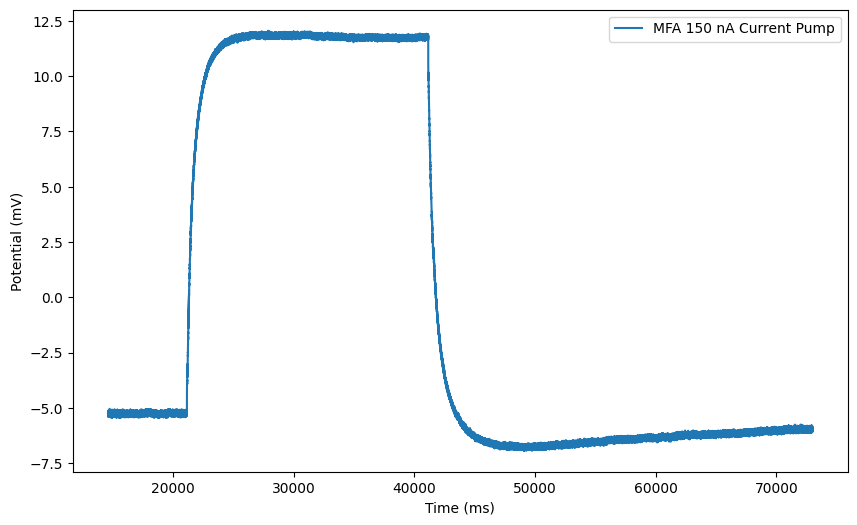

In [ ]:
import numpy as np
import csv
from matplotlib import pyplot as plt
import os

# Create a directory for plots if it doesn't exist
plots_dir = '/content/plots' if in_colab() else xp_full_name
os.makedirs(plots_dir, exist_ok=True)

#data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype='str')

# Function to load and process ATF file
def load_atf_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Find the first line of data after the "Signals" line
    data_start_index = next(i for i, line in enumerate(lines) if "Signals" in line) + 1
    tabular_data = lines[data_start_index:]

    # Process the data to extract valid numeric values
    processed_data = []
    for row in tabular_data:
        if row.strip():
            values = row.replace('"', '').split("\t")  # Remove quotes and split by tab
            try:
                processed_data.append([float(value) for value in values])
            except ValueError:
                continue

    # Convert to NumPy array for compatibility with the rest of the code
    data_array = np.array(processed_data)

    # Convert the time column (first column) from seconds to milliseconds
    data_array[:, 0] *= 1000
    # Print the number of points
    print(f"Number of points in the ATF file data: {data_array.shape[0]}")

    return data_array

# Load the ATF data
data = load_atf_file(file_path_atf)

# Calculate the index to slice the array up to, excluding the last 230 rows
index_to_cut= data.shape[0] - cut_after_index
print(f"index_to_cut:{index_to_cut}")

# Slice the array to keep only the rows before the last 230
data_cut = data[:index_to_cut]

# Define the path for the new CSV file where the "cut" data will be saved
cut_file_path = file_path+'_CUT.csv'

# Save the "cut" data to the new CSV file using NumPy
# Since np.savetxt does not automatically handle headers, we need to manage headers manually if required.
# For simplicity, this example assumes no need to handle column headers or they are included in the data.
np.savetxt(cut_file_path, data_cut, delimiter=',', fmt='%s')


# Initialize lists to store the data
times = []
current_X = []

# Open the CSV file and read the data
with open(cut_file_path, 'r') as csvfile:
    print(cut_file_path)
    datareader = csv.reader(csvfile, delimiter=',')
    header = next(datareader)  # Skip the header row
    print(f"current_column_id:{current_column_id}")
    for row in datareader:
        times.append(float(row[0]))  # Assuming the first column is Time (ms)
        current_X.append(float(row[current_column_id]))
# Convert lists to NumPy arrays
times_np = np.array(times)
current_X = np.array(current_X)
print("First 10 values of current_X:", current_X[:10])


# Calculate the index directly to remove the first 10% of the data points
stable_index_empirical = round(len(times_np) * cut_before_ratio) # re-use index computed before
print(f"stable_index_empirical:{stable_index_empirical} {len(times_np)} {times_np}{cut_before_ratio}")
# Ensure the index is within the bounds of the array
if stable_index_empirical >= len(times_np):
    raise ValueError("stable_index_empirical is beyond the array length. Check your calculation.")


# Remove the initial transient part from data
print(f"mean current_X:{np.mean(current_X)}")
current_X_stable = current_X[stable_index_empirical:]
times_np_stable = times_np[stable_index_empirical:]

if target_mean_mode == 'centered':
  current_X_stable = (current_X_stable - np.mean(current_X_stable))
elif target_mean_mode == 'centered_scaled':
  current_X_stable = (current_X_stable - np.mean(current_X_stable)) / (np.max(current_X_stable) - np.min(current_X_stable))

# 4. Plot the data (example for the '{current_na} (nA)' column)
plt.figure(figsize=(10, 6))
plt.plot(times_np_stable, current_X_stable, label=f"{experiment_type} {current_na} nA Current Pump")
plt.xlabel('Time (ms)')
plt.ylabel('Potential (mV)')
plt.legend()
#plt.show()
plt.savefig(f'{plots_dir}/experimental_data.png')


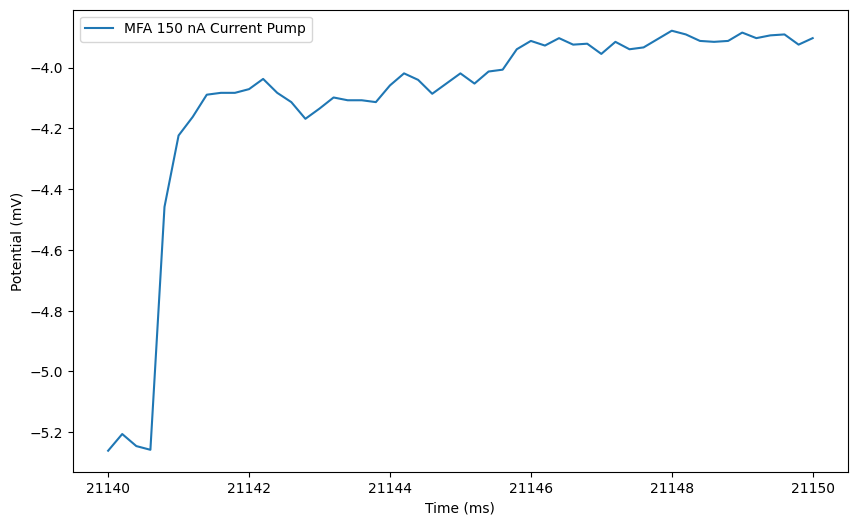

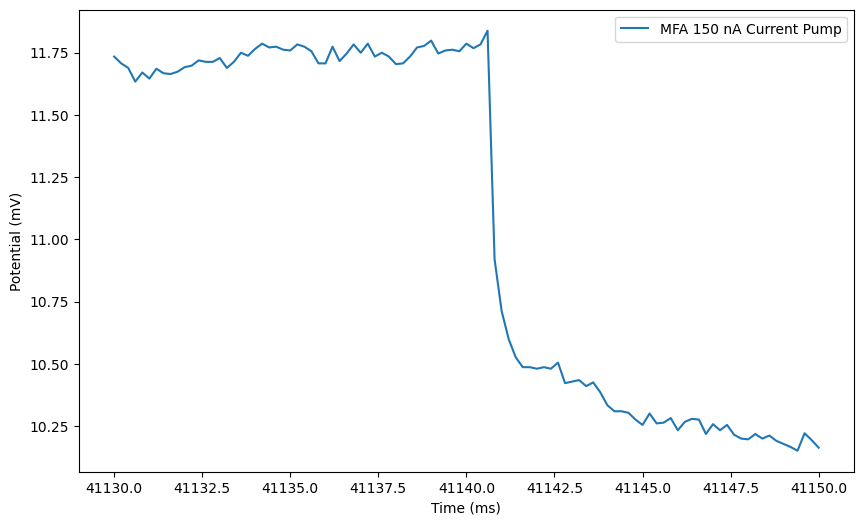

In [ ]:
# Filtering values between 20700 and 23000 ms
mask = (times_np_stable >= 21140) & (times_np_stable <= 21150)

if experiment_type == "MFA" and current_na == 100:
  outlier_mask = (times_np_stable >= 22649) & (times_np_stable <= 22650)
  # Get the index before the outlier range (the first index that is part of the range minus 1)
  outlier_start_index = np.where(outlier_mask)[0][0] - 1
  # Replace the outliers with the previous value (at `outlier_start_index`)
  current_X_stable[outlier_mask] = current_X_stable[outlier_start_index]

filtered_times = times_np_stable[mask]
filtered_current = current_X_stable[mask]

# Plotting the filtered data
plt.figure(figsize=(10, 6))
plt.plot(filtered_times, filtered_current, label=f"{experiment_type} {current_na} nA Current Pump")
plt.xlabel('Time (ms)')
plt.ylabel('Potential (mV)')
plt.legend()
plt.show()

mask = (times_np_stable >= 41130) & (times_np_stable <= 41150)
filtered_times = times_np_stable[mask]
filtered_current = current_X_stable[mask]

# Plotting the filtered data
plt.figure(figsize=(10, 6))
plt.plot(filtered_times, filtered_current, label=f"{experiment_type} {current_na} nA Current Pump")
plt.xlabel('Time (ms)')
plt.ylabel('Potential (mV)')
plt.legend()
plt.show()




In [ ]:
 # initial condition
z0 = [-89., 0., 0., 0.]
last_trace_time_value_ms = times_np_stable[-1]
Np = last_trace_time_value_ms # in milliseconds
st = 0.1 # integration steps
t = np.linspace(0,Np,int(Np/st))

# Calculate the index directly to remove the first 10% of the data points
stable_index_simulation = int(round(len(t) * cut_before_ratio))
print(f"{stable_index_simulation} = int(round({len(t)} * {cut_before_ratio}))")

# Ensure the index is within the bounds of the array
if stable_index_simulation >= len(t):
    raise ValueError("stable_index_simulation is beyond the array length. Check your calculation.")

145987 = int(round(729935 * 0.2))


In [ ]:
np.shape(current_X_stable)

(291974,)

Downsample non_ transient simulated result

In [ ]:
def downsample_array_median(sols, num_samples):
    """
    Downsamples a 1D NumPy array to a specified number of samples by taking the median over equally sized chunks.

    Parameters:
    - sols: 1D NumPy array, the original large dataset to be downsampled.
    - num_samples: int, the desired number of samples in the downsampled array.

    Returns:
    - 1D NumPy array containing the downsampled data.
    """
    # Calculate the number of points per segment for downsampling
    points_per_segment = len(sols) // num_samples

    # Initialize an empty array to hold the downsampled medians
    downsampled = np.zeros(num_samples)

    # Calculate the median for each segment and store it in the downsampled array
    for i in range(num_samples):
        start_index = i * points_per_segment
        end_index = start_index + points_per_segment
        segment = sols[start_index:end_index]
        downsampled[i] = np.median(segment)

    return downsampled

import numpy as np

def downsample_array_median_fast(sols, num_samples):
    """
    Faster downsampling of a 1D NumPy array to a specified number of samples by taking the median over equally sized chunks.
    This version uses vectorized operations for speed.

    Parameters:
    - sols: 1D NumPy array, the original large dataset to be downsampled.
    - num_samples: int, the desired number of samples in the downsampled array.

    Returns:
    - 1D NumPy array containing the downsampled data.
    """
    # Calculate the number of points per segment for downsampling
    points_per_segment = len(sols) // num_samples

    # Trim the array to ensure it's divisible by num_samples
    trimmed_length = points_per_segment * num_samples
    trimmed_sols = sols[:trimmed_length]

    # Reshape into (num_samples, points_per_segment) and compute the median along axis 1
    reshaped_sols = trimmed_sols.reshape(num_samples, points_per_segment)
    downsampled = np.median(reshaped_sols, axis=1)

    return downsampled


Various adjusted versions of target and simulated result for cost function

Plot the observables

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator

In [ ]:
if in_colab():
  print("install in colab mode")
  %pip install optuna optunahub cmaes
else:
  print("install in non colab mode")
  os.system('pip install optuna optunahub cmaes')

install in colab mode


Automatic Hyperparameter Optimization

In [ ]:
import time
import optuna
import numpy as np
from scipy.integrate import odeint
import copy
from optuna.visualization import plot_param_importances, plot_optimization_history, plot_contour
import plotly.io as pio
import warnings

# Specific setup for Google Colab to ensure plotly figures show up
pio.renderers.default = 'colab'

#current_pump_X_nA_np_norm_scale = (current_pump_X_nA_np - np.mean(current_pump_X_nA_np)) / (np.max(current_pump_X_nA_np) - np.min(current_pump_X_nA_np))
#target_normalized = current_pump_X_nA_np_norm_scale

#current_X_norm = (current_X - np.mean(current_X))
#target_normalized = current_X_norm
target = current_X_stable

# Compute loss
def compute_loss(z, target, loss_type='L1', delta_huber=1.0, gradient_loss_weight=20.):
    if loss_type == 'L2':
        return np.sum((z - target) ** 2)

    elif loss_type == 'L1':
        return np.sum(np.abs(z - target))

    elif loss_type == 'HUBER':
        abs_diff = np.abs(z - target)
        is_small_error = abs_diff <= delta_huber
        squared_loss = 0.5 * (abs_diff ** 2)
        linear_loss = delta_huber * (abs_diff - 0.5 * delta_huber)
        return np.sum(np.where(is_small_error, squared_loss, linear_loss))

    elif loss_type == 'LOG_COSH':
        return np.sum(np.log(np.cosh(z - target)))

     #import fastdtw  # Make sure you install this package: pip install fastdtw
     #elif loss_type == 'DTW':
     #   # Compute Dynamic Time Warping (DTW) distance between z and target to better match shape
     #   distance, _ = fastdtw.fastdtw(z, target, dist=euclidean)
     #   return distance

    elif loss_type == 'COMBINED':
        # Combination of L2 loss and slope/gradient matching loss
        l2_loss = np.sum((z - target) ** 2)
        z_grad = np.gradient(z)
        target_grad = np.gradient(target)
        gradient_loss = gradient_loss_weight*np.sum(np.abs(z_grad - target_grad))
        #print(f"l2_loss:{l2_loss} gradient_loss:{gradient_loss}")
        return l2_loss + gradient_loss

    else:
        raise ValueError(f"Unknown loss type {loss_type}")

def suggest_parameter(trial, param_name, suggest_func, default_min, default_max, current):
    """Helper function to suggest a parameter with optional min/max override from filter_param."""
    if not filter_param or param_name not in filter_param or filter_param[param_name] is None:
        # Use default min and max if the parameter is not in filter_param or if it has None as value
        min_value, max_value = default_min, default_max
    else:
        # Use custom min/max if provided in filter_param
        min_value, max_value = filter_param[param_name]
        min_value = min_value if min_value is not None else default_min
        max_value = max_value if max_value is not None else default_max

    if not filter_param or param_name in filter_param:
        return suggest_func(param_name, min_value, max_value)

    return current  # Use default value if not in filter_param

def suggest_categorical_parameter(trial, param_name, suggest_func, default_categories, current):
    """Helper function to suggest a categorical parameter with optional filter."""
    if not filter_param or param_name not in filter_param or filter_param[param_name] is None:
        categories = default_categories
    else:
        categories = filter_param[param_name]

    if not filter_param or param_name in filter_param:
        return suggest_func(param_name, categories)
    return current  # Use default value if not in filter_param

# Define the objective function that Optuna will optimize
def objective(trial):
    paramdict_trial = copy.deepcopy(paramdict_Default)  # Use the default parameter dictionary as a base
    global filter_param, n_filter_param_search
    if n_filter_param_search and n_filter_param_search > 0:
        filter_param = {}
        params_selection = ["eps", "eps_middle", "gki", "pk", "gs", "gt", "ca", "d", "wo", "K_bath_value_middle", "gl_a", "Va_s", "Va_l", "switching_function", "zth", "zs", "w_a"]
        for i in range(n_filter_param_search):
          filter_param[trial.suggest_categorical(f"filter_param_{i}", params_selection)] = None
    # Suggest parameters based on filter_param, allowing for optional min/max or categorical overrides
    paramdict_trial["external"]["epsilon"] = suggest_parameter(trial, "eps", trial.suggest_float, 1e-4, 1e-1, paramdict_trial["external"]["epsilon"])
    paramdict_trial["external"]["epsilon_middle"] = suggest_parameter(trial, "eps_middle", trial.suggest_float, 1./4., 4., paramdict_trial["external"]["epsilon_middle"])
    paramdict_trial["Astrocyte"]["g_kir"] = suggest_parameter(trial, "gki", trial.suggest_float, 1., 200., paramdict_trial["Astrocyte"]["g_kir"])
    paramdict_trial["Astrocyte"]["P_k"] = suggest_parameter(trial, "pk", trial.suggest_float, 3*1e-7, 3*1e-2, paramdict_trial["Astrocyte"]["P_k"])
    paramdict_trial["Astrocyte"]["gama_s"] = suggest_parameter(trial, "gs", trial.suggest_float, 0.1, 50., paramdict_trial["Astrocyte"]["gama_s"])
    paramdict_trial["Astrocyte"]["gama_t"] = suggest_parameter(trial, "gt", trial.suggest_float, 0.1, 50., paramdict_trial["Astrocyte"]["gama_t"])
    paramdict_trial["Astrocyte"]["Cm_a"] = suggest_parameter(trial, "ca", trial.suggest_int, 300, 400, paramdict_trial["Astrocyte"]["Cm_a"])
    paramdict_trial["Astrocyte"]["d_gap"] = suggest_parameter(trial, "d", trial.suggest_float, 0.0, 0.6, paramdict_trial["Astrocyte"]["d_gap"])
    paramdict_trial["Astrocyte"]["w_a"] = suggest_parameter(trial, "w_a", trial.suggest_float, 500., 4000., paramdict_trial["Astrocyte"]["w_a"])
    paramdict_trial["external"]["w_o"] = suggest_parameter(trial, "wo", trial.suggest_float, 300., 4000., paramdict_trial["external"]["w_o"])
    paramdict_trial["external"]["w_o_middle"] = suggest_parameter(trial, "w_o_middle", trial.suggest_float, 1./3., 3., paramdict_trial["external"]["w_o_middle"])
    K_bath_middle_value = suggest_parameter(trial, "K_bath_value_middle", trial.suggest_float, current_dict_k_bath_values[str(current_na)][1]-2., current_dict_k_bath_values[str(current_na)][1]+2., paramdict_trial["external"]["K_bath"]["value"][1])
    paramdict_trial["external"]["K_bath"]["value"] = [4.8, K_bath_middle_value, 4.8]
    paramdict_trial["Astrocyte"]["gl_a"] = suggest_parameter(trial, "gl_a", trial.suggest_float, 0.0, 30., paramdict_trial["Astrocyte"]["gl_a"]) #0.01
    paramdict_trial["Astrocyte"]["Va_s"] = suggest_parameter(trial, "Va_s", trial.suggest_int, -99, -90, paramdict_trial["Astrocyte"]["Va_s"])
    paramdict_trial["Astrocyte"]["Va_l"] = suggest_parameter(trial, "Va_l", trial.suggest_float, -70., -40., paramdict_trial["Astrocyte"]["Va_l"])

    # Suggest the categorical switching function, using filter_param if provided
    paramdict_trial["Astrocyte"]["switching_function"] = suggest_categorical_parameter(trial, "switching_function", trial.suggest_categorical, ["sigmoid", "tanh"], paramdict_trial["Astrocyte"]["switching_function"])
    switching_function = paramdict_trial["Astrocyte"]["switching_function"]

    if switching_function == "sigmoid":
        paramdict_trial["Astrocyte"]["Z_th"] = suggest_parameter(trial, "zth", trial.suggest_float, 20., 120., paramdict_trial["Astrocyte"]["Z_th"])
        paramdict_trial["Astrocyte"]["Z_s"] = suggest_parameter(trial, "zs", trial.suggest_float, 0.005, 10., paramdict_trial["Astrocyte"]["Z_s"])
    elif switching_function == "tanh":
        paramdict_trial["Astrocyte"]["Z_th"] = suggest_parameter(trial, "zth", trial.suggest_float, 20., 120., paramdict_trial["Astrocyte"]["Z_th"])
        paramdict_trial["Astrocyte"]["Z_s"] = suggest_parameter(trial, "zs", trial.suggest_float, 0.005, 10., paramdict_trial["Astrocyte"]["Z_s"])
    elif switching_function == "hill":
        paramdict_trial["Astrocyte"]["hill_coefficient"] = suggest_parameter(trial, "hill_coefficient", trial.suggest_float, 1, 4, paramdict_trial["Astrocyte"]["hill_coefficient"])
        paramdict_trial["Astrocyte"]["K_d"] = suggest_parameter(trial, "K_d", trial.suggest_float, 0.1, 10, paramdict_trial["Astrocyte"]["K_d"])
    else:
        raise ValueError(f"Unknown switching function type: {switching_function}")

    with warnings.catch_warnings():
      warnings.simplefilter("error", RuntimeWarning)  # Turn RuntimeWarnings into

      # Run the simulation
      try:
        # Run the original model
        start_time_model = time.time()
        z = odeint(model, z0, t, args=(paramdict_trial,))
        if not np.isfinite(z).all():
            raise ValueError("Non-finite values detected in the ODE solution")
        model_time = time.time() - start_time_model

        # Calculate the index directly to remove the first 10% of the data points
        #stable_index = int(round(len(t) * cut_before_ratio))
        # Ensure the index is within the bounds of the array
        #if stable_index >= len(t):
            #raise ValueError("stable_index is beyond the array length. Check your calculation.")

        # prep the simulated data
        z_stable = z[stable_index_simulation:]
        z_400 = downsample_array_median_fast(z_stable[:,0], len(current_X_stable))
        #print(f"{len(z_400)}, {len(z_stable[:,0])}, {len(current_X_stable)}")
        #z_400_0 = (z_400  - np.mean(z_400[:107]))

        if target_mean_mode == 'centered':
          z_400_0 = (z_400  - np.mean(z_400))
        elif target_mean_mode == 'centered_scaled':
          z_400_0 = (z_400  - np.mean(z_400)) / (np.max(z_400) - np.min(z_400))
        else:
          z_400_0 = z_400

        # Compute the objective value / total loss error
        objective_value = compute_loss(z_400_0, target, loss_type=objective_loss_type)

        # Output the results for comparison
        if trial.number % 10 == 0:
          print(f"Np:{Np:.1f}, st:{st}, Model time: {model_time:.1f}s, Trial time: {(time.time() - start_time_model):.1f}s, paramdict_trial:{paramdict_trial} ")

        return objective_value

      except RuntimeWarning as e:
        print(f"A numerical issue occurred during ODE solving: {e} with values {paramdict_trial}")
        # Handle the warning/error, e.g., by logging, using fallback values, or retrying with adjusted parameters
        return 10000000
      # Catch SystemError in case of ODE solver failure
      except (RuntimeWarning, ValueError, SystemError, TypeError) as e:
        print(f"Error during integration: {e} with values {paramdict_trial}")
        return 10000000
        # Handle the overflow case, e.g., by using different parameters or initial conditions



In [ ]:
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner, HyperbandPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

storage_name = f"sqlite:///{xp_full_name}.db"

#sampler = TPESampler(multivariate=True, warn_independent_sampling=False)
import optunahub
mod = optunahub.load_module(package="samplers/catcma")
sampler = mod.CatCmaSampler()
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)
#pruner = optuna.pruners.HyperbandPruner()
study = optuna.create_study(sampler=sampler, pruner=pruner, direction="minimize", storage=storage_name, load_if_exists=True, study_name=xp_full_name)

study.enqueue_trial(default_starting_params)
if default_starting_params_2:
  print("ADDED EXTRA default_starting_params_2")
  study.enqueue_trial(default_starting_params_2)

from datetime import datetime
def logging_callback(study, trial):
    if trial.number < 5 or trial.number % 10 == 0: # Print trial results every 10 trials
        print(f"[{datetime.now().strftime('%d:%H:%M:%S')}] Trial:{trial.number} Value:{trial.value:.1f} Best value:{study.best_value:.1f} Best params:{study.best_params}")

study.optimize(objective, n_trials=total_trials, callbacks=[logging_callback]) #, n_jobs=-1)

# After optimization, you can print or use the best parameters found
print("Best parameters:", study.best_params, "\nBest value:", study.best_value)

ADDED EXTRA default_starting_params_2


/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:652: UserWarning:

Fixed parameter 'eps' with value 0.003093489961714539 is out of range for distribution FloatDistribution(high=0.001, log=False, low=0.0001, step=None).



Np:72993.6, st:0.1, Model time: 0.3s, Trial time: 0.3s, paramdict_trial:{'Astrocyte': {'Cm_a': 345.0, 'g_kir': 75.214546010314, 'g_k_a': 0.0, 'w_a': 2020.4642530827643, 'P_k': 0.00014815993980162685, 'A': 1.0, 'gl_a': 2.968845486327571, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'd_gap': 0.24743166678640502, 'Va_0': -89.0, 'Sig_a': 1600.0, 'K_a0': 135.0, 'F': 96485.0, 'R': 8.314, 'T': 298.0, 'gama_t': 1.2855682352587539, 'gama_s': 31.59697757589332, 'Z_s': 0.034648791845737, 'Z_th': 4.48301583768424, 'switching_function': 'sigmoid'}, 'external': {'K_o0': 4.8, 'w_o': 2986.6247190162417, 'w_o_middle': 1.0, 'epsilon': 0.003093489961714539, 'epsilon_middle': 0.5931896936467029, 'K_bath': {'time': array([    0., 21140., 41140.]), 'value': [4.8, 12.086559777656124, 4.8]}}} 
[02:23:43:43] Trial:0 Value:228689.6 Best value:228689.6 Best params:{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}


/usr/local/lib/python3.10/dist-packages/optuna/trial/_trial.py:652: UserWarning:

Fixed parameter 'eps' with value 0.00145587137746065 is out of range for distribution FloatDistribution(high=0.001, log=False, low=0.0001, step=None).



[02:23:43:43] Trial:1 Value:747519.5 Best value:228689.6 Best params:{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}
[02:23:43:44] Trial:2 Value:2642320.6 Best value:228689.6 Best params:{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}
[02:23:43:45] Trial:3 Value:4842184.5 Best value:228689.6 Best params:{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}
[02:23:43:45] Trial:4 Value:2842789.0 Best value:228689.6 Best params:{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}
Np:72993.6, st:0.1, Model time: 0.3s, Trial time: 0.3s, paramdict_trial:{'Astrocyte': {'Cm_a': 345.0, 'g_kir': 75.214546010314, 'g_k_a': 0.0, 'w_a': 2020.4642530827643, 'P_k': 0.00014815993980162685, 'A': 1.0, 'gl_a': 2.968845486327571, 'Va_l': -61.53359829485799, 'Va_s': -93.0, 'd_gap': 0.24743166678640502, 'Va_0': -89.0, 'Sig_a': 1600.0, 'K_a0': 135.0, 

In [ ]:
# Get all completed trials in the study and sort them by their value (objective function)
completed_trials = [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
sorted_trials = sorted(completed_trials, key=lambda trial: trial.value, reverse=False)  # Use reverse=True for maximization

max_top = 10
# Get the top trials
top_n_trials = sorted_trials[:max_top]

# Assuming 'top_n_trials' is a list of Optuna trial objects
if top_n_trials:
    # Dynamically construct the header based on the parameter keys
    param_keys = list(top_n_trials[0].params.keys())
    header_format = "{:<5} {:<10} " + " ".join(["{:<15}" for _ in param_keys])
    row_format = "{:<5} {:<10} " + " ".join(["{:<15.5}" for _ in param_keys])

    # Print the header
    print(header_format.format("Rank", "Value", *param_keys))

    # Print each row
    for i, trial in enumerate(top_n_trials, start=1):
        row_values = [i, round(trial.value, 3)] + [trial.params[key] if key in trial.params else default_starting_params[key] for key in param_keys]
        formatted_values = []
        for value in row_values:
            if isinstance(value, float):
                formatted_values.append(f"{value:<15.5f}")  # Float format
            else:
                formatted_values.append(f"{value:<15}")  # Int format or default format
        print(" ".join(formatted_values))

Rank  Value      eps             Va_l            switching_function
1               228689.61800    0.00309         -40.23185       sigmoid        
2               747519.54400    0.00146         -60.77812       tanh           
3               1767075.88400   0.00100         -69.99967       tanh           
4               1767081.65400   0.00100         -69.99489       tanh           
5               1767084.51900   0.00100         -69.99745       tanh           
6               1767084.77400   0.00100         -69.99924       tanh           
7               1767089.61600   0.00100         -69.99798       tanh           
8               1767093.26500   0.00100         -69.99700       tanh           
9               1767094.48500   0.00100         -69.99670       tanh           
10              1767095.08400   0.00100         -69.99389       tanh           


In [ ]:
import pandas as pd
from optuna.importance import FanovaImportanceEvaluator
from optuna.importance import get_param_importances
import os

def truncate_string(s: str, max_length: int = 40, start_len: int = 20, end_len: int = 20) -> str:
    if len(s) > max_length:
        s = s.replace('\n', ' ')
        return f"{s[:start_len]}...{s[-end_len:]}"
    return s

db_analysis_output_file = f"{xp_full_name}/optuna.db.analysis.txt"
os.makedirs(xp_full_name, exist_ok=True)

# Function to write results to the file
def write_to_file(text, mode="a"):
    with open(db_analysis_output_file, mode) as f:
        f.write(text + "\n")
    print(text)

# Get all trials as a DataFrame
df = study.trials_dataframe()

if len(df) > 0:
    # Sort by `value` to display top 10 trials (or fewer if less than 10)
    sorted_df = df.sort_values(by='value', ascending=True).head(min(10, len(df)))

    write_to_file(f"\nTop 10 Trials by Performance (out of {total_trials} trials):\n")
    write_to_file(f"{'Value':<10} | {'State':<10} | {'Params':<40} | {'Datetime':<20} | {'Trial ID'}")
    write_to_file("-" * 120)

    for idx, row in sorted_df.iterrows():
        # Handle Pandas Timestamp objects directly
        datetime_short = row['datetime_start'].strftime('%Y-%m-%d %H:%M:%S') if row['datetime_start'] else "N/A"

        # Extract parameters actually used in this trial
        params = {col.replace('params_', ''): truncate_string(str(row[col])) for col in df.columns if col.startswith('params_') and pd.notna(row[col])}

        # Convert the params dict to a string
        params_str = str(params)

        # Handle None values in 'value' and 'state'
        trial_value = row['value'] if row['value'] is not None else "N/A"
        trial_state = row['state'] if row['state'] is not None else "UNKNOWN"

        # Write the row with params string
        write_to_file(f"{trial_value:<10.0f} | {trial_state:<10} | {params_str:<40} | {datetime_short:<20} | {row['number']}")

    # Sort by `value` to display least 10 trials (or fewer if less than 10)
    sorted_df = df.sort_values(by='value', ascending=False).head(min(10, len(df)))

    write_to_file(f"\nLeast 10 Trials by Performance (out of {total_trials} trials):\n")
    write_to_file(f"{'Value':<10} | {'State':<10} | {'Params':<40} | {'Datetime':<20} | {'Trial ID'}")
    write_to_file("-" * 120)

    for idx, row in sorted_df.iterrows():
        # Handle Pandas Timestamp objects directly
        datetime_short = row['datetime_start'].strftime('%Y-%m-%d %H:%M:%S') if row['datetime_start'] else "N/A"

        # Extract parameters actually used in this trial
        params = {col.replace('params_', ''): truncate_string(str(row[col])) for col in df.columns if col.startswith('params_') and pd.notna(row[col])}

        # Convert the params dict to a string
        params_str = str(params)

        # Handle None values in 'value' and 'state'
        trial_value = row['value'] if row['value'] is not None else "N/A"
        trial_state = row['state'] if row['state'] is not None else "UNKNOWN"

        # Write the row with params string
        write_to_file(f"{trial_value:<10.0f} | {trial_state:<10} | {params_str:<40} | {datetime_short:<20} | {row['number']}")

    # Check if there is a valid `best_trial` available
    try:
        best_trial = study.best_trial

        # Improved parameter performance analysis for all params
        write_to_file("\nParameter Performance:\n")
        write_to_file(f"{'Parameter':<25} | {'Type':<12} | {'Value/Range':<40} | {'Mean Performance':<15} | {'Count':<5}")
        write_to_file("-" * 100)

        # Ensure analysis includes all parameters, even if not tested in some trials
        all_params = [col.replace('params_', '') for col in df.columns if col.startswith('params_')]

        for param in all_params:
            if f'params_{param}' in df.columns:
                values = df[f'params_{param}']

                if values.dtype == 'object':
                    # Categorical parameter performance
                    df[f'params_{param}'] = df[f'params_{param}'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
                    performance_by_category = df.groupby(f'params_{param}')['value'].agg(['mean', 'count']).sort_values(by='mean', ascending=True)
                    for cat_value, row in performance_by_category.iterrows():
                        mean_perf = row['mean']
                        count = row['count']
                        cat_value_str = truncate_string(str(cat_value))
                        write_to_file(f"{param:<25} | {'Categorical':<12} | {cat_value_str:<40} | {mean_perf:<15.0f} | {count:<5}")

                elif values.dtype == 'bool':
                    # Boolean parameter performance
                    performance_by_bool = df.groupby(f'params_{param}')['value'].agg(['mean', 'count'])
                    for bool_value, row in performance_by_bool.iterrows():
                        mean_perf = row['mean']
                        count = row['count']
                        write_to_file(f"{param:<25} | {'Boolean':<12} | {str(bool_value):<40} | {mean_perf:<15.0f} | {count:<5}")

                elif values.dtype in ['int64', 'float64']:
                    if pd.api.types.is_integer_dtype(values):
                        # Integer parameter performance
                        performance_by_value = df.groupby(f'params_{param}')['value'].agg(['mean', 'count']).sort_index()
                        bin_type = 'Integer'
                        for value, row in performance_by_value.iterrows():
                            mean_perf = row['mean']
                            count = row['count']
                            write_to_file(f"{param:<25} | {bin_type:<12} | {str(value):<40} | {mean_perf:<15.0f} | {count:<5}")
                    else:
                        # For floating-point numbers, use binning
                        min_value = values.min()
                        max_value = values.max()
                        bin_size = 5
                        bins = pd.cut(values, bins=bin_size, precision=1)
                        performance_by_bin = df.groupby(bins, observed=False)['value'].agg(['mean', 'count'])
                        bin_type = 'Numerical'
                        for bin_range, row in performance_by_bin.iterrows():
                            mean_perf = row['mean']
                            count = row['count']
                            write_to_file(f"{param:<25} | {bin_type:<12} | {str(bin_range):<40} | {mean_perf:<15.0f} | {count:<5}")

                # Add a separator line between parameters
                write_to_file("-" * 100)

    except ValueError:
        write_to_file("\nNo best trial found for parameter performance analysis.")



Top 10 Trials by Performance (out of 500 trials):

Value      | State      | Params                                   | Datetime             | Trial ID
------------------------------------------------------------------------------------------------------------------------
228690     | COMPLETE   | {'Va_l': '-40.23185068059135', 'eps': '0.003093489961714539', 'switching_function': 'sigmoid'} | 2024-11-02 23:43:42  | 0
747520     | COMPLETE   | {'Va_l': '-60.7781175678844', 'eps': '0.00145587137746065', 'switching_function': 'tanh'} | 2024-11-02 23:43:43  | 1
1767076    | COMPLETE   | {'Va_l': '-69.9996736974863', 'eps': '0.0009999962085339954', 'switching_function': 'tanh'} | 2024-11-02 23:46:06  | 492
1767082    | COMPLETE   | {'Va_l': '-69.99488829456826', 'eps': '0.0009999980905124036', 'switching_function': 'tanh'} | 2024-11-02 23:46:02  | 476
1767085    | COMPLETE   | {'Va_l': '-69.99745258058644', 'eps': '0.0009999954205467075', 'switching_function': 'tanh'} | 2024-11-02 23:46:08

In [ ]:
def round_to_significant_log(x, sig_digits=6):
    import math
    if x == 0:
        return 0.0
    else:
        # Calculate the order of magnitude of the absolute value of x
        order_of_magnitude = math.floor(math.log10(abs(x)))
        # Determine the number of decimal places needed
        decimal_places = max(0, (sig_digits - 1) - order_of_magnitude)
        # Format the number with the appropriate number of decimal places
        return round(x, decimal_places)


In [ ]:
print(f"best value:{int(study.best_trial.value)} with params={study.best_trial.params}")

best value:228689 with params={'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}


In [ ]:
import numpy as np
from scipy.integrate import odeint
import copy
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import os
import shutil
import re

# Assuming 'study', 'z0', 't', 'paramdict_Default', 'current_X_stable', 'stable_index_simulation',
# 'times_np_stable', 'xp_full_name', 'experiment_type', 'current_na', 'total_trials', and other variables are defined

parameter_mappings_external = {
    'eps_middle': 'epsilon_middle',
    'K_bath_value_middle': 'kbath_middle',
    'eps': 'epsilon',
    'wo': 'w_o'
}

parameter_mappings_astrocyte = {
    'gki': 'g_kir',
    'pk': 'P_k',
    'gs': 'gama_s',
    'gt': 'gama_t',
    'ca': 'Cm_a',
    'd': 'd_gap',
    'w_a': 'w_a',
    'gl_a': 'gl_a',
    'Va_s': 'Va_s',
    'Va_l': 'Va_l',
    'zth': 'Z_th',
    'zs': 'Z_s',
}

# Retrieve the best parameters from the Optuna study
parameters = study.best_trial.params

# Copy the default parameter dictionary
paramdict = copy.deepcopy(paramdict_Default)

# Function to update paramdict with parameters from the best trial
def update_paramdict(paramdict, parameters):
    for param in parameter_mappings_astrocyte:
        if param in parameters:
            paramdict["Astrocyte"][parameter_mappings_astrocyte[param]] = parameters[param]
            print(f"param:{param} {parameters[param]} {paramdict['Astrocyte'][parameter_mappings_astrocyte[param]]}")

    # Update external parameters
    external_params = ["w_o","w_o_middle", "epsilon", "epsilon_middle"]
    for param in parameter_mappings_external:
        if param in parameters:
            paramdict["external"][parameter_mappings_external[param]] = parameters[param]
            print(f"param:{param} {parameters[param]} {paramdict['external'][parameter_mappings_external[param]]}")

    # Handle K_bath_value_middle if present
    if "K_bath_value_middle" in parameters:
        paramdict["external"]["K_bath"]['value'] = [4.8, parameters["K_bath_value_middle"], 4.8]

    # Handle the switching function
    switching_function = parameters.get("switching_function", paramdict["Astrocyte"].get("switching_function", "sigmoid"))
    print(f"switching_function:<{switching_function}>")
    paramdict["Astrocyte"]["switching_function"] = switching_function

    if switching_function in ["sigmoid", "tanh"]:
        # Update parameters specific to sigmoid and tanh functions
        if "Z_th" in parameters:
            paramdict["Astrocyte"]["Z_th"] = parameters["Z_th"]
        elif "zth" in parameters:
            paramdict["Astrocyte"]["Z_th"] = parameters["zth"]
        if "Z_s" in parameters:
            paramdict["Astrocyte"]["Z_s"] = parameters["Z_s"]
        elif "zs" in parameters:
            paramdict["Astrocyte"]["Z_s"] = parameters["zs"]
    elif switching_function == "hill":
        paramdict["Astrocyte"]["Z_th"], paramdict["Astrocyte"]["Z_s"] = None, None
        # Update parameters specific to hill function
        if "hill_coefficient" in parameters:
            paramdict["Astrocyte"]["hill_coefficient"] = parameters["hill_coefficient"]
        if "K_d" in parameters:
            paramdict["Astrocyte"]["K_d"] = parameters["K_d"]
    else:
        raise ValueError(f"Unknown switching function type: {switching_function}")

    return paramdict

print(f"paramdict BEFORE:{paramdict}")
# Update paramdict with the best parameters
paramdict = update_paramdict(paramdict, parameters)
print(f"paramdict AFTER:{paramdict}")

# Run the model using the updated paramdict
z = odeint(model, z0, t, args=(paramdict,))

# Remove the transient part from `z`
z_stable = z[stable_index_simulation:]

# Downsample the data if necessary
z_400 = downsample_array_median_fast(z_stable[:, 0], len(current_X_stable))

# Normalize or center the data based on target_mean_mode
if target_mean_mode == 'centered':
    z_400_0 = z_400 - np.mean(z_400)
elif target_mean_mode == 'centered_scaled':
    z_400_0 = (z_400 - np.mean(z_400)) / (np.max(z_400) - np.min(z_400))
else:
    z_400_0 = z_400

# Extract necessary parameters from paramdict for further calculations
astro_params = paramdict["Astrocyte"]
external_params = paramdict["external"]

Cm_a = astro_params["Cm_a"]
g_kir = astro_params["g_kir"]
A = astro_params["A"]
g_k_a = astro_params["g_k_a"]
gl_a = astro_params["gl_a"]
w_a = astro_params["w_a"]
K_a0 = astro_params["K_a0"]
Sig_a = astro_params["Sig_a"]
gama_t = astro_params["gama_t"]
gama_s = astro_params["gama_s"]
Va_s = astro_params["Va_s"]
Va_l = astro_params["Va_l"]
P_k = astro_params["P_k"]
d_gap = astro_params["d_gap"]
F = astro_params["F"]
R = astro_params["R"]
T = astro_params["T"]

K_o0 = external_params["K_o0"]
w_o = external_params["w_o"]
epsilon = external_params["epsilon"]

# Handle switching function parameters
switching_function = astro_params["switching_function"]
if switching_function in ["sigmoid", "tanh"]:
    Z_th = astro_params["Z_th"]
    Z_s = astro_params["Z_s"]
elif switching_function == "hill":
    hill_coefficient = astro_params["hill_coefficient"]
    K_d = astro_params["K_d"]

#Z_s = 4.
external_params["K_bath"]['value'] = [4.8, 15, 4.8]

# Ensure `sols_stable` is a 2D array for single simulation
sols_arr = np.array(z_stable)

# Extract state variables from the solution array
Va = sols_arr[:, 0]         # Astrocyte membrane potential
DK_a_t = sols_arr[:, 1]     # Change in intracellular K+ due to transmembrane currents
K_a_s = sols_arr[:, 2]      # Change in intracellular K+ due to syncytium currents
Kg = sols_arr[:, 3]         # K+ concentration in the gap

# Compute total intracellular K+ concentration
DK_a = DK_a_t + K_a_s
K_a = K_a0 + DK_a           # Total intracellular K+ concentration

# Compute extracellular K+ concentration
DK_o_a = -(w_a / w_o) * DK_a_t
K_o = K_o0 + DK_o_a + Kg    # Total extracellular K+ concentration

# Compute Nernst potential for K+
E_k_a = 25.7 * np.log(np.abs(K_o / K_a))

# Compute membrane currents
I_k_a = g_k_a * (Va - E_k_a)
I_Kir = A * g_kir * np.sqrt(np.abs(K_o)) * (Va - E_k_a) * (1 / (1 + np.exp((Va - E_k_a) / 19.2)))
PH_a = 0.04 * (Va - Va_s)
P_kgap = d_gap * P_k
I_kgap = P_kgap * F * PH_a * (1 / (-1 + np.exp(-PH_a))) * ((K_a * np.exp(-PH_a)) - K_a0)
I_l_a = gl_a * (Va - Va_l)
DVa = Va - E_k_a
DVa_s = Va - Va_s
F_gap = 1 + (DK_a / K_a0) / (1 - np.exp(0.04 * (Va - Va_s)))

# Calculate the switching function Th_s based on the switching function type
if switching_function == "sigmoid":
    Th_s = DK_a / (1 + np.exp((Z_th - DK_a_t) * Z_s))
elif switching_function == "tanh":
    Th_s = DK_a * (0.5 * (1 + np.tanh((DK_a_t - Z_th) * Z_s)))
elif switching_function == "hill":
    Th_s = DK_a * ((DK_a_t ** hill_coefficient) / (K_d ** hill_coefficient + DK_a_t ** hill_coefficient))
else:
    raise ValueError(f"Unknown switching function type: {switching_function}")

# Prepare data for plotting and analysis
Concentration = np.column_stack([K_o, DK_a_t, K_a_s, Kg, DK_a, K_a])
Current = np.column_stack([I_k_a, I_Kir, I_kgap, I_l_a, Th_s])
potential = np.column_stack([Va, E_k_a, PH_a, DVa, DVa_s])

NbPoints = sols_arr.shape[0]

# Normalize data if necessary
potential_norm = potential[:, 0] - np.mean(potential[:, 0])
potential_norm_scale = (potential[:, 0] - np.mean(potential[:, 0])) / (np.max(potential[:, 0]) - np.min(potential[:, 0]))
z_400_norm = z_400 - np.mean(z_400)
z_400_norm_scale = (z_400 - np.mean(z_400)) / (np.max(z_400) - np.min(z_400))
current_X_stable_norm = current_X_stable - np.mean(current_X_stable)
current_X_stable_norm_scale = (current_X_stable - np.mean(current_X_stable)) / (np.max(current_X_stable) - np.min(current_X_stable))

## DISPLAY CHECKS

# Calculate the sum of absolute differences between z_400_0 and current_X_stable
sum_diff_z400_0 = np.sum(np.abs(z_400_0 - current_X_stable))
print(f"Sum of absolute differences between z_400_0 and current_X_stable: {sum_diff_z400_0}")
# Calculate the sum of absolute differences between z_400_norm and current_X_stable_norm
sum_diff_z400_norm = np.sum(np.abs(z_400_norm - current_X_stable_norm))
print(f"Sum of absolute differences between z_400_norm and current_X_stable_norm: {sum_diff_z400_norm}")
# Calculate the sum of absolute differences between z_400_norm_scale and current_X_stable_norm_scale
sum_diff_z400_norm_scale = np.sum(np.abs(z_400_norm_scale - current_X_stable_norm_scale))
print(f"Sum of absolute differences between z_400_norm_scale and current_X_stable_norm_scale: {sum_diff_z400_norm_scale}")
# Calculate the mean of z_400
mean_z400 = np.mean(z_400)
print(f"Mean of z_400: {mean_z400}")
# Calculate the mean of current_X_stable
mean_current_X_stable = np.mean(current_X_stable)
print(f"Mean of current_X_stable: {mean_current_X_stable}")
norm_objective_value = compute_loss(z_400_norm, current_X_stable, loss_type=objective_loss_type)
print(f"norm_objective_value: {norm_objective_value}")
objective_value = compute_loss(z_400_0, current_X_stable, loss_type=objective_loss_type)
print(f"objective_value: {objective_value}")

#best value:152108 with params:{'eps': 0.0018862433555606847, 'eps_middle': 0.516497061322195, 'gki': 161.77156481339694, 'pk': 0.0018910538894720285, 'gt': 0.11626968507586222, 'd': 0.01995114623810315, 'wo': 2972.559062700267, 'gl_a': 6.159393712718347, 'Va_s': -98}


paramdict BEFORE:{'Astrocyte': {'Cm_a': 345.0, 'g_kir': 75.214546010314, 'g_k_a': 0.0, 'w_a': 2020.4642530827643, 'P_k': 0.00014815993980162685, 'A': 1.0, 'gl_a': 2.968845486327571, 'Va_l': -40.23185068059135, 'Va_s': -93.0, 'd_gap': 0.24743166678640502, 'Va_0': -89.0, 'Sig_a': 1600.0, 'K_a0': 135.0, 'F': 96485.0, 'R': 8.314, 'T': 298.0, 'gama_t': 1.2855682352587539, 'gama_s': 31.59697757589332, 'Z_s': 0.034648791845737, 'Z_th': 4.48301583768424, 'switching_function': 'sigmoid'}, 'external': {'K_o0': 4.8, 'w_o': 2986.6247190162417, 'w_o_middle': 1.0, 'epsilon': 0.003093489961714539, 'epsilon_middle': 0.5931896936467029, 'K_bath': {'time': array([    0., 21140., 41140.]), 'value': [4.8, 12.086559777656124, 4.8]}}}
param:Va_l -40.23185068059135 -40.23185068059135
param:eps 0.003093489961714539 0.003093489961714539
switching_function:<sigmoid>
paramdict AFTER:{'Astrocyte': {'Cm_a': 345.0, 'g_kir': 75.214546010314, 'g_k_a': 0.0, 'w_a': 2020.4642530827643, 'P_k': 0.00014815993980162685, 'A'

# PLOTTING

MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d


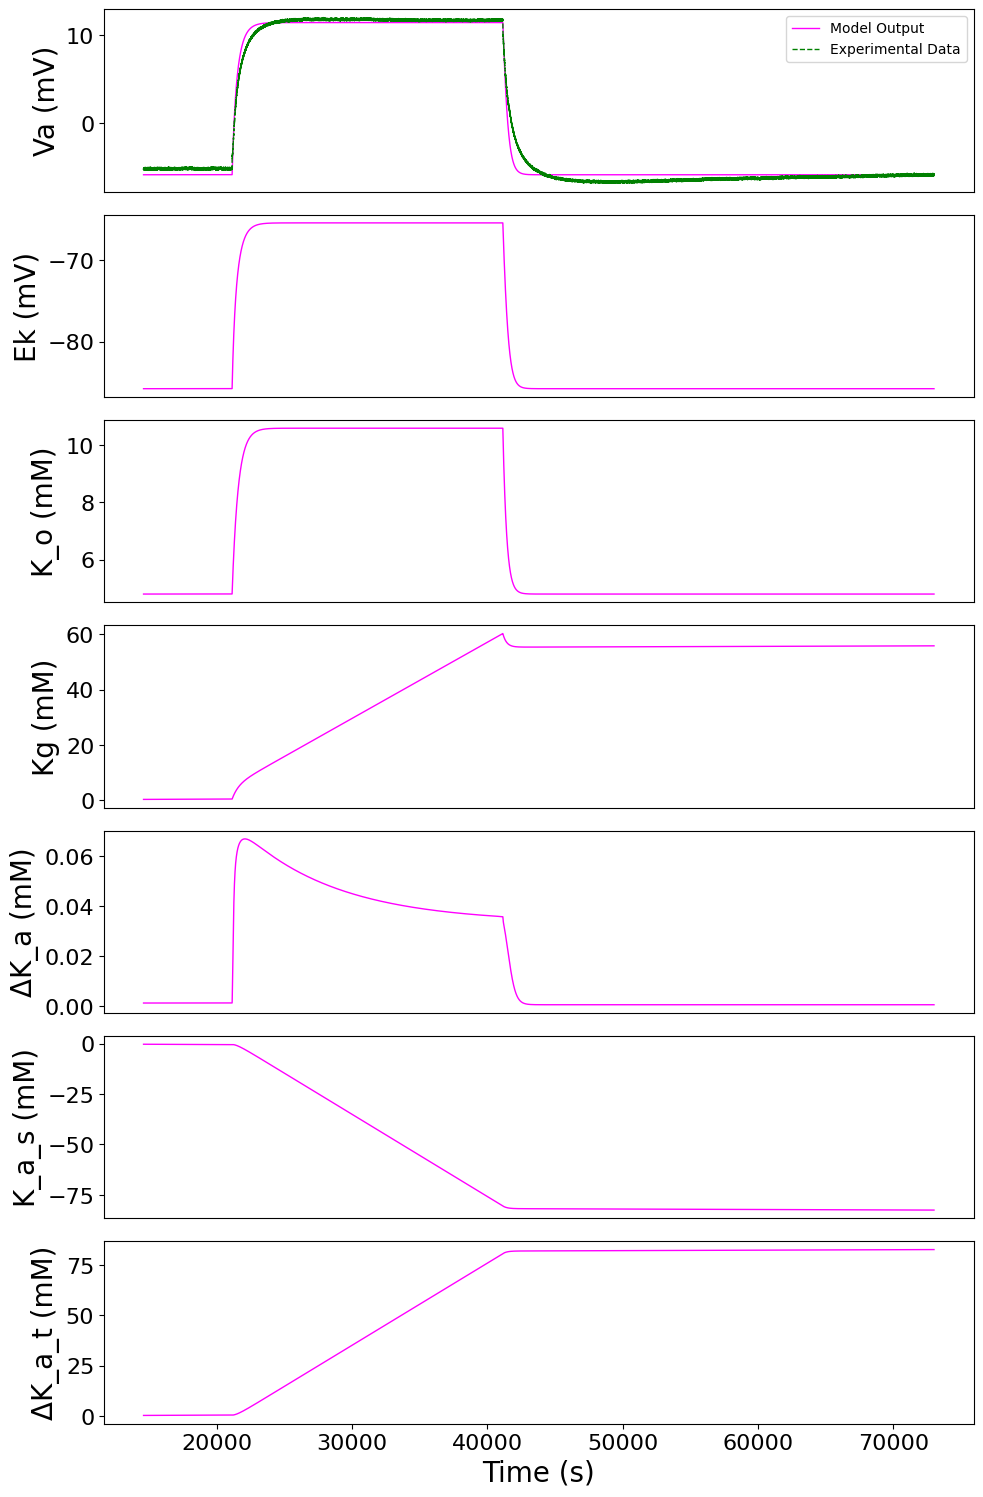

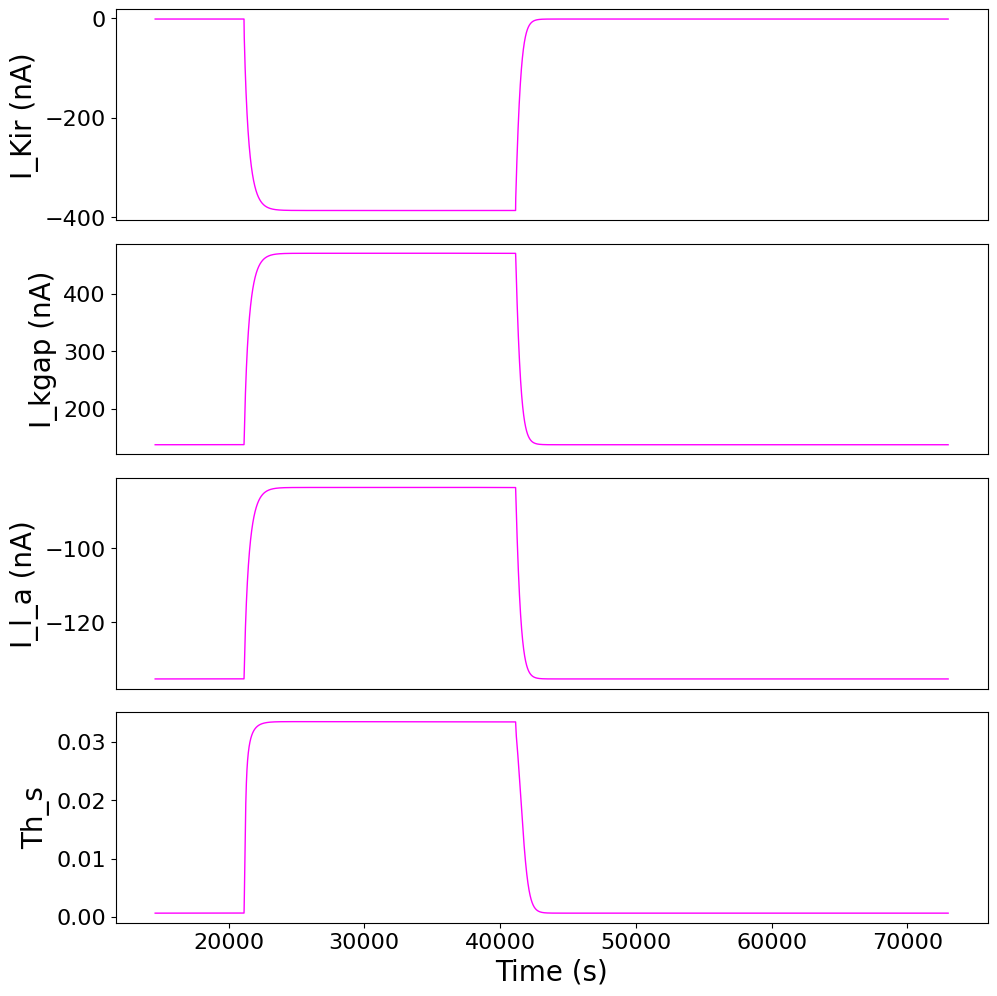

In [ ]:
# Generate a safe name from paramdict for plotting
def generate_safe_name_from_dict(data):
    def process_item(k, v):
        safe_key = re.sub(r'[^\w]', '', str(k))
        if isinstance(v, dict):
            safe_value = generate_safe_name_from_dict(v)
        elif isinstance(v, float):
            safe_value = f"{v:.2f}"  # Convert float to string with 2 decimal places
        else:
            safe_value = re.sub(r'[^\w]', '', str(v))
        return f"_{safe_key}{safe_value}"
    return ''.join(process_item(k, v) for k, v in data.items())

plot_base_name = f"{xp_full_name}_{generate_safe_name_from_dict(paramdict)[:100]}"
print(plot_base_name)

# Prepare time vectors
a_stable = t[stable_index_simulation:]
a_current_X = times_np_stable  # Assuming times_np_stable corresponds to current_X_stable

# Plotting code for the first figure
# Increase font size of ticks
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

# Define line width and color
line_width = 1.0
line_color = '#FF00FF'  # choose a sharp color

plt.figure(figsize=(10, 15))

plt.subplot(711)
plt.plot(a_current_X, z_400_0, linewidth=line_width, color=line_color, label='Model Output')
plt.plot(a_current_X, current_X_stable, linewidth=line_width, color='green', linestyle='--', label='Experimental Data')
#plt.axvline(x=20700, color='black', linestyle='--')  # Add vertical dashed line
plt.xticks([])
plt.ylabel('Va (mV)', fontsize=20)
plt.legend()

plt.subplot(712)
plt.plot(a_stable, potential[:, 1], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('Ek (mV)', fontsize=20)

plt.subplot(713)
plt.plot(a_stable, Concentration[:, 0], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('K_o (mM)', fontsize=20)

plt.subplot(714)
plt.plot(a_stable, Concentration[:, 3], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('Kg (mM)', fontsize=20)

plt.subplot(715)
plt.plot(a_stable, Concentration[:, 4], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('ΔK_a (mM)', fontsize=20)

plt.subplot(716)
plt.plot(a_stable, Concentration[:, 2], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('K_a_s (mM)', fontsize=20)

plt.subplot(717)
plt.plot(a_stable, Concentration[:, 1], linewidth=line_width, color=line_color)
plt.ylabel('ΔK_a_t (mM)', fontsize=20)
plt.xlabel('Time (s)', fontsize=20)

plt.tight_layout(pad=0.8, w_pad=0.8, h_pad=1.0)
plot1 = f'{plots_dir}/{plot_base_name}.png'
plt.savefig(plot1)

# Plotting code for the second figure (Currents)
plt.figure(figsize=(10, 10))

# Increase font size of ticks
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

plt.subplot(411)
plt.plot(a_stable, Current[:, 1], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('I_Kir (nA)', fontsize=20)

plt.subplot(412)
plt.plot(a_stable, Current[:, 2], linewidth=line_width, color=line_color)
plt.xticks([])
plt.ylabel('I_kgap (nA)', fontsize=20)

plt.subplot(413)
plt.plot(a_stable, Current[:, 3], linewidth=line_width, color=line_color)
plt.ylabel('I_l_a (nA)', fontsize=20)
plt.xticks([])

plt.subplot(414)
plt.plot(a_stable, Current[:, 4], linewidth=line_width, color=line_color)
plt.ylabel('Th_s', fontsize=20)
plt.xlabel('Time (s)', fontsize=20)

plt.tight_layout(pad=0.8, w_pad=0.8, h_pad=1.0)
plot2 = f'{plots_dir}/{plot_base_name}_CUR.png'
plt.savefig(plot2)

{'eps': 0.003093489961714539, 'Va_l': -40.23185068059135, 'switching_function': 'sigmoid'}
param_max for eps updated from 0.001 to: 0.003093489961714539
Running simulation for epsilon = 0.0001
Running simulation for epsilon = 0.0006986979923429079
Running simulation for epsilon = 0.0012973959846858158
Running simulation for epsilon = 0.0018960939770287235
Running simulation for epsilon = 0.0024947919693716313
Running simulation for epsilon = 0.003093489961714539
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/epsilon__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


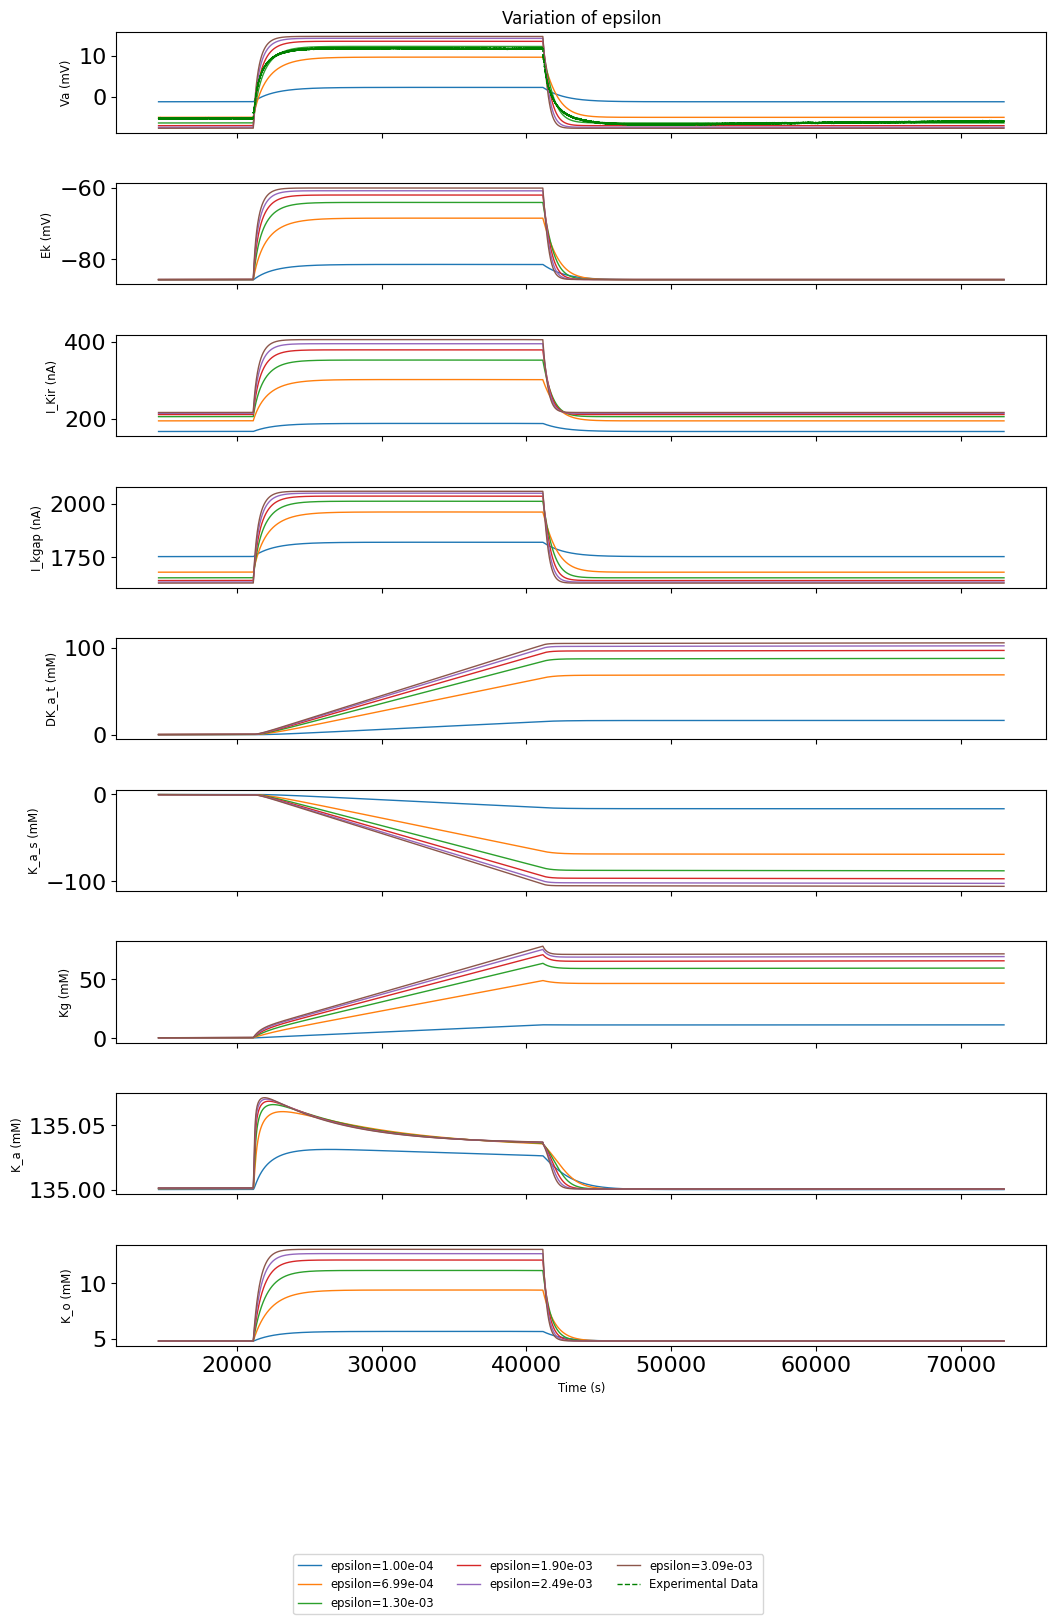

Running simulation for epsilon_middle = 0.25
Running simulation for epsilon_middle = 0.8
Running simulation for epsilon_middle = 1.35
Running simulation for epsilon_middle = 1.9000000000000001
Running simulation for epsilon_middle = 2.45
Running simulation for epsilon_middle = 3.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/epsilon_middle__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


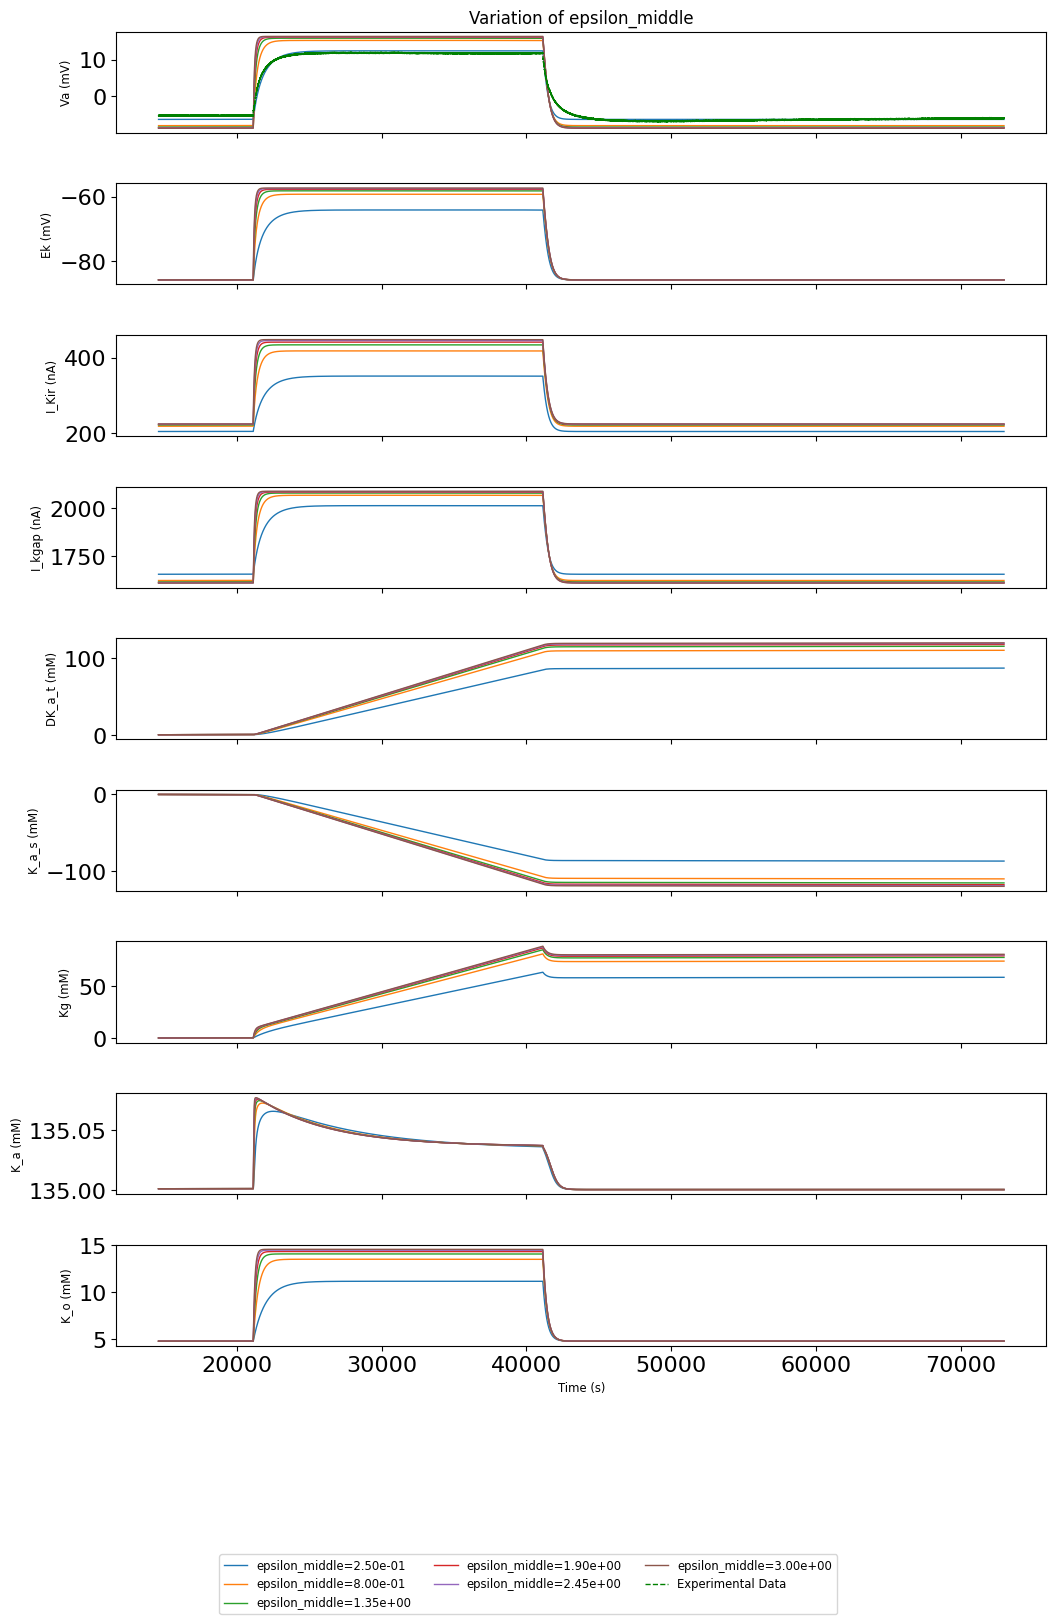

Running simulation for kbath_middle = 11.086559777656124
Running simulation for kbath_middle = 11.486559777656124
Running simulation for kbath_middle = 11.886559777656124
Running simulation for kbath_middle = 12.286559777656123
Running simulation for kbath_middle = 12.686559777656123
Running simulation for kbath_middle = 13.086559777656124
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/kbath_middle__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


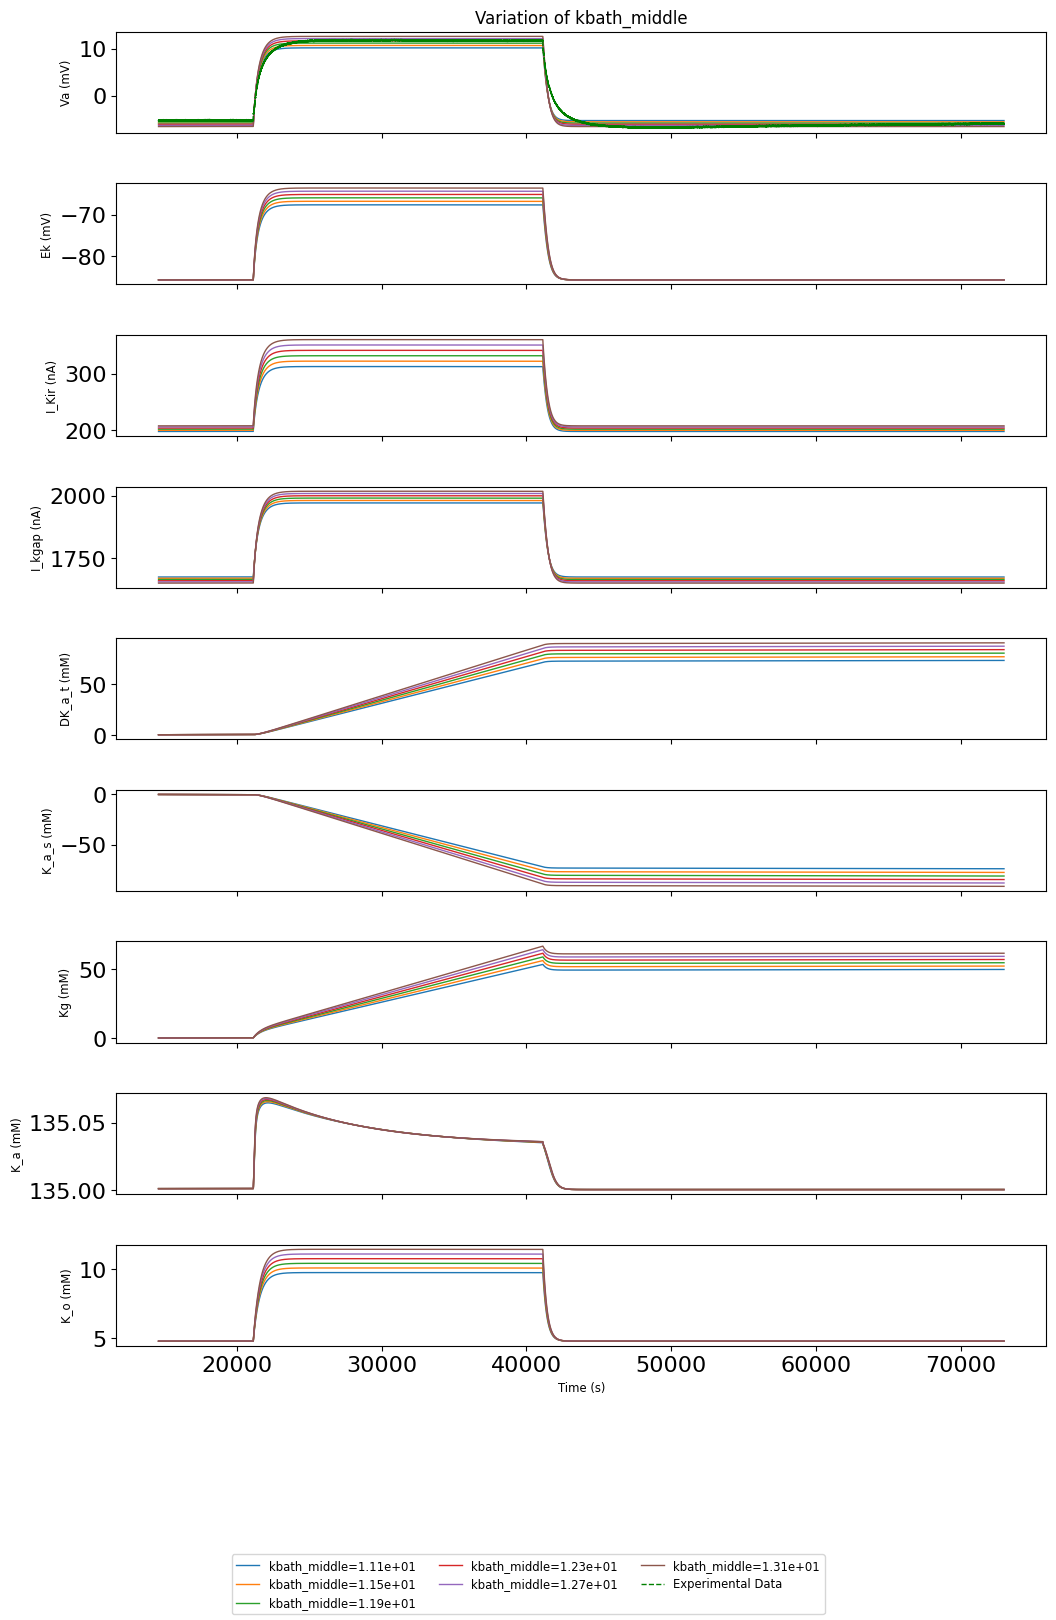

Running simulation for g_kir = 1.0
Running simulation for g_kir = 40.8
Running simulation for g_kir = 80.6
Running simulation for g_kir = 120.39999999999999
Running simulation for g_kir = 160.2
Running simulation for g_kir = 200.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/g_kir__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


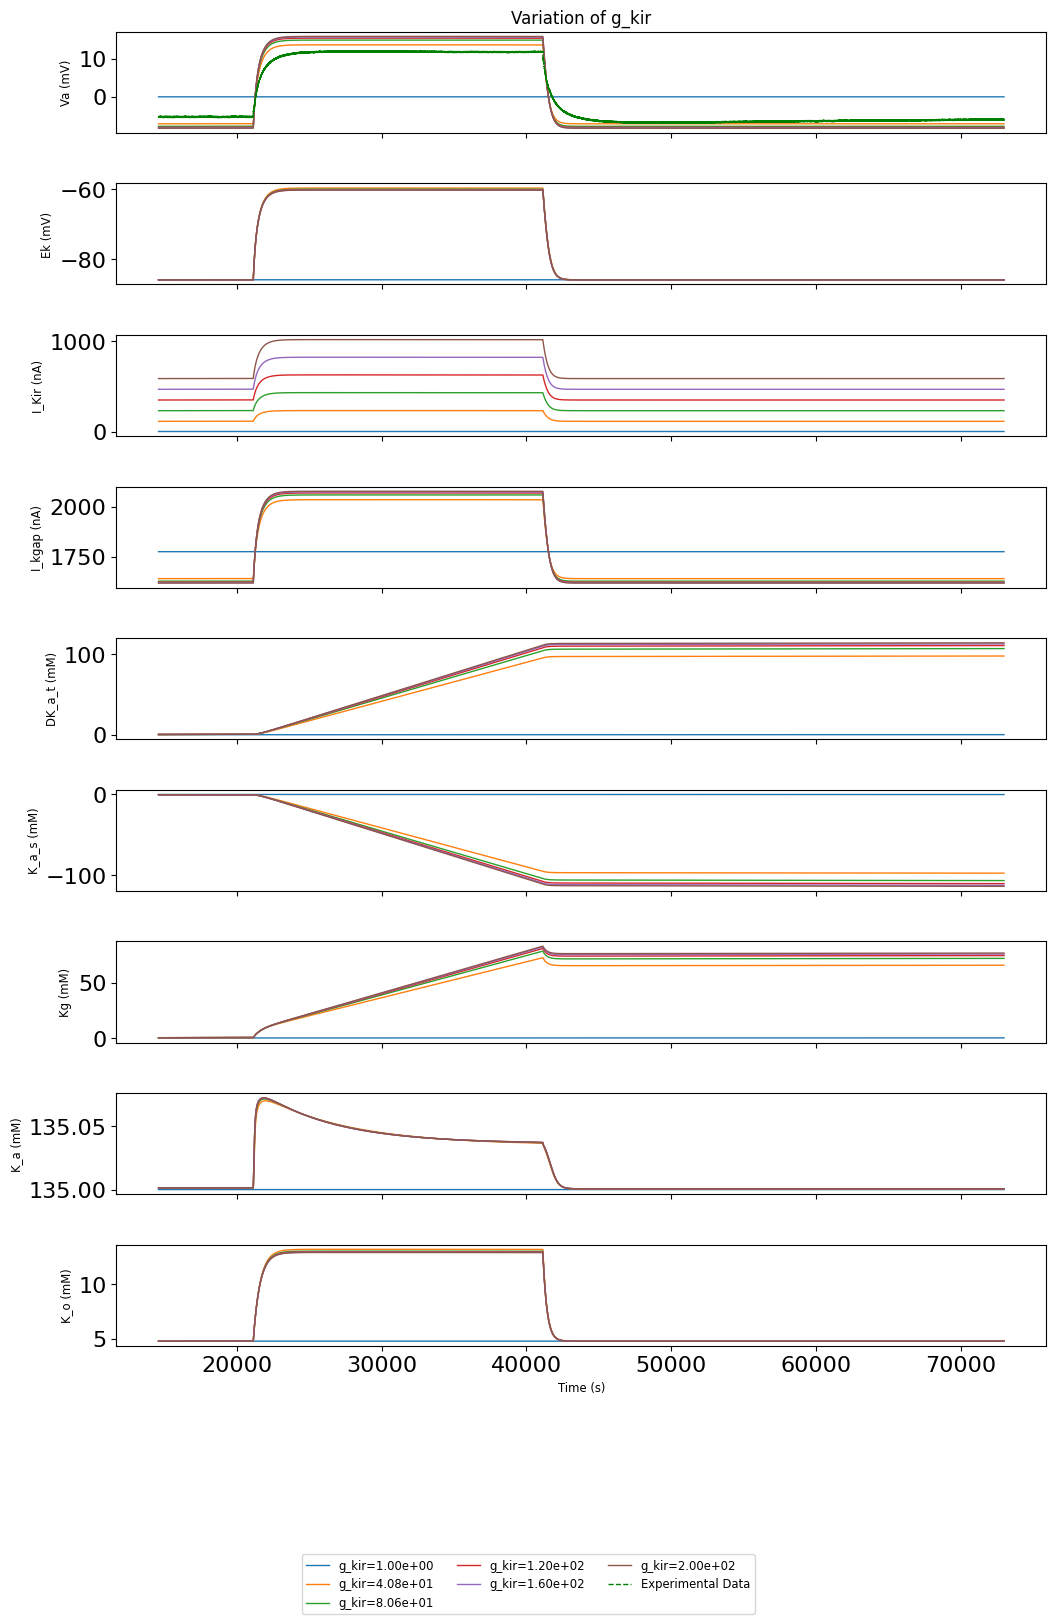

Running simulation for P_k = 3.000000000000001e-07
Running simulation for P_k = 3.0000000000000013e-06
Running simulation for P_k = 3.000000000000001e-05
Running simulation for P_k = 0.00030000000000000014
Running simulation for P_k = 0.003000000000000001
Running simulation for P_k = 0.029999999999999995
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/P_k__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


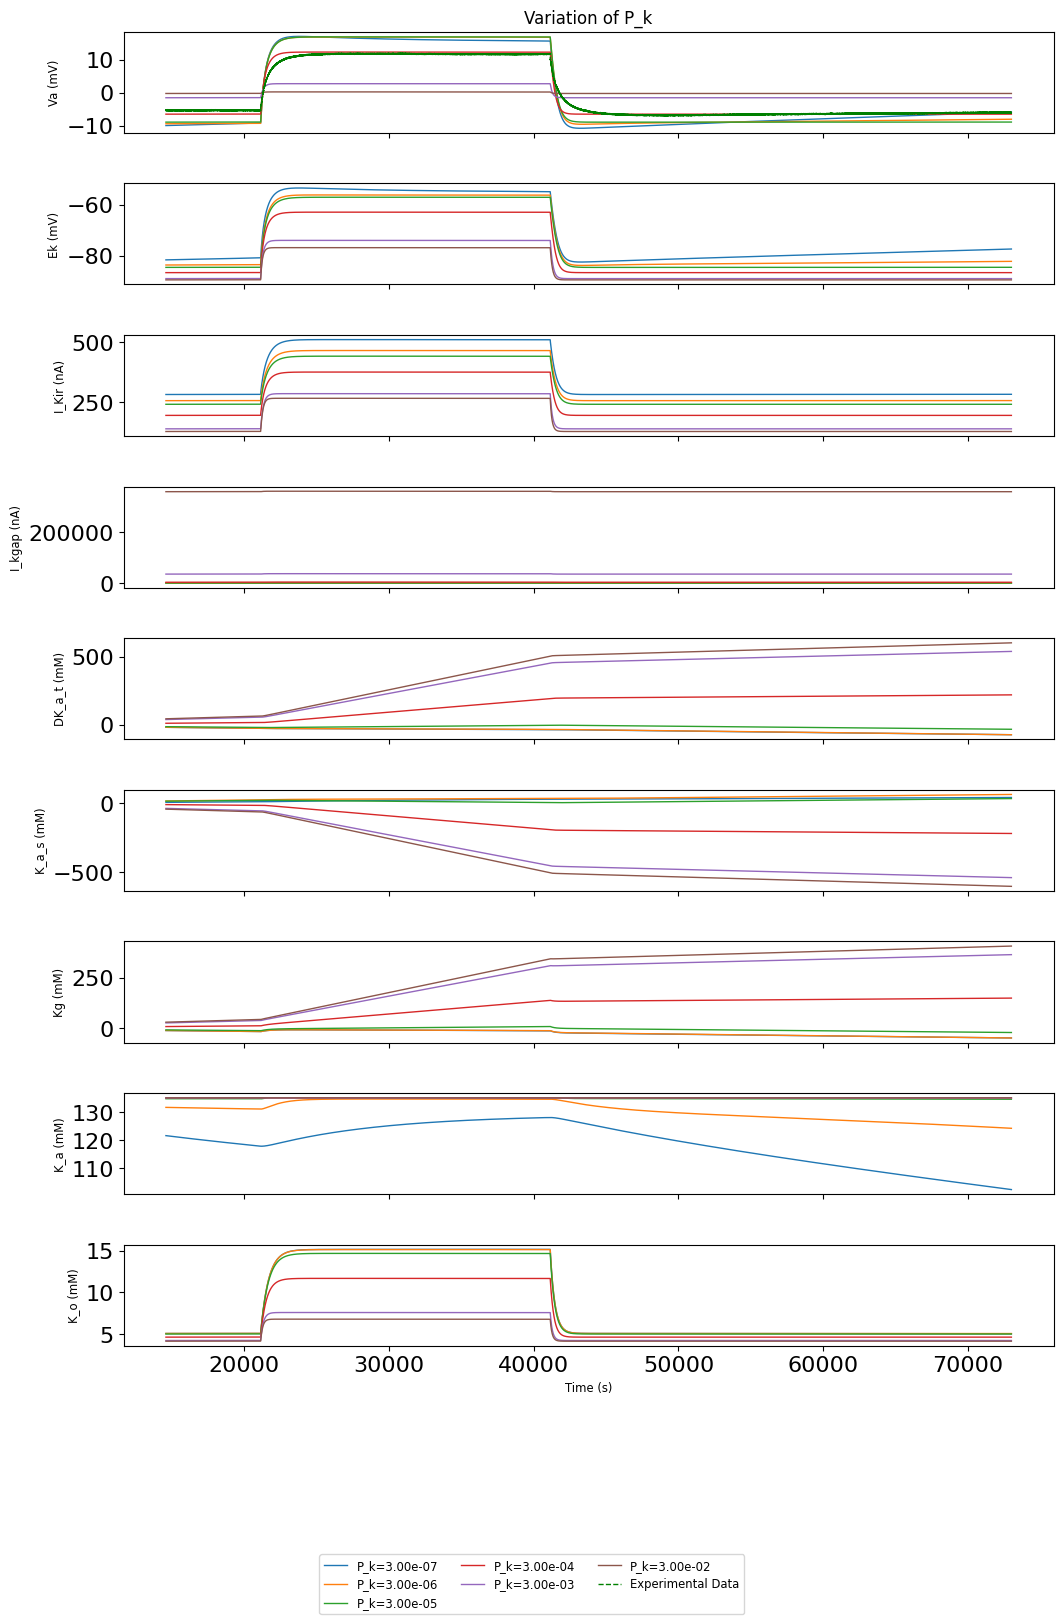

Running simulation for gama_s = 0.1
Running simulation for gama_s = 10.08
Running simulation for gama_s = 20.060000000000002
Running simulation for gama_s = 30.040000000000003
Running simulation for gama_s = 40.02
Running simulation for gama_s = 50.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/gama_s__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


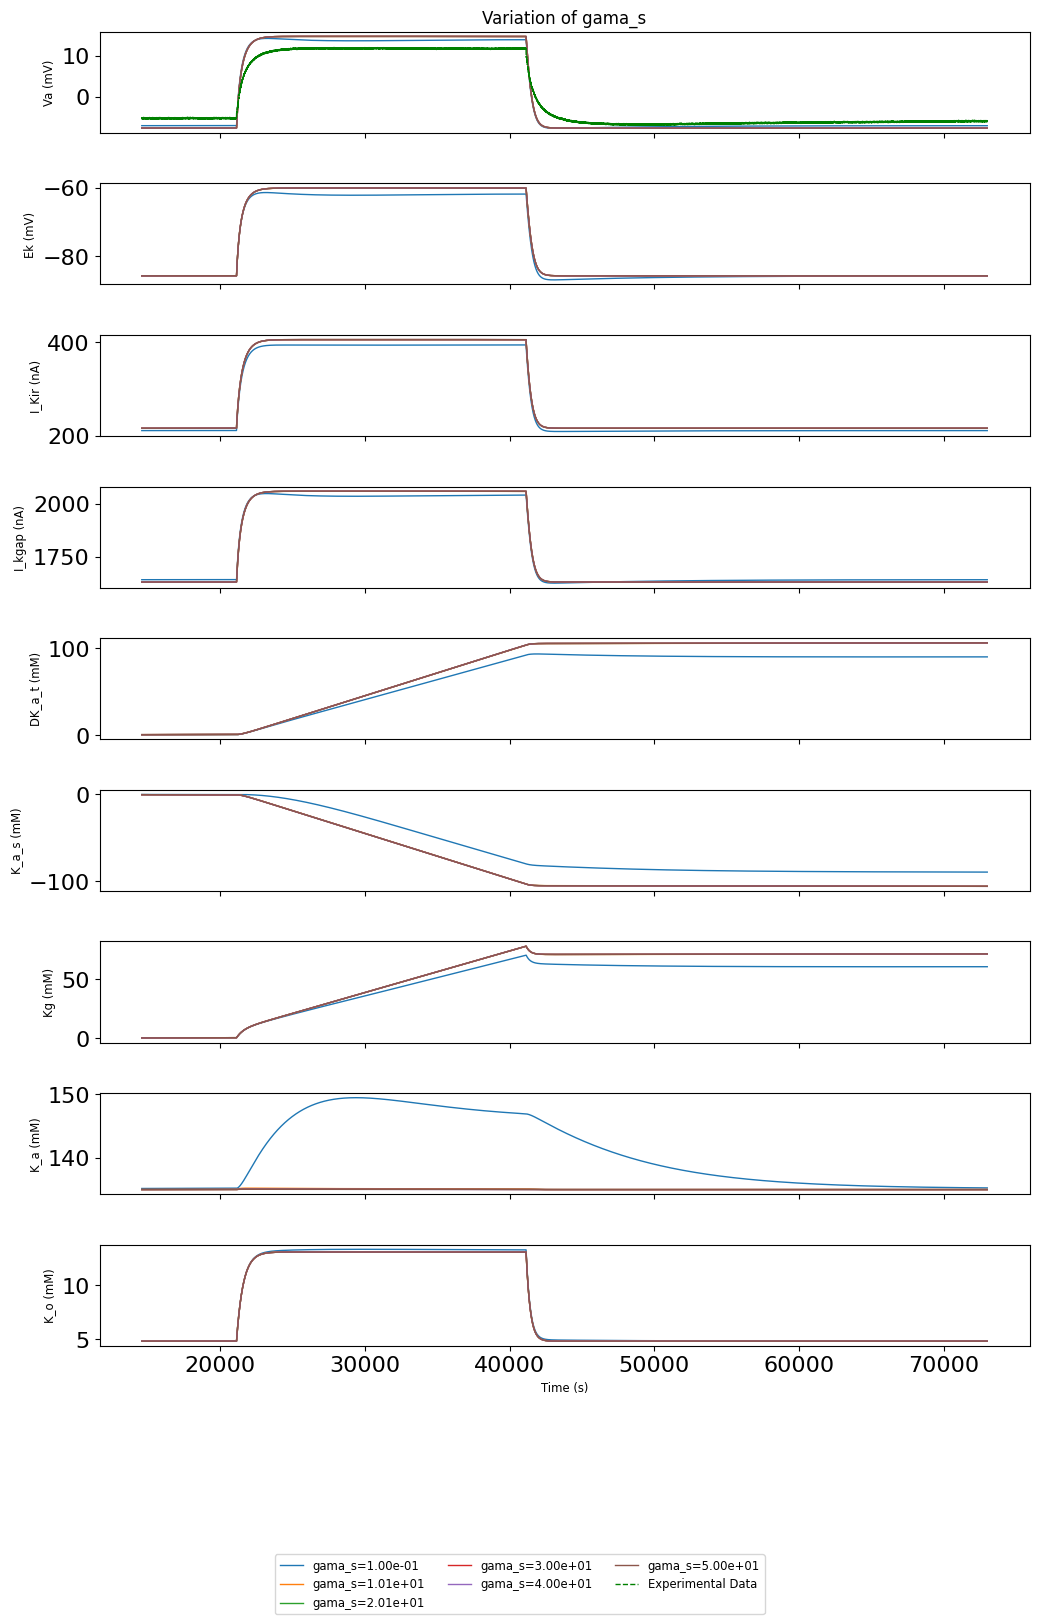

Running simulation for gama_t = 0.1
Running simulation for gama_t = 20.080000000000002
Running simulation for gama_t = 40.06
Running simulation for gama_t = 60.04
Running simulation for gama_t = 80.02
Running simulation for gama_t = 100.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/gama_t__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


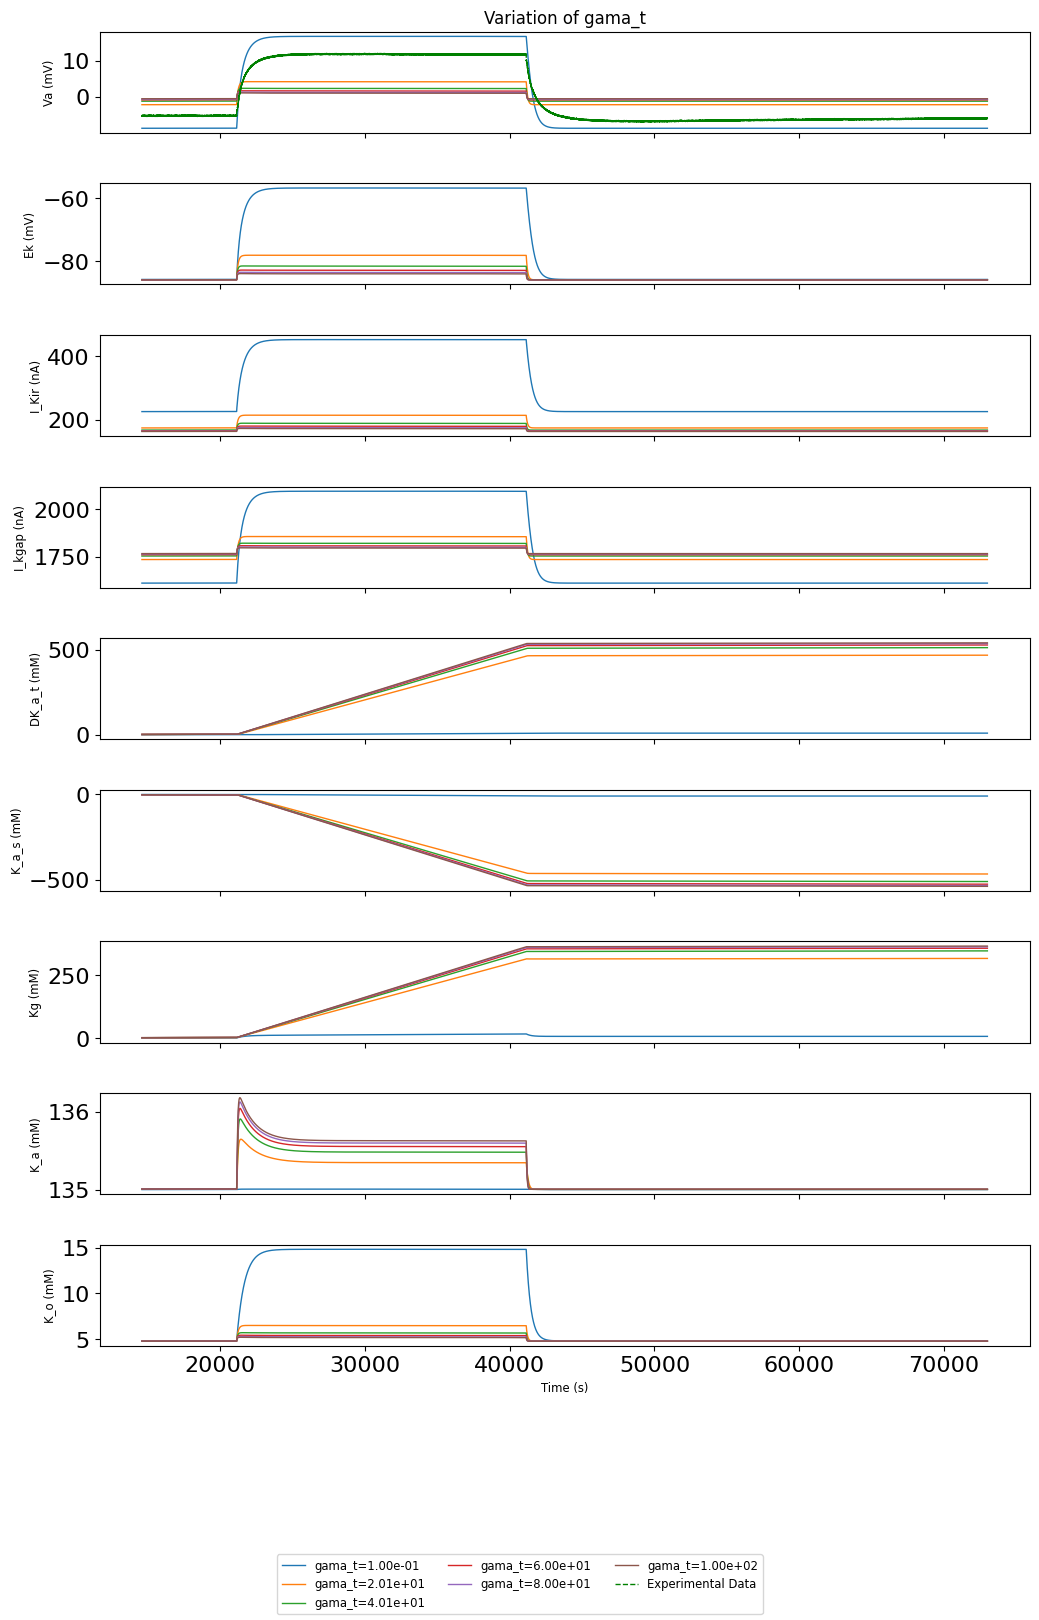

Running simulation for Cm_a = 1.0
Running simulation for Cm_a = 200.8
Running simulation for Cm_a = 400.6
Running simulation for Cm_a = 600.4000000000001
Running simulation for Cm_a = 800.2
Running simulation for Cm_a = 1000.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/Cm_a__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


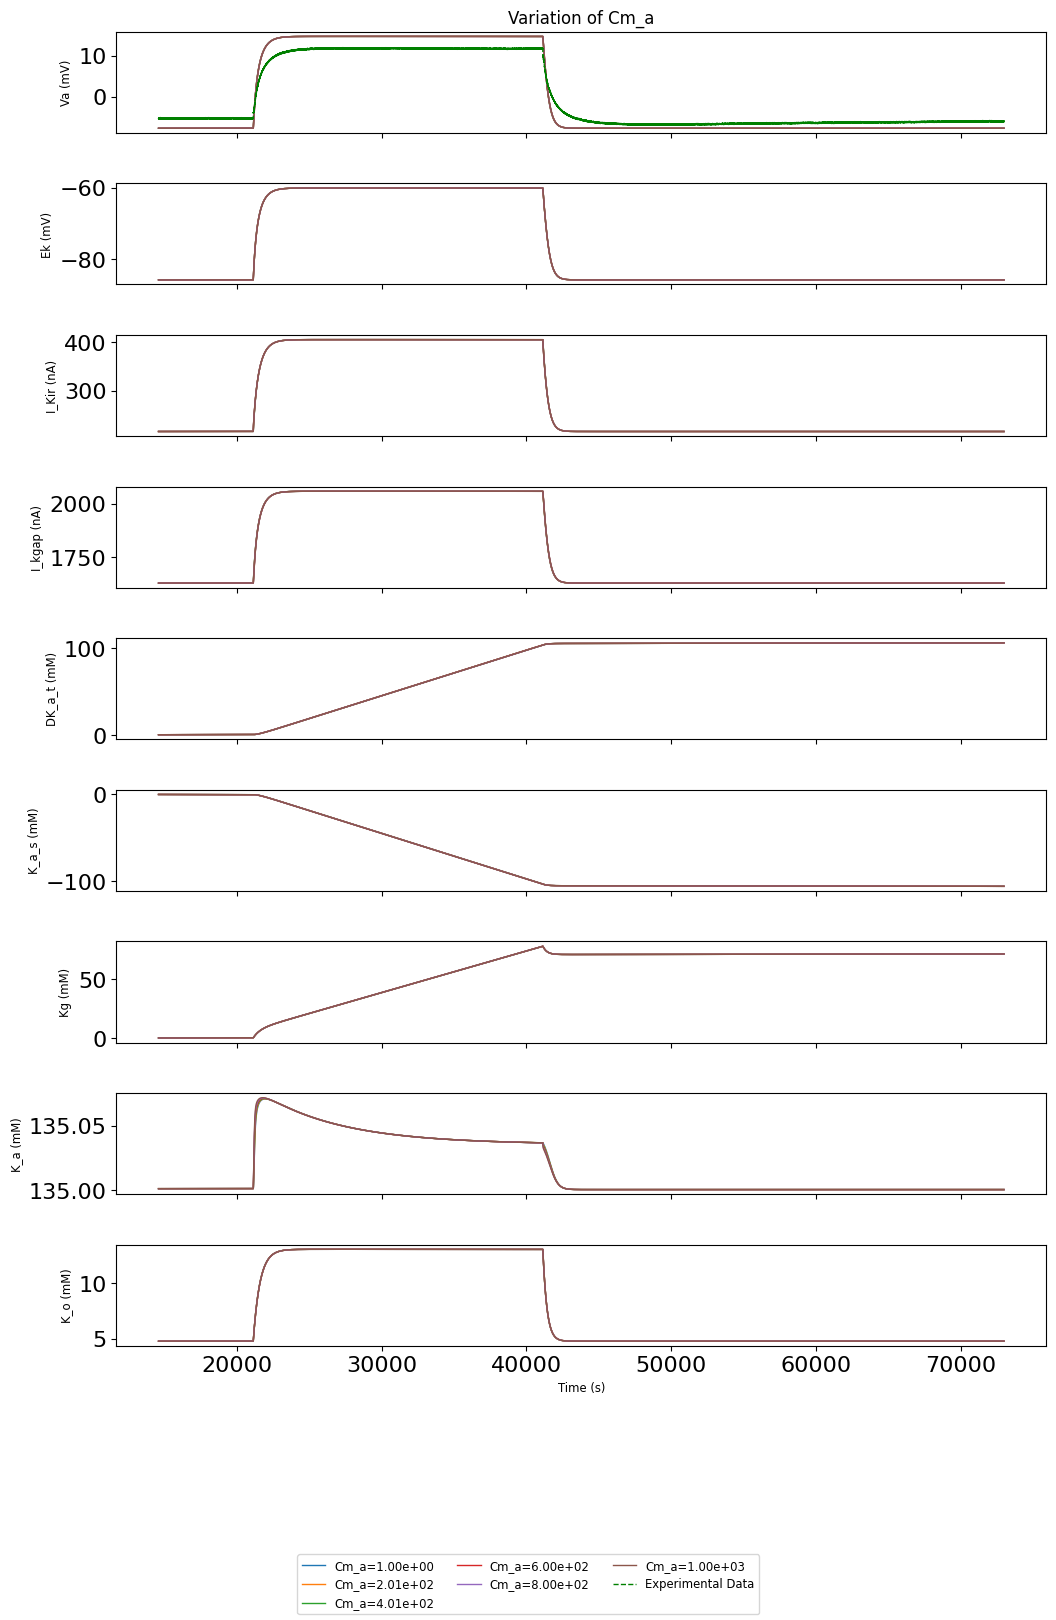

Running simulation for d_gap = 0.0
Running simulation for d_gap = 2.0
Running simulation for d_gap = 4.0
Running simulation for d_gap = 6.0
Running simulation for d_gap = 8.0
Running simulation for d_gap = 10.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/d_gap__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


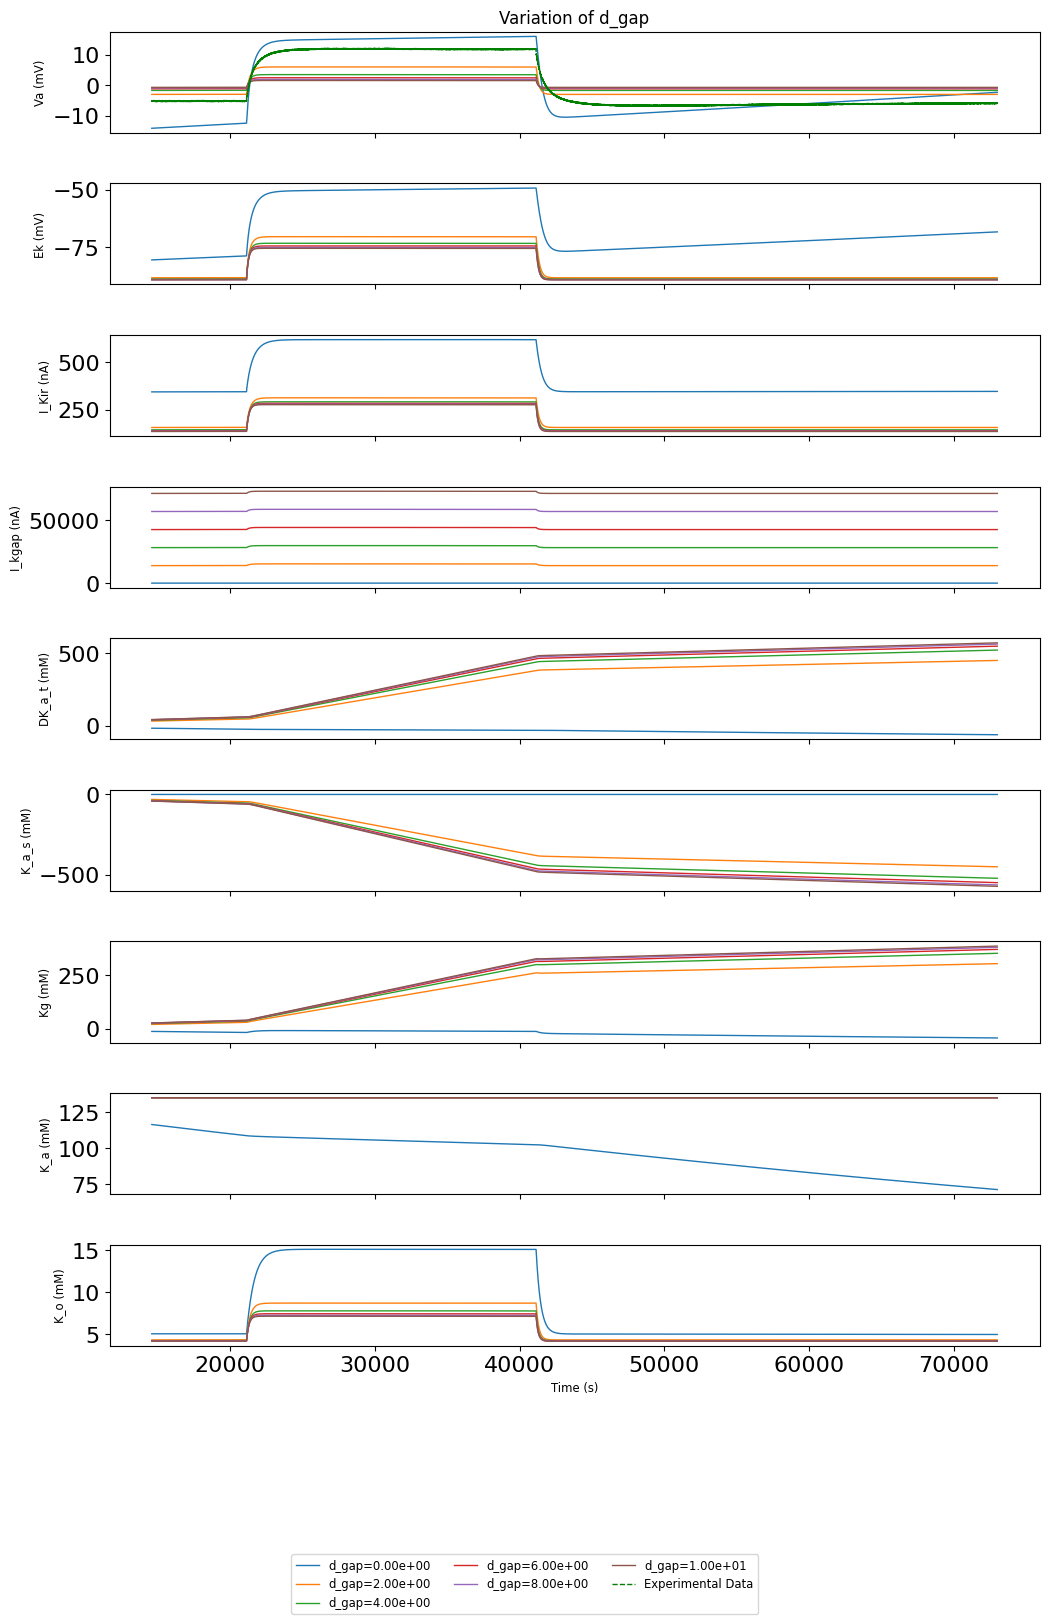

param_max for wo updated from 2400.0 to: 2986.6247190162417
Running simulation for w_o = 300.0
Running simulation for w_o = 837.3249438032483
Running simulation for w_o = 1374.6498876064966
Running simulation for w_o = 1911.9748314097449
Running simulation for w_o = 2449.299775212993
Running simulation for w_o = 2986.6247190162417
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/w_o__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


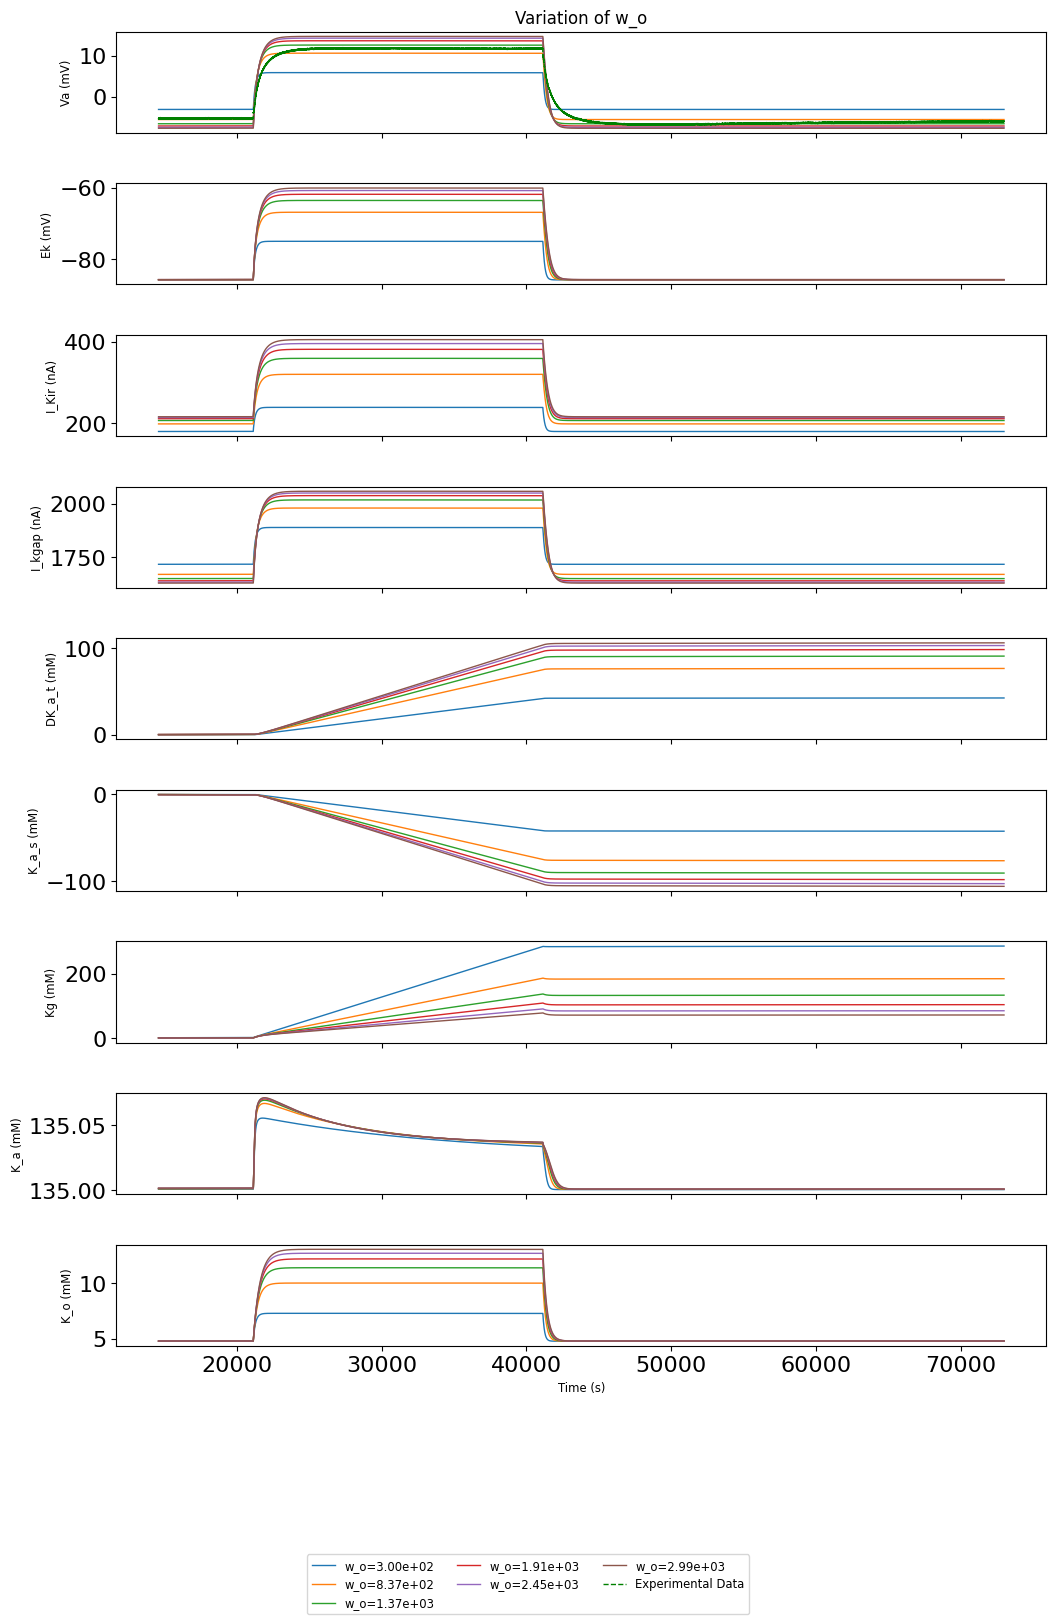

Running simulation for w_a = 1000.0
Running simulation for w_a = 1500.0
Running simulation for w_a = 2000.0
Running simulation for w_a = 2500.0
Running simulation for w_a = 3000.0
Running simulation for w_a = 3500.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/w_a__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


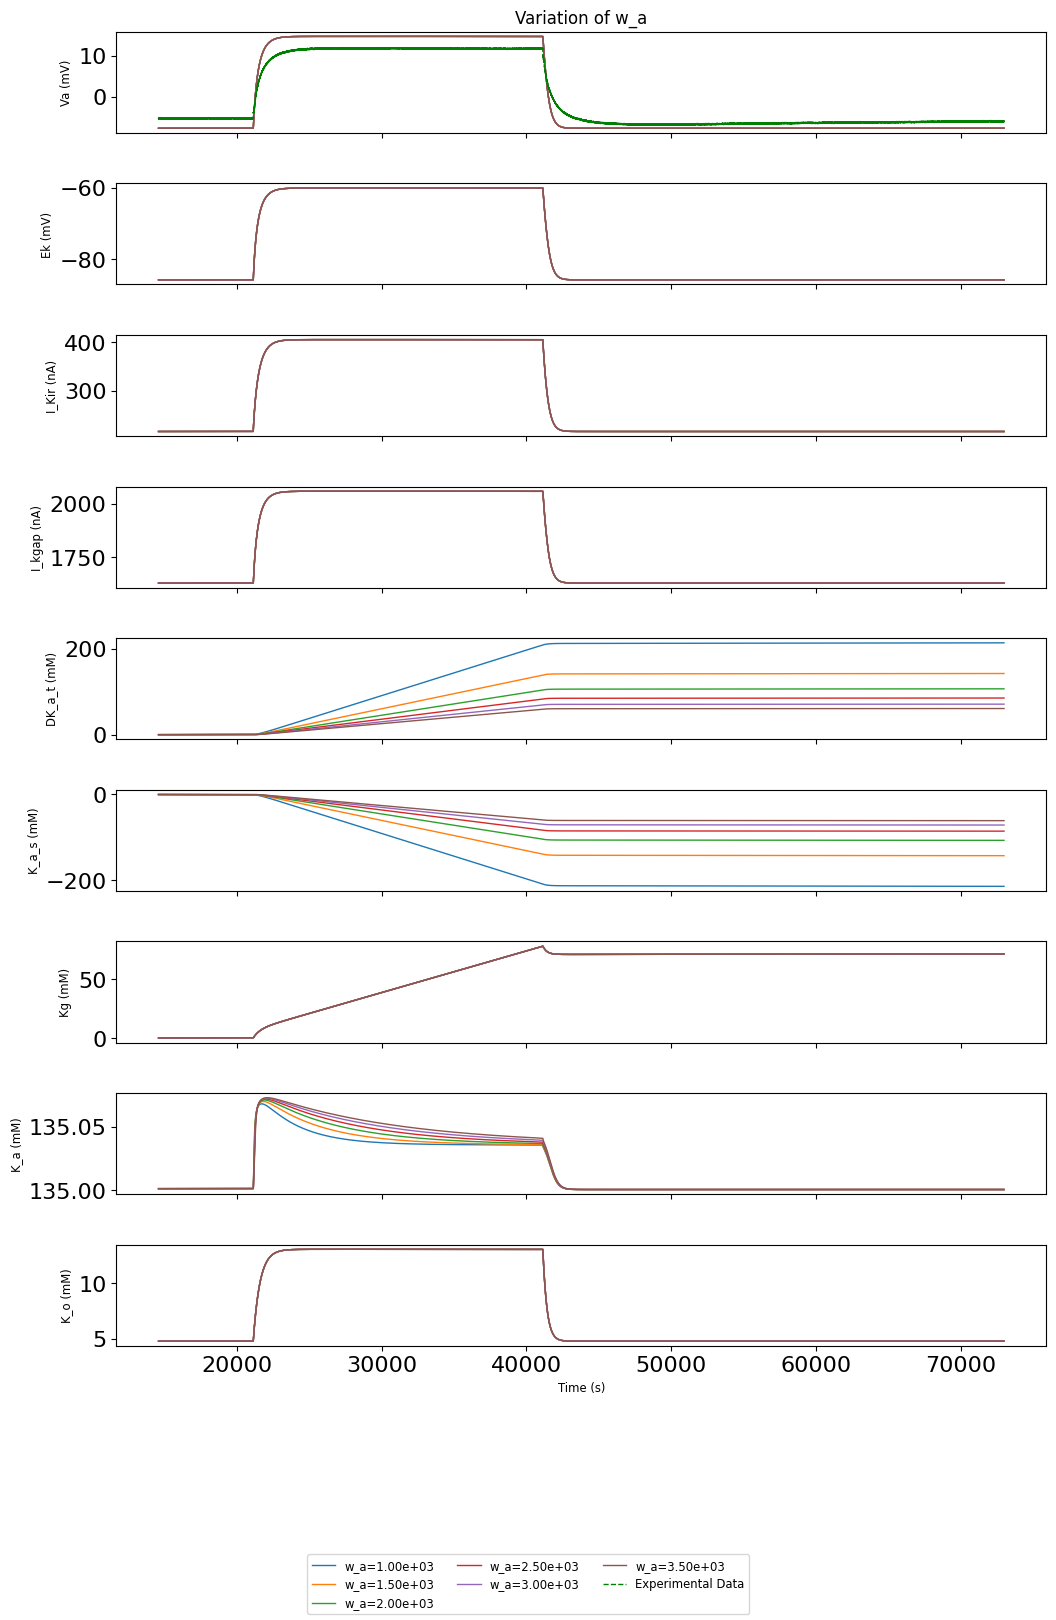

Running simulation for gl_a = 0.001
Running simulation for gl_a = 0.007860030855966229
Running simulation for gl_a = 0.0617800850567412
Running simulation for gl_a = 0.4855933748302039
Running simulation for gl_a = 3.8167789096181775
Running simulation for gl_a = 29.999999999999996
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/gl_a__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


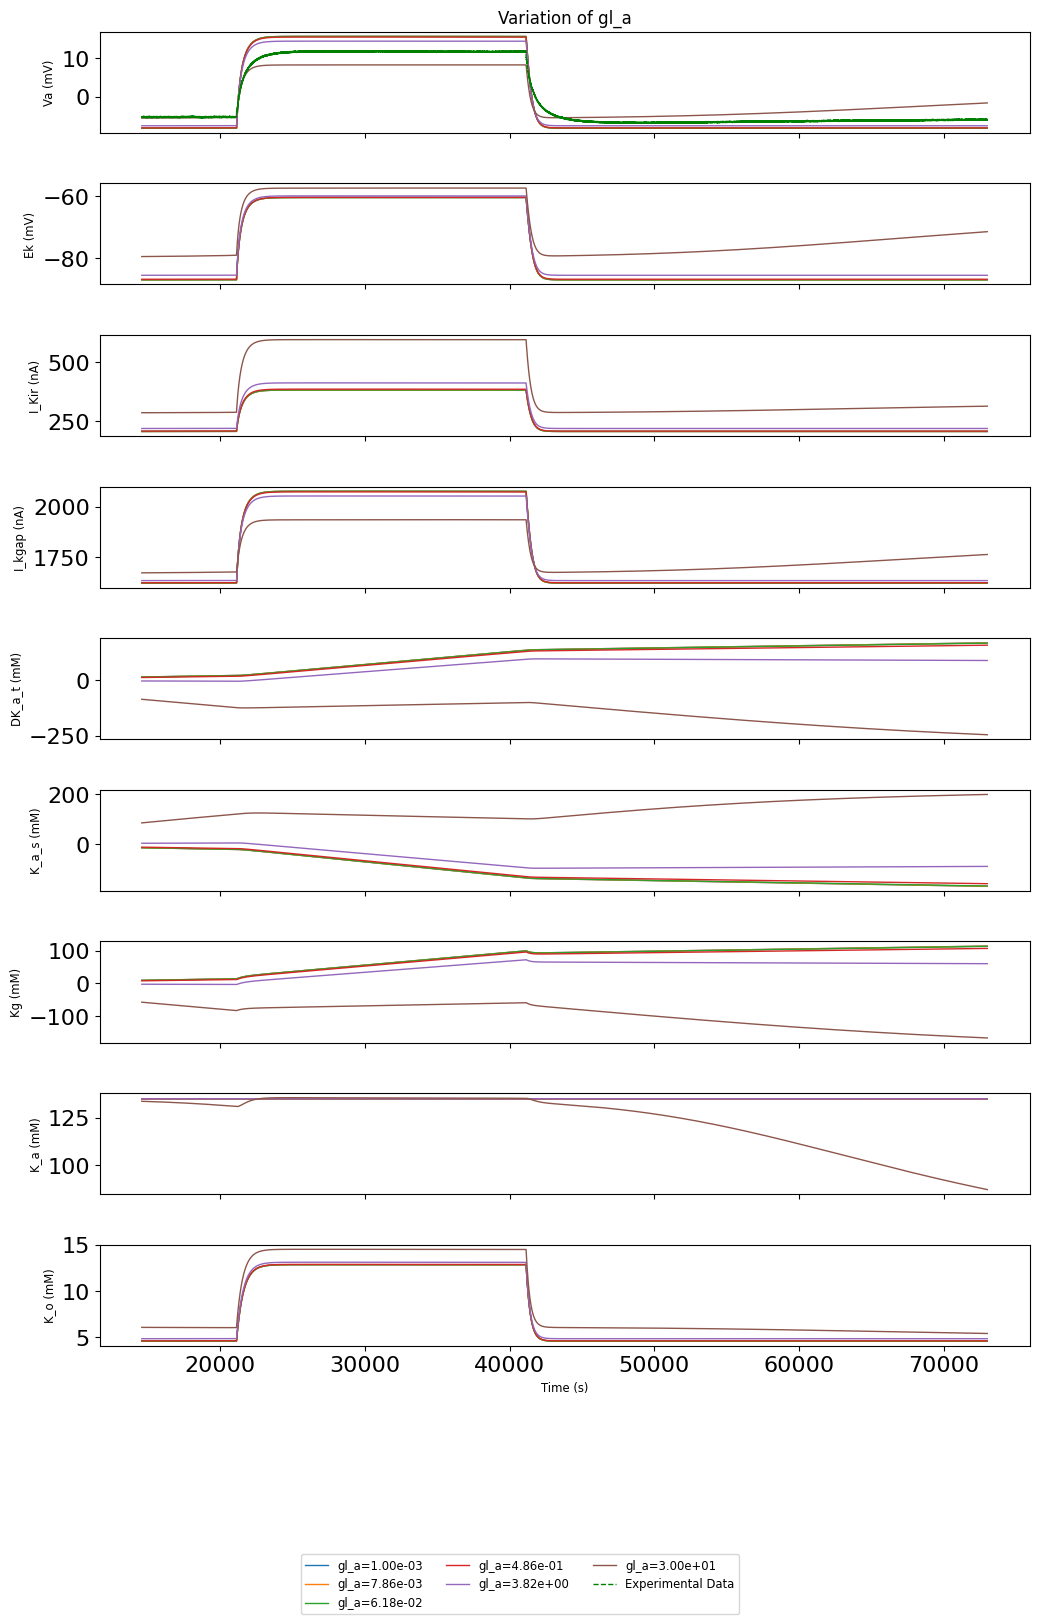

Running simulation for Va_s = -100.0
Running simulation for Va_s = -98.0
Running simulation for Va_s = -96.0
Running simulation for Va_s = -94.0
Running simulation for Va_s = -92.0
Running simulation for Va_s = -90.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/Va_s__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


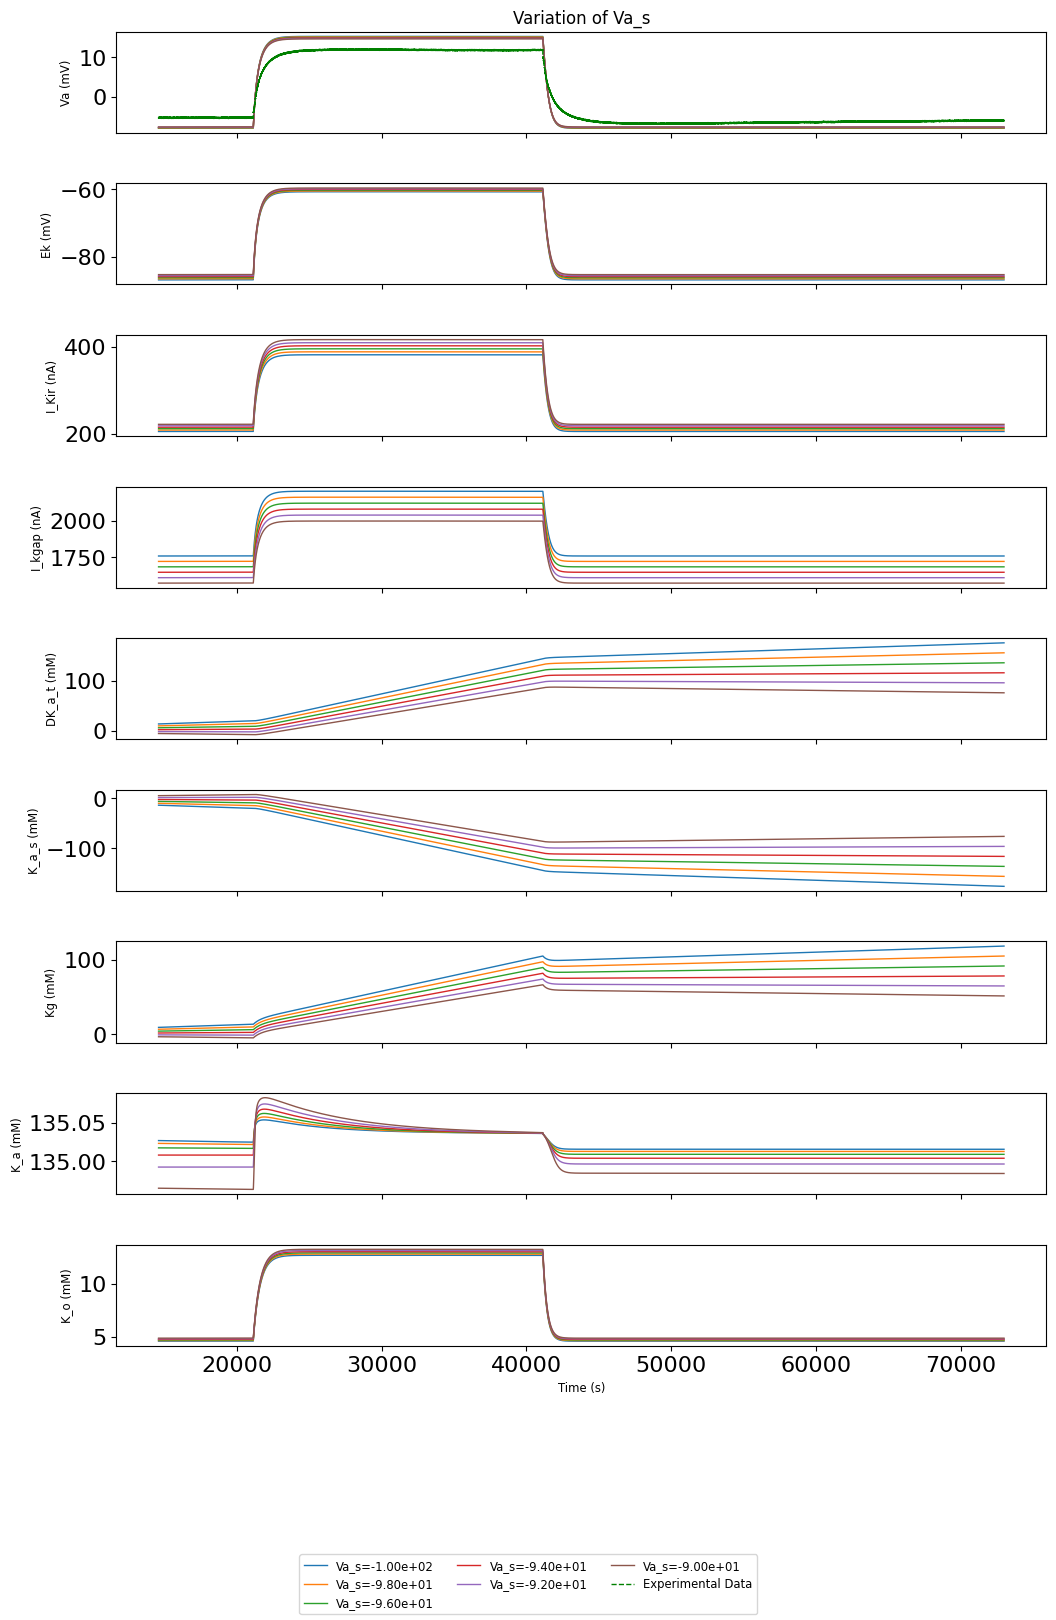

Running simulation for Va_l = -70.0
Running simulation for Va_l = -64.0
Running simulation for Va_l = -58.0
Running simulation for Va_l = -52.0
Running simulation for Va_l = -46.0
Running simulation for Va_l = -40.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/Va_l__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


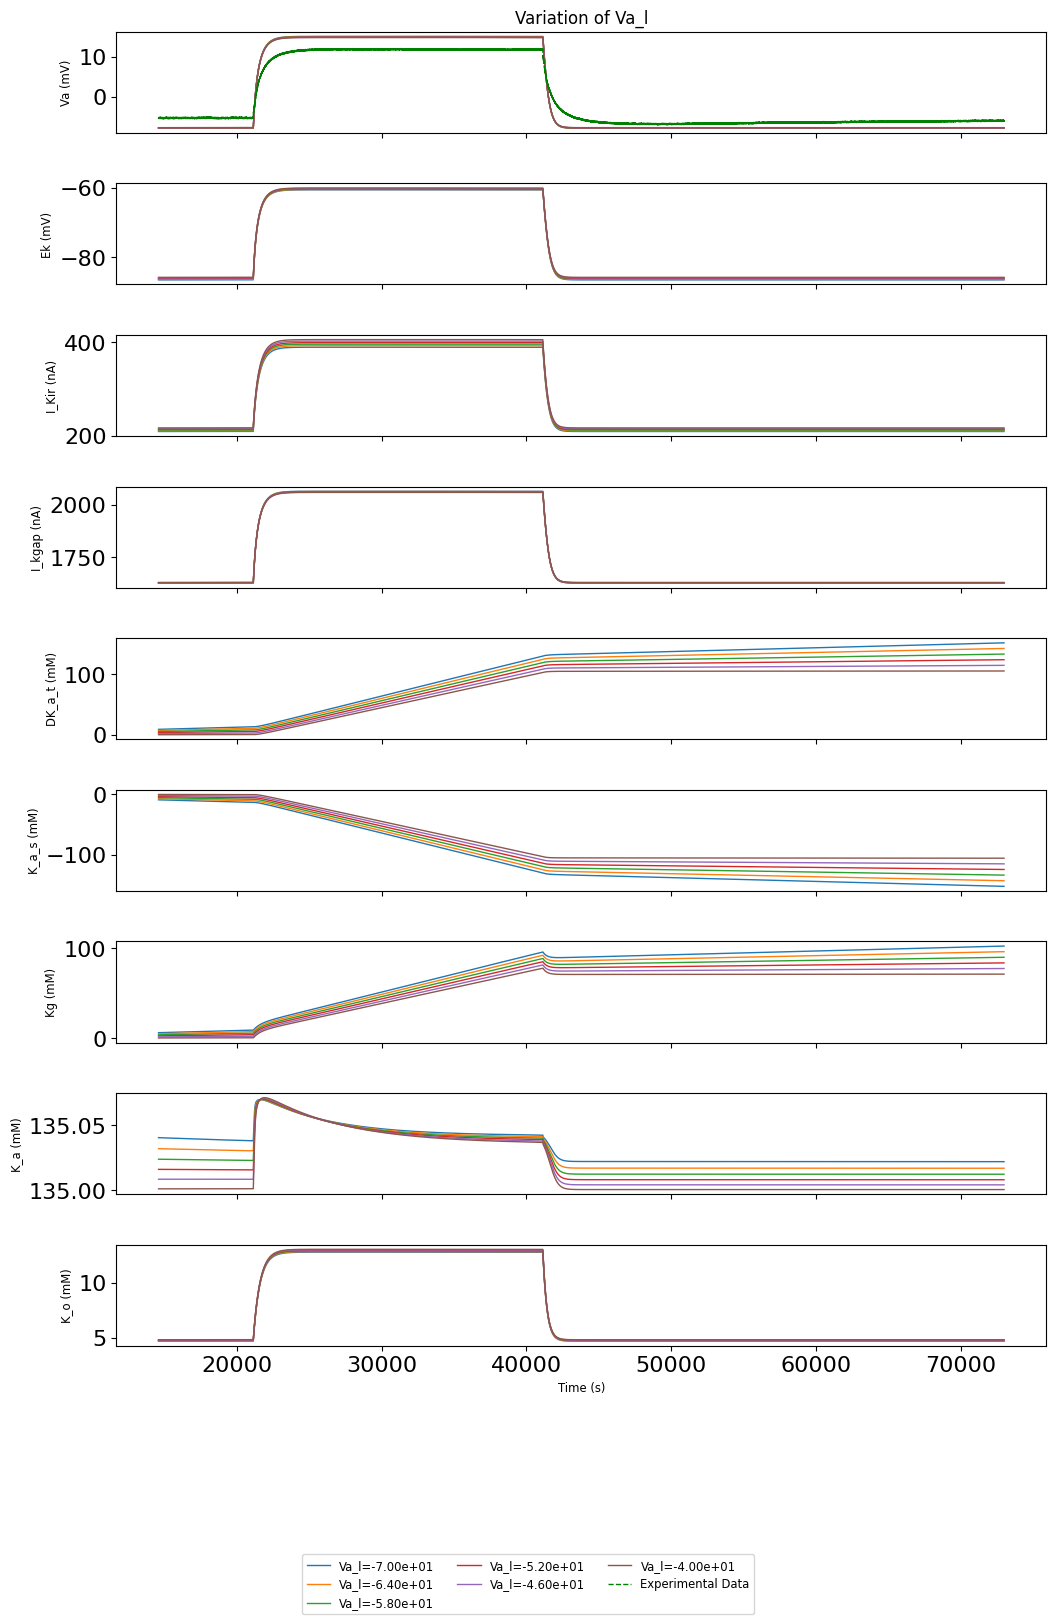

Running simulation for Z_th = 2.0
Running simulation for Z_th = 31.6
Running simulation for Z_th = 61.2
Running simulation for Z_th = 90.80000000000001
Running simulation for Z_th = 120.4
Running simulation for Z_th = 150.0
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/Z_th__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


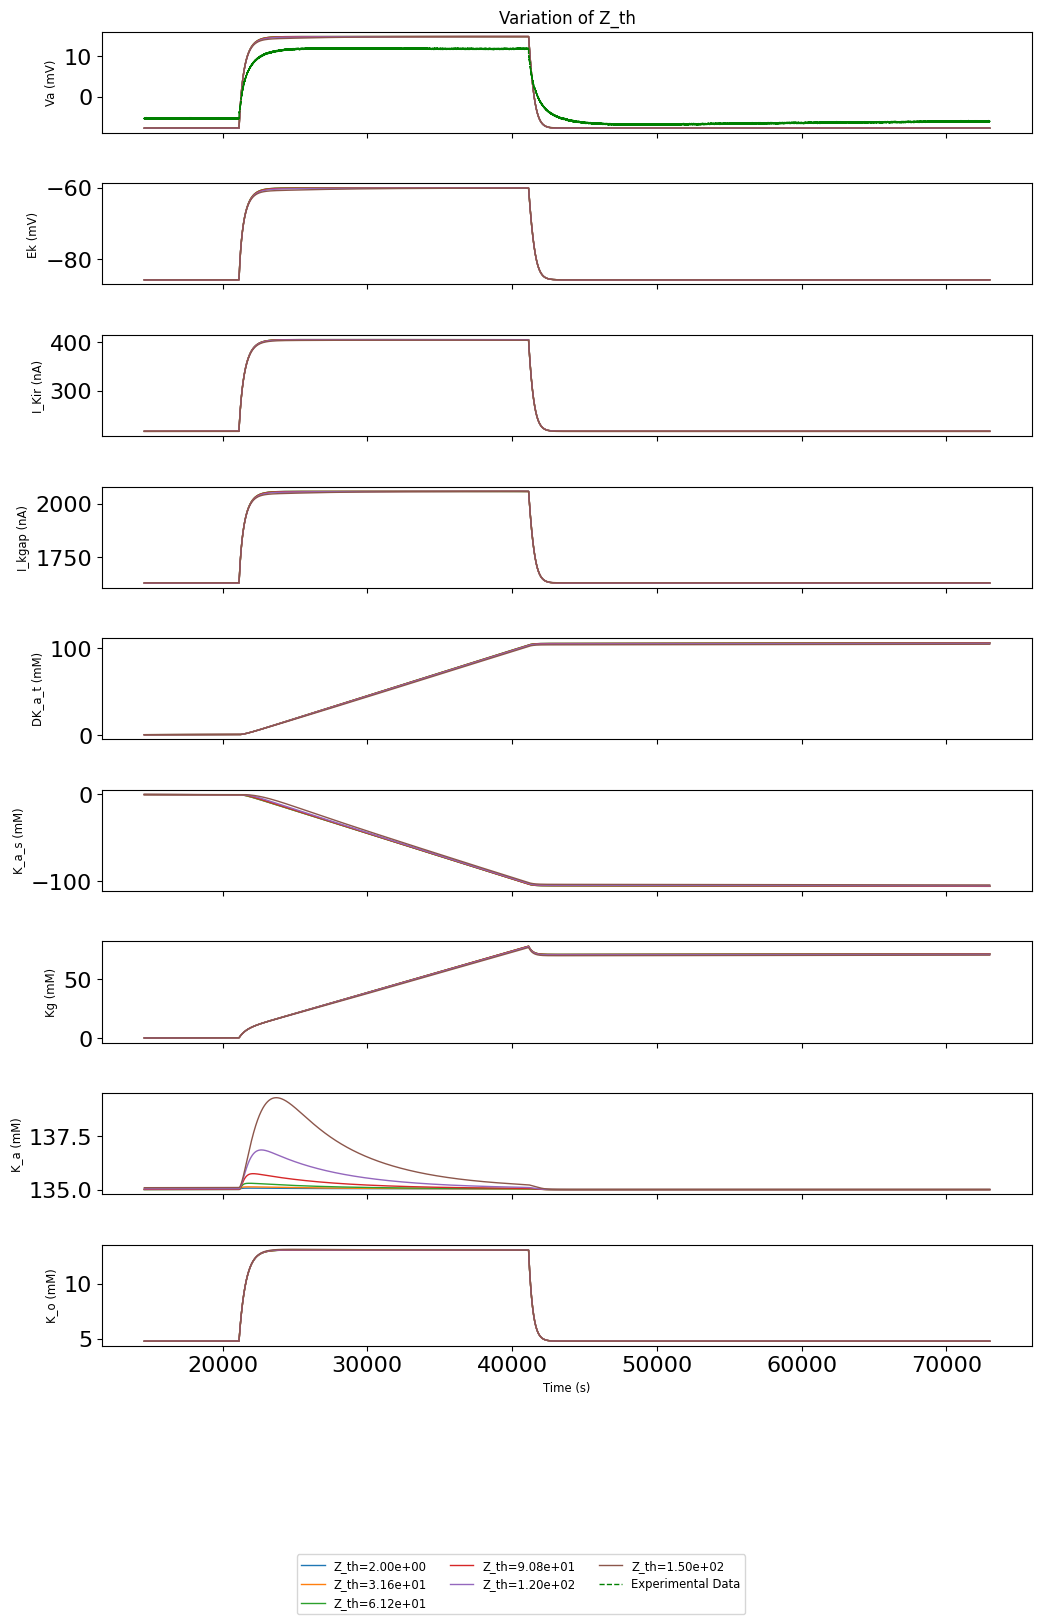

Running simulation for Z_s = 0.004999999999999999
Running simulation for Z_s = 0.026265278044037672
Running simulation for Z_s = 0.1379729661461215
Running simulation for Z_s = 0.7247796636776962
Running simulation for Z_s = 3.807307877431759
Running simulation for Z_s = 20.000000000000004
Plot saved to MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/Z_s__Astrocyte_Cm_a345.00_g_kir75.21_g_k_a0.00_w_a2020.46_P_k0.00_A1.00_gl_a2.97_Va_l-40.23_Va_s-93.00_d_variations.png


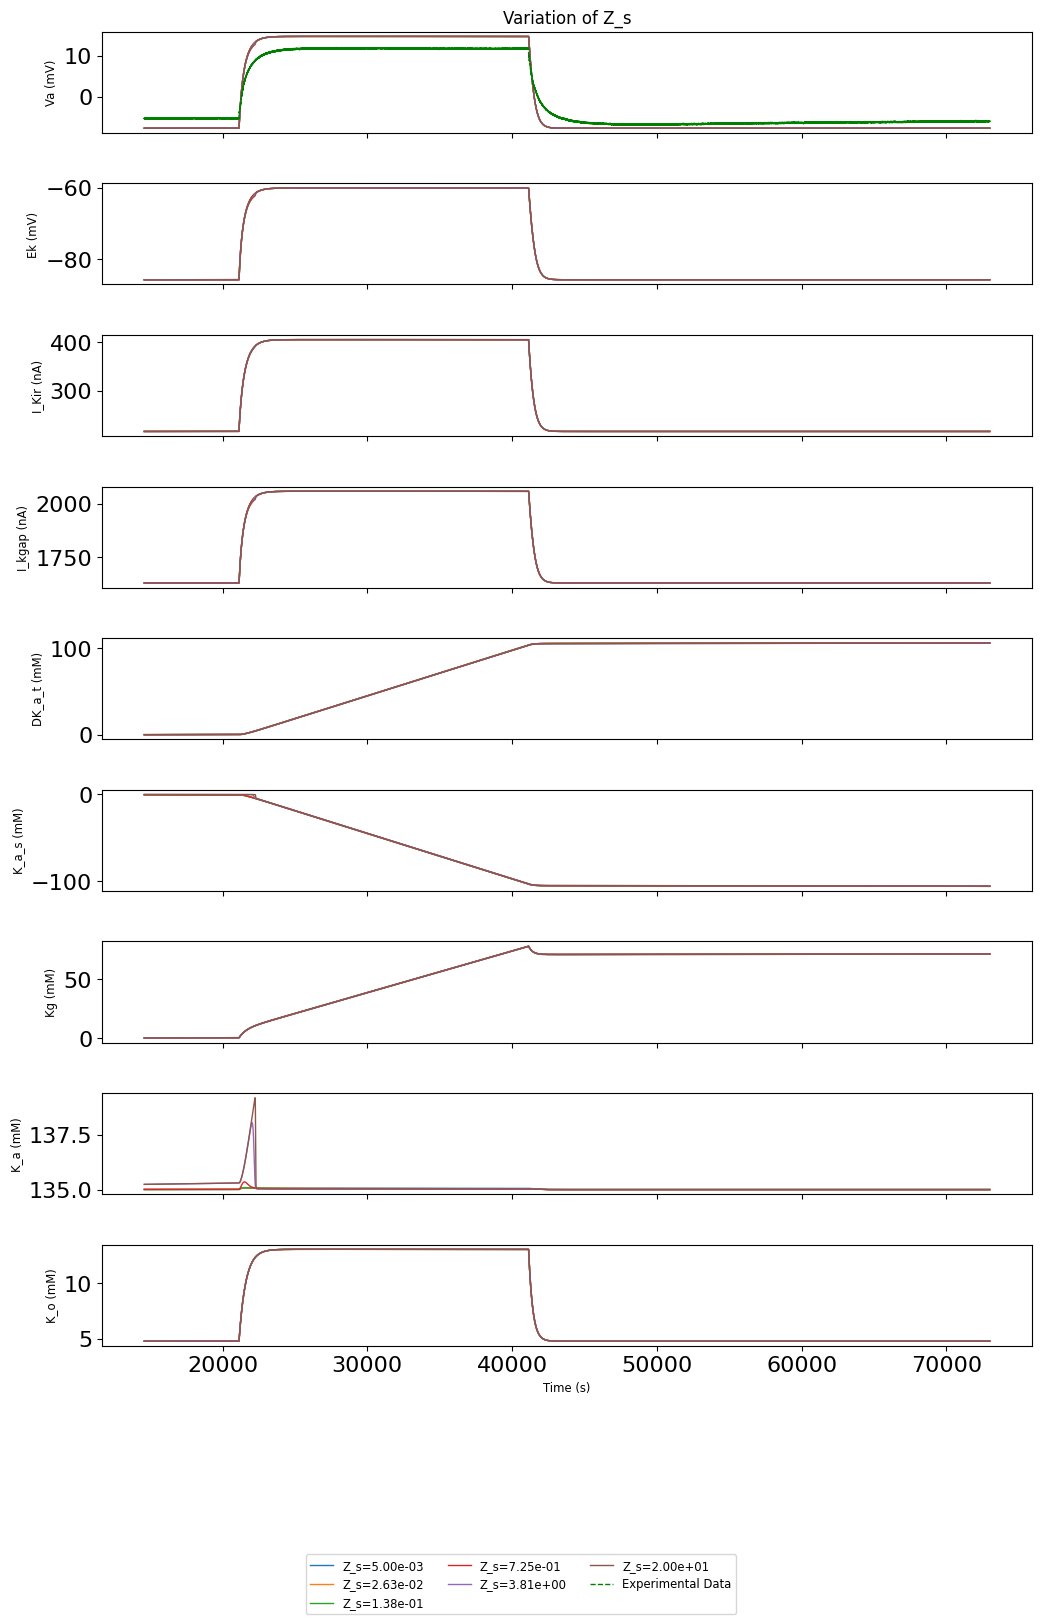

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import odeint
import copy
import re
import gc

def simulate_and_plot(
    param_name,
    param_min,
    param_max,
    num_values=12,
    t=None,
    z0=None,
    paramdict_Default=None,
    stable_index_simulation=None,
    current_X_stable=None,
    experimental_data=None,
    plots_dir='plots'
):
    """
    Simulates and plots model variables while varying a specified parameter.

    Parameters:
    - param_name (str): The name of the parameter to vary.
    - param_min (float): The minimum value of the parameter.
    - param_max (float): The maximum value of the parameter.
    - num_values (int): Number of parameter values to simulate.
    - t (np.ndarray): Time array for the simulation.
    - z0 (list or np.ndarray): Initial conditions for the simulation.
    - paramdict_Default (dict): Default parameter dictionary.
    - stable_index_simulation (int): Index to slice the stable part of the simulation.
    - current_X_stable (np.ndarray): Experimental Va data corresponding to the stable simulation period.
    - experimental_data (dict, optional): Dictionary with keys 'time' and 'Va' for experimental Va data.
    - plots_dir (str): Directory where plots will be saved.
    """
    if paramdict_Default is None or t is None or z0 is None:
        raise ValueError("paramdict_Default, t, and z0 must be provided.")

    if stable_index_simulation is None or current_X_stable is None:
        raise ValueError("stable_index_simulation and current_X_stable must be provided.")

    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)

    # Decide whether to use linspace or logspace based on the parameter range
    if param_min > 0 and (param_max / param_min) > 1000:
        param_values = np.logspace(np.log10(param_min), np.log10(param_max), num_values)
    else:
        param_values = np.linspace(param_min, param_max, num_values)

    # Increase font size of ticks
    mpl.rcParams['xtick.labelsize'] = 16
    mpl.rcParams['ytick.labelsize'] = 16

    # Define line width
    line_width = 1.0

    # Create figure and subplots
    fig, axs = plt.subplots(9, 1, figsize=(12, 18), sharex=False)
    fig.subplots_adjust(hspace=0.5)

    # Lists to store line objects and labels for the legend
    sim_lines = []
    sim_labels = []

    # Iterate over each parameter value
    for value in param_values:
        print(f"Running simulation for {param_name} = {value}")
        paramdict = copy.deepcopy(paramdict_Default)

        # Update the parameter in the parameter dictionary
        if param_name == "kbath_middle":
            paramdict["external"]["K_bath"]["value"][1] = value
        elif param_name in paramdict["Astrocyte"]:
            paramdict["Astrocyte"][param_name] = value
        elif param_name in paramdict["external"]:
            paramdict["external"][param_name] = value
        else:
            print(f"Parameter {param_name} not found in parameter dictionary.")
            continue  # Skip to the next value

        # Run the simulation
        try:
            z = odeint(model, z0, t, args=(paramdict,))
        except Exception as e:
            print(f"Simulation failed for {param_name} = {value}: {e}")
            continue  # Skip to the next value if simulation fails

        # Remove the transient part from `z`
        z_stable = z[stable_index_simulation:]

        # Extract variables from simulation results
        Va = z_stable[:, 0]
        DK_a_t = z_stable[:, 1]
        K_a_s = z_stable[:, 2]
        Kg = z_stable[:, 3]

        # Center the simulation Va data to match experimental data
        Va_centered = Va - np.mean(Va)

        # Calculate dependent variables
        K_a0 = paramdict_Default["Astrocyte"]["K_a0"]
        K_o0 = paramdict_Default["external"]["K_o0"]
        w_a = paramdict["Astrocyte"]["w_a"]
        w_o = paramdict["external"]["w_o"]
        K_a = DK_a_t + K_a_s + K_a0
        K_o = K_o0 - (w_a / w_o) * DK_a_t + Kg
        E_k_a = 25.7 * np.log(np.abs(K_o / K_a))

        # Calculate currents
        g_k_a = paramdict["Astrocyte"]["g_k_a"]
        I_k_a = g_k_a * (Va_centered - E_k_a)
        A = paramdict["Astrocyte"]["A"]
        g_kir = paramdict["Astrocyte"]["g_kir"]
        I_Kir = A * g_kir * np.sqrt(np.abs(K_o)) * (Va_centered - E_k_a) / (1 + np.exp((Va_centered - E_k_a) / 19.2))
        gl_a = paramdict["Astrocyte"]["gl_a"]
        Va_l = paramdict["Astrocyte"]["Va_l"]
        I_l_a = gl_a * (Va_centered - Va_l)

        # Calculate I_kgap
        P_k = paramdict["Astrocyte"]["P_k"]
        d_gap = paramdict["Astrocyte"]["d_gap"]
        F = paramdict["Astrocyte"]["F"]
        Va_s = paramdict["Astrocyte"]["Va_s"]
        PH_a = 0.04 * (Va_centered - Va_s)
        exp_neg_PH_a = np.exp(-PH_a)
        denom = -1 + exp_neg_PH_a
        denom[denom == 0] = 1e-10  # Avoid division by zero
        I_kgap = d_gap * P_k * F * PH_a / denom * ((K_a * exp_neg_PH_a) - K_a0)

        # Plot the variables
        sim_line, = axs[0].plot(t[stable_index_simulation:], Va_centered, linewidth=line_width, label=f'{param_name}={value:.2e}')
        sim_lines.append(sim_line)
        sim_labels.append(f'{param_name}={value:.2e}')

        axs[1].plot(t[stable_index_simulation:], E_k_a, linewidth=line_width, color=sim_line.get_color())
        axs[2].plot(t[stable_index_simulation:], I_Kir, linewidth=line_width, color=sim_line.get_color())
        axs[3].plot(t[stable_index_simulation:], I_kgap, linewidth=line_width, color=sim_line.get_color())
        axs[4].plot(t[stable_index_simulation:], DK_a_t, linewidth=line_width, color=sim_line.get_color())
        axs[5].plot(t[stable_index_simulation:], K_a_s, linewidth=line_width, color=sim_line.get_color())
        axs[6].plot(t[stable_index_simulation:], Kg, linewidth=line_width, color=sim_line.get_color())
        axs[7].plot(t[stable_index_simulation:], K_a, linewidth=line_width, color=sim_line.get_color())
        axs[8].plot(t[stable_index_simulation:], K_o, linewidth=line_width, color=sim_line.get_color())

        # Free memory by deleting variables no longer needed
        del paramdict, z, z_stable, Va, DK_a_t, K_a_s, Kg, K_a0, K_o0, w_a, w_o, K_a, K_o, E_k_a
        del g_k_a, I_k_a, A, g_kir, I_Kir, gl_a, Va_l, I_l_a, P_k, d_gap, F
        del Va_s, PH_a, exp_neg_PH_a, denom, I_kgap, sim_line
        gc.collect()

    # Optionally plot experimental data on Va plot
    if experimental_data is not None:
        exp_time = experimental_data.get('time')
        exp_Va = experimental_data.get('Va')
        if exp_time is not None and exp_Va is not None:
            # Center experimental Va data if it's already zero mean
            # If experimental data is already centered, no need to center again
            # Otherwise, adjust as necessary
            # Here, assuming it's already centered
            axs[0].plot(exp_time, exp_Va, linewidth=line_width, color='green', linestyle='--', label='Experimental Data')
            sim_lines.append(axs[0].lines[-1])  # The last line added is the experimental data
            sim_labels.append('Experimental Data')
        else:
            print("Experimental data must contain 'time' and 'Va' keys.")

    # Set titles and labels
    axs[0].set_title(f'Variation of {param_name}')
    axs[0].set_ylabel('Va (mV)', fontsize='small')
    axs[1].set_ylabel('Ek (mV)', fontsize='small')
    axs[2].set_ylabel('I_Kir (nA)', fontsize='small')
    axs[3].set_ylabel('I_kgap (nA)', fontsize='small')
    axs[4].set_ylabel('DK_a_t (mM)', fontsize='small')
    axs[5].set_ylabel('K_a_s (mM)', fontsize='small')
    axs[6].set_ylabel('Kg (mM)', fontsize='small')
    axs[7].set_ylabel('K_a (mM)', fontsize='small')
    axs[8].set_ylabel('K_o (mM)', fontsize='small')
    axs[8].set_xlabel('Time (s)', fontsize='small')

    # Remove x-tick labels for all but the last subplot
    for ax in axs[:-1]:
        ax.set_xticklabels([])

    # Add a figure-level legend
    if experimental_data is not None and exp_time is not None and exp_Va is not None:
        # Include 'Experimental Data' in the legend
        fig.legend(sim_lines, sim_labels, loc='lower center', ncol=min(3, len(sim_labels)), fontsize='small')
    else:
        fig.legend(sim_lines, sim_labels, loc='lower center', ncol=min(3, len(sim_labels)), fontsize='small')

    # Adjust the bottom margin to make room for the legend
    plt.subplots_adjust(bottom=0.15)

    # Generate a safe name for the plot based on paramdict_Default
    plot_base_name = f"{param_name}_{generate_safe_name_from_dict(paramdict_Default)[:100]}"
    plot_path = os.path.join(plots_dir, f'{plot_base_name}_variations.png')

    # Save the figure
    plt.savefig(plot_path)
    print(f"Plot saved to {plot_path}")
    plt.show()

    # Clear the figure to free memory
    plt.close(fig)
    del fig, axs, sim_lines, sim_labels, plot_path
    gc.collect()


# Dictionary mapping your parameter names to the keys in the parameter dictionaries
parameter_mappings = {
    'eps_middle': 'epsilon_middle',
    'K_bath_value_middle': 'kbath_middle',
    'eps': 'epsilon',
    'gki': 'g_kir',
    'pk': 'P_k',
    'gs': 'gama_s',
    'gt': 'gama_t',
    'ca': 'Cm_a',
    'd': 'd_gap',
    'wo': 'w_o',
    'w_a': 'w_a',
    'gl_a': 'gl_a',
    'Va_s': 'Va_s',
    'Va_l': 'Va_l',
    'zth': 'Z_th',
    'zs': 'Z_s',
}

# Parameters and their ranges
parameter_ranges = {
    'eps': (1e-4, 1e-3),
    'eps_middle': (1/4., 3.),
    'K_bath_value_middle': (paramdict_Default["external"]["K_bath"]["value"][1]-1., paramdict_Default["external"]["K_bath"]["value"][1]+1.),
    'gki': (1.0, 200.0),
    'pk': (3e-7, 3e-2),
    'gs': (0.1, 50.0),
    'gt': (0.1, 100.0),
    'ca': (1, 1000),
    'd': (0.0, 10.),
    'wo': (300., 2400.),
    'w_a': (1000., 3500.),
    'gl_a': (0.001, 30.0),
    'Va_s': (-100., -90.),
    'Va_l': (-70., -40.),
    'zth': (2., 150.0),
    'zs': (0.005, 20.0),
}

# Prepare experimental data
experimental_data = {
    'time': times_np_stable,
    'Va': current_X_stable
}

print(parameters)
# Run simulations for each parameter with experimental data
for user_param_name, (param_min, param_max) in parameter_ranges.items():
    param_name = parameter_mappings[user_param_name]
    # check if the param_min and param_max includes the value of the current matching paramdict_Default, if not extend
    if param_min > default_starting_params[user_param_name]:
        print(f"param_min for {user_param_name} updated from {param_min} to:", default_starting_params[user_param_name])
        param_min = default_starting_params[user_param_name]
    if user_param_name in parameters and param_min > parameters[user_param_name]:
        print(f"param_min for {user_param_name} updated from {param_min} to:", parameters[user_param_name])
        param_min = parameters[user_param_name]
    if param_max < default_starting_params[user_param_name]:
        print(f"param_max for {user_param_name} updated from {param_max} to:", default_starting_params[user_param_name])
        param_max = default_starting_params[user_param_name]
    if user_param_name in parameters and param_max < parameters[user_param_name]:
        print(f"param_max for {user_param_name} updated from {param_max} to:", parameters[user_param_name])
        param_max = parameters[user_param_name]
    simulate_and_plot(param_name, param_min, param_max, num_values=6, experimental_data=experimental_data, t=t, z0=z0, paramdict_Default=paramdict, stable_index_simulation=stable_index_simulation, current_X_stable=current_X_stable, plots_dir=xp_full_name)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import odeint
import copy
import os
import gc
import matplotlib as mpl

def simulate_all(param_name, param_min, param_max, num_values, t, z0, paramdict_Default, stable_index_simulation):
    """
    Simule toutes les valeurs du paramètre et stocke les résultats.

    Returns:
    - param_values: Les valeurs du paramètre simulées
    - results: Dictionnaire contenant les résultats des variables pour chaque paramètre
    """
    # Génération des valeurs du paramètre
    param_values = np.linspace(param_min, param_max, num_values)
    print(f"param_values: {param_values} param_min:{param_min} param_max:{param_max} ")

    # Initialize the results dictionary to store results for all the variables
    results = {
        'Va_centered': [],
        'DK_a_t': [],
        'K_a': [],
        'Ek': [],
        'I_Kir': [],
        'I_kgap': [],
        'K_a_s': [],
        'Kg': [],
        'K_o': []
    }

    for value in param_values:
        paramdict = copy.deepcopy(paramdict_Default)

        if param_name in paramdict.get("Astrocyte", {}):
            paramdict["Astrocyte"][param_name] = value

        # Exécuter la simulation
        z = odeint(model, z0, t, args=(paramdict,))

        # Supprimer la partie transitoire
        z_stable = z[stable_index_simulation:]

        # Extraire les variables du modèle
        Va = z_stable[:, 0]
        DK_a_t = z_stable[:, 1]
        K_a_s = z_stable[:, 2]
        Kg = z_stable[:, 3]

        # Centrer Va
        Va_centered = Va - np.mean(Va)

        # Calculer K_a
        K_a0 = paramdict_Default["Astrocyte"]["K_a0"]
        K_o0 = paramdict_Default["external"]["K_o0"]
        w_a = paramdict["Astrocyte"]["w_a"]
        w_o = paramdict["external"]["w_o"]
        K_a = DK_a_t + K_a_s + K_a0
        K_o = K_o0 - (w_a / w_o) * DK_a_t + Kg
        E_k_a = 25.7 * np.log(np.abs(K_o / K_a))

        # Calcul des courants
        g_k_a = paramdict["Astrocyte"]["g_k_a"]
        I_k_a = g_k_a * (Va_centered - E_k_a)
        A = paramdict["Astrocyte"]["A"]
        g_kir = paramdict["Astrocyte"]["g_kir"]
        I_Kir = A * g_kir * np.sqrt(np.abs(K_o)) * (Va_centered - E_k_a) / (1 + np.exp((Va_centered - E_k_a) / 19.2))
        gl_a = paramdict["Astrocyte"]["gl_a"]
        Va_l = paramdict["Astrocyte"]["Va_l"]
        I_l_a = gl_a * (Va_centered - Va_l)

        # Calcul de I_kgap
        P_k = paramdict["Astrocyte"]["P_k"]
        d_gap = paramdict["Astrocyte"]["d_gap"]
        F = paramdict["Astrocyte"]["F"]
        Va_s = paramdict["Astrocyte"]["Va_s"]
        PH_a = 0.04 * (Va_centered - Va_s)
        exp_neg_PH_a = np.exp(-PH_a)
        denom = -1 + exp_neg_PH_a
        denom[denom == 0] = 1e-10  # Avoid division by zero
        I_kgap = d_gap * P_k * F * PH_a / denom * ((K_a * exp_neg_PH_a) - K_a0)

        # Stocker les résultats dans le dictionnaire
        results['Va_centered'].append(Va_centered)
        results['DK_a_t'].append(DK_a_t)
        results['K_a'].append(K_a)
        results['Ek'].append(E_k_a)
        results['I_Kir'].append(I_Kir)
        results['I_kgap'].append(I_kgap)
        results['K_a_s'].append(K_a_s)
        results['Kg'].append(Kg)
        results['K_o'].append(K_o)

        gc.collect()

    return param_values, results

def animate_simulation(param_name, param_min, param_max, num_values, t, z0, paramdict_Default, stable_index_simulation, num_frames=10, frame_interval=33, results_lines=None):
    # Simuler toutes les valeurs du paramètre et stocker les résultats
    param_values, results = simulate_all(
        param_name, param_min, param_max, num_values,
        t, z0, paramdict_Default, stable_index_simulation
    )

    # Determine which results to display
    if results_lines is None or len(results_lines) == 0:
        results_lines = list(results.keys())  # Use all available keys if results_lines is empty
    print(f"Displaying results for: {results_lines}")

    # Number of plots to create (based on results_lines)
    num_plots = len(results_lines)

    skip = len(t) // num_frames  # Intervalle de pas de temps à sauter

    # Configuration de la figure et des sous-graphiques dynamiquement en fonction des variables à afficher
    fig, axs = plt.subplots(num_plots, 1, figsize=(22, 6 * num_plots), sharex=True)
    fig.subplots_adjust(hspace=0.1, top=0.95, bottom=0.05)  # Adjusted vertical spacing and margins

    if num_plots == 1:
        axs = [axs]  # Ensure axs is always a list for single plot case

    # Configuration des plots
    lines = {line_name: [] for line_name in results_lines}

    colors = plt.cm.viridis(np.linspace(0, 1, len(param_values)))  # Couleurs différentes pour chaque param_value

    # Create lines for each variable in results_lines
    for i, param_value in enumerate(param_values):
        for ax, result_name in zip(axs, results_lines):
            line, = ax.plot([], [], lw=1, color=colors[i], label=f'{param_name}={param_value:.2e}')
            lines[result_name].append(line)

    # Set titles and labels for the subplots based on the selected results
    for ax, result_name in zip(axs, results_lines):
        ax.set_title(result_name)
        ax.set_ylabel(result_name, fontsize=14)
    axs[-1].set_xlabel('Time (s)', fontsize=14)

    axs[0].legend(loc='upper right', fontsize='xx-large')

    # Set axis limits for each plot based on the data
    for ax, result_name in zip(axs, results_lines):
        ax.set_xlim(t[stable_index_simulation], t[-1])
        ax.set_ylim(
            min([np.min(res) for res in results[result_name]]),
            max([np.max(res) for res in results[result_name]])
        )

    def init():
        for var in lines:
            for line in lines[var]:
                line.set_data([], [])
        return sum(lines.values(), [])

    def animate(frame):
        # Calculate current index while ensuring it doesn't exceed the length of the `t` array
        current_index = min(stable_index_simulation + frame * skip, len(t) - 1)
        current_time = t[current_index]

        for i, param_value in enumerate(param_values):
            # Limit the data being plotted to the available time steps
            time_data = t[stable_index_simulation:current_index]

            # Update the plot data for each selected result line
            for result_name in results_lines:
                result_data = results[result_name][i][:current_index - stable_index_simulation]
                lines[result_name][i].set_data(time_data, result_data)

        # Optionally update the title with the current time
        fig.suptitle(f'Time = {current_time:.2f} s', fontsize=16)
        return sum(lines.values(), [])

    ani = FuncAnimation(fig, animate, init_func=init, frames=num_frames, interval=frame_interval, blit=True)

    result_file = f"{xp_full_name}/simulation_animation_{param_name}_[{'_'.join(results_lines)}]{num_frames}frames@{frame_interval}fp_{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.mp4"
    print(f"Saving animation to: {result_file}")
    # Save the animation as an MP4 file
    ani.save(result_file, writer='ffmpeg', fps=30)

    plt.close(fig)
    del fig, axs, lines, ani
    gc.collect()

        # Pour sauvegarder en MP4, il faut avoir ffmpeg installé

results_lines = ['Va_centered', 'DK_a_t', 'K_a', 'Ek', 'I_Kir', 'I_kgap', 'K_a_s', 'Kg', 'K_o']
results_lines = ['Va_centered', 'DK_a_t', 'K_a']
results_lines_2 = ['Va_centered', 'K_a', 'Kg']
num_frames=180
frame_interval=6

for user_param_name, (param_min, param_max) in parameter_ranges.items():
  #(param_min, param_max) = parameter_ranges[user_param_name]

  param_name = parameter_mappings[user_param_name]
  # check if the param_min and param_max includes the value of the current matching paramdict_Default, if not extend
  if param_min > default_starting_params[user_param_name]:
      print(f"param_min for {user_param_name} updated from {param_min} to:", default_starting_params[user_param_name])
      param_min = default_starting_params[user_param_name]
  if user_param_name in parameters and param_min > parameters[user_param_name]:
      print(f"param_min for {user_param_name} updated from {param_min} to:", parameters[user_param_name])
      param_min = parameters[user_param_name]
  if param_max < default_starting_params[user_param_name]:
      print(f"param_max for {user_param_name} updated from {param_max} to:", default_starting_params[user_param_name])
      param_max = default_starting_params[user_param_name]
  if user_param_name in parameters and param_max < parameters[user_param_name]:
      print(f"param_max for {user_param_name} updated from {param_max} to:", parameters[user_param_name])
      param_max = parameters[user_param_name]

  animate_simulation(param_name, param_min, param_max, num_values=6, t=t, z0=z0, paramdict_Default=paramdict, stable_index_simulation=stable_index_simulation, results_lines=results_lines, num_frames=num_frames, frame_interval=frame_interval)
#  animate_simulation(param_name, param_min, param_max, num_values=6, t=t, z0=z0, paramdict_Default=paramdict, stable_index_simulation=stable_index_simulation, results_lines=results_lines_2, num_frames=num_frames, frame_interval=frame_interval)


param_max for eps updated from 0.001 to: 0.003093489961714539
param_values: [0.0001     0.0006987  0.0012974  0.00189609 0.00249479 0.00309349] param_min:0.0001 param_max:0.003093489961714539 
Displaying results for: ['Va_centered', 'DK_a_t', 'K_a']
Saving animation to: MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/simulation_animation_epsilon_[Va_centered_DK_a_t_K_a]180frames@6fp_2024-11-02 23:49:06.mp4
param_values: [0.25 0.8  1.35 1.9  2.45 3.  ] param_min:0.25 param_max:3.0 
Displaying results for: ['Va_centered', 'DK_a_t', 'K_a']
Saving animation to: MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/simulation_animation_epsilon_middle_[Va_centered_DK_a_t_K_a]180frames@6fp_2024-11-02 23:52:34.mp4
param_values: [11.08655978 11.48655978 11.88655978 12.28655978 12.68655978 13.08655978] param_min:11.086559777656124 param_max:13.086559777656124 
Displaying results for: ['Va_centered', 'DK_a_t', 'K_a']
Saving animation to: MFA_150nA_centered_COMBINED_500t_2024-11-02_23-43-30/si

In [ ]:
import os
import glob
import zipfile

# Replace xp_full_name with your actual path
zip_filename = f"{xp_full_name}_mp4_traces_compressed.zip"

# Create a ZIP file
with zipfile.ZipFile(os.path.join(xp_full_name, zip_filename), 'w') as zipf:
    for file in glob.glob(os.path.join(xp_full_name, "*.mp4")):
        zipf.write(file, os.path.basename(file))

print(f"All .mp4 files have been compressed into {zip_filename}.")

# Find and remove all .mp4 files in the specified directory
mp4_files = glob.glob(os.path.join(xp_full_name, "*.mp4"))
for file in mp4_files:
    os.remove(file)

print(f"Removed {len(mp4_files)} .mp4 files.")

In [ ]:
import os
import shutil
from datetime import datetime
import subprocess

# Local backup process
subfolder_name = xp_full_name
backup_folder = os.path.join(os.getcwd(), subfolder_name)

os.makedirs(backup_folder, exist_ok=True)  # Create the backup folder if it doesn't exist
print(f"Backup folder created at: {backup_folder}")

db_file = f'{xp_full_name}.db'
db_file = os.path.join(os.getcwd(), f'{xp_full_name}.db')
print(db_file)

# Define files to backup
files_to_backup = [plot1, plot2, db_file]

if not in_colab():
    # Backup function
    def backup_file(file_path, backup_dir, move=True):
        if os.path.isfile(file_path):
            try:
              if move: shutil.move(file_path, backup_dir)
              else: shutil.copy(file_path, backup_dir)
              print(f"Moved to back up {file_path} to {backup_dir}")
            except Exception as e:
              print(f"Failed to move {file_path} to {backup_dir}: {e}")
        else:
            print(f"File {file_path} does not exist, skipping.")

    # Perform the backup
    for file in files_to_backup:
        backup_file(file, backup_folder)

    print('All files have been backed up successfully.')

    # Compress the backup folder into a .tar.gz file
    backup_tgz = f"{subfolder_name}.tar.gz"
    backup_tgz_path = os.path.join(os.getcwd(), backup_tgz)
    shutil.make_archive(subfolder_name, 'gztar', root_dir=backup_folder)
    print(f"Backup folder compressed into: {backup_tgz_path}")

    # Send the tar.gz file via mail using mailx
    email_address = 'xavier.daull@gmail.com'
    subject = f"Backup of {experiment_type} {current_na}nA {total_trials}trials"
    body = "Please find the attached backup folder."

    # Construct the bash command for sending the email with mailx using the full path
    mail_command = f'echo "{body}" | mailx -s "{subject}" -a {backup_tgz_path} {email_address}'

    try:
        subprocess.run(mail_command, shell=True, check=True)
        print(f"Backup sent to {email_address}")
    except subprocess.CalledProcessError as e:
        print(f"Failed to send email: {e}")
else:
    # Define the folder ID of the provided Google Drive folder link
    # This folder ID is extracted from the Google Drive shareable link
    FOLDER_ID = '159bpw5hH7KHAQ4y3bv8m5lkINnzvmv2V'  # Replace with your actual folder ID

    # Create a new subfolder in the provided Google Drive folder
    folder_metadata = {
        'title': subfolder_name,
        'parents': [{'id': FOLDER_ID}],
        'mimeType': 'application/vnd.google-apps.folder'
    }
    subfolder = drive.CreateFile(folder_metadata)
    subfolder.Upload()

    # Get the ID of the created subfolder
    subfolder_id = subfolder['id']
    print(f'Subfolder created with ID: {subfolder_id}')

    # Define the paths to the files you want to upload (plots and database)
    files_to_upload = files_to_backup

    # Function to upload and move files
    def upload_and_move(file_path, folder_id, move=False):
        if os.path.isfile(file_path):  # Only process files
            # Upload file to Google Drive
            file_drive = drive.CreateFile({'title': os.path.basename(file_path), 'parents': [{'id': folder_id}]})
            file_drive.SetContentFile(file_path)
            file_drive.Upload()
            print(f'Uploaded {file_path} to Drive')

            # Move the file to the backup folder
            if move: shutil.move(file_path, os.path.join(backup_folder, os.path.basename(file_path)))

    # Upload and move each file
    for file_path in files_to_upload:
        upload_and_move(file_path, subfolder_id)

    print('All files uploaded and moved successfully!')

# ANALYZE BAYESIAN OPTIM of the file experiments_db_zyg.db in: https://colab.research.google.com/drive/1XfARHsLqiOjFmA45JtzW6Ro5puoF3enq

# New Section

In [ ]:
#optuna.visualization.plot_param_importances(study)

In [ ]:
#optuna.visualization.plot_slice(study)

In [ ]:
#optuna.visualization.plot_contour(study, params=["eps", "pk", "gs"])

In [ ]:
import optuna
import sqlite3
import os

if in_colab():

  # Function to inspect the database connection
  def check_db_file(db_path):
      if not os.path.exists(db_path):
          raise FileNotFoundError(f"The file {db_path} does not exist.")

      # Test if the file can be opened as a SQLite database
      try:
          conn = sqlite3.connect(db_path)
          conn.close()
          print("The file is correctly formed and can be opened as a SQLite database.")
      except sqlite3.Error as e:
          raise ValueError(f"Error opening SQLite database: {e}")

  # Function to list all available studies in the database
  def list_studies(db_path):
      try:
          storage = optuna.storages.RDBStorage(f'sqlite:///{db_path}')
          studies = storage.get_all_studies()
          if not studies:
              raise ValueError("No studies found in the database.")
          print("Available studies:")
          for study in studies:
              print(f"Study ID: {study._study_id}, Study Name: {study.study_name}")
          return studies
      except Exception as e:
          raise ValueError(f"Error retrieving studies: {e}")

  # Load the study from the database
  def load_study(db_path, study_name):
      try:
          study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{db_path}')
          return study
      except Exception as e:
          raise ValueError(f"Error loading study from database: {e}")

  # Function to get the best trial and top 20 trials
  def analyze_study(study):
      # Check if the study contains completed trials
      completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
      total_trials = len(study.trials)
      if len(completed_trials) == 0:
          raise ValueError("No completed trials found in this study.")

      # Get the best trial
      best_trial = study.best_trial
      best_parameters = {
          "Best trial ID": best_trial.number,
          "Best trial value": best_trial.value,
          "Best trial parameters": best_trial.params
      }

      # Get the top 20 trials by value
      top_20_trials = sorted(completed_trials, key=lambda t: t.value)[:20]
      top_20_parameters = []
      for idx, trial in enumerate(top_20_trials, 1):
          trial_info = {
              "Trial Number": trial.number,
              "Trial Value": trial.value,
              "Parameters": trial.params
          }
          top_20_parameters.append(trial_info)

      return total_trials, best_parameters, top_20_parameters

  # Execute the functions
  check_db_file(db_file)

  # List all available studies and select the first one (or you can choose manually)
  studies = list_studies(db_file)
  if studies:
      selected_study_name = studies[0].study_name  # Use the first study name, or choose the desired one
      study = load_study(db_file, selected_study_name)

      # Analyze the study to get the total number of trials, best trial, and top 20 trials
      total_trials, best_trial, top_20_trials = analyze_study(study)

      print(f"\nTotal number of trials: {total_trials}")
      if total_trials < 20000:
          print(f"The experiment has not completed 20,000 trials yet. Only {total_trials} trials have been recorded.")
      else:
          print("The experiment has completed 20,000 trials.")

      print("\nBest trial:", best_trial)
      print("\nTop 20 trials:", top_20_trials)

